In [629]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
import matplotlib.pyplot as plt
from functools import reduce
import osmnx as ox
from API_KEY import get_OneMap_token
import networkx as nx
import copy
import matplotlib
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from osgeo import gdal
from datetime import datetime

import importlib

import helper_functions.serviceArea
import helper_functions.amenities_dict
import helper_functions.OneMapAPI
import helper_functions.residential_attributes
import helper_functions.flood
import helper_functions.mrt_buffer
import helper_functions.drainage_work
import helper_functions.data
import helper_functions.DEM
import helper_functions.road_raising_works
import helper_functions.data_processing
import helper_functions.utils
import helper_functions.plot_utils

importlib.reload(helper_functions.serviceArea)
importlib.reload(helper_functions.amenities_dict)
importlib.reload(helper_functions.OneMapAPI)
importlib.reload(helper_functions.residential_attributes)
importlib.reload(helper_functions.flood)
importlib.reload(helper_functions.mrt_buffer)
importlib.reload(helper_functions.drainage_work)
importlib.reload(helper_functions.data)
importlib.reload(helper_functions.DEM)
importlib.reload(helper_functions.road_raising_works)
importlib.reload(helper_functions.data_processing)
importlib.reload(helper_functions.utils)
importlib.reload(helper_functions.plot_utils)

import helper_functions.serviceArea as serviceArea
import helper_functions.OneMapAPI as OneMapAPI
import helper_functions.data as Data
import helper_functions.DEM as DEM
import helper_functions.data_processing as DataProcessing
import helper_functions.utils as utils
import helper_functions.plot_utils as plot_utils

# Import planning area

Index(['Name', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'], dtype='object')
Index(['Name', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N',
       'PLN_AREA_C', 'REGION_N', 'REGION_C', 'geometry'],
      dtype='object')


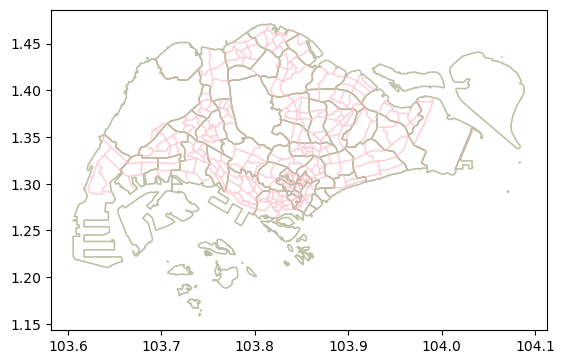

In [3]:
planningArea_shp = gpd.read_file(Data.PLANNING_AREA_FP)
subzone_shp = gpd.read_file(Data.SUBZONE_FP)
fig, ax = plt.subplots(1,1)
for shp,c in zip([planningArea_shp,subzone_shp],["green","pink"]):
    print(shp.columns)
    shp.plot(fc="none",ec=c,ax=ax,alpha=0.5)
plt.show()

## Import edge centrality measure

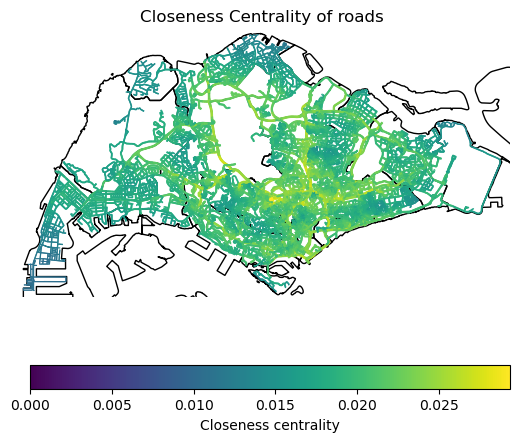

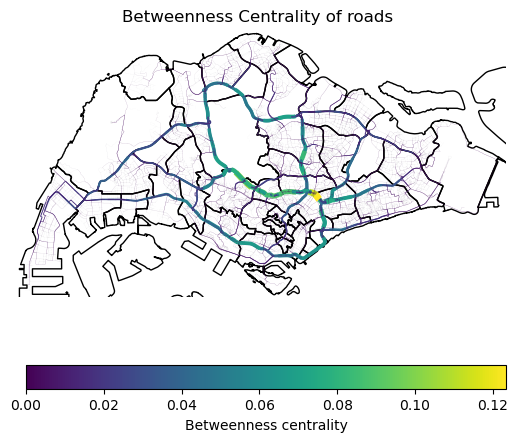

In [ ]:
G_car = ox.load_graphml(Data.G_CAR_FP)
Gcar_edge_betweeness_centrality = utils.load_pickle(r"Data\Gcar_edge_betweeness_centrality.pkl")
Gcar_edge_closeness_centrality = utils.load_pickle(r"Data\Gcar_edge_closeness_centrality.pkl")

Gcar_edge_betweeness_centrality

ax = planningArea_shp.plot(fc="None",ec="k")
ax.set_title("Closeness Centrality of roads")
plot_utils.plot_edge(G_car,Gcar_edge_closeness_centrality,ax=ax,colorbar_label="Closeness centrality",
                cmap="viridis",edge_size=2)
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"closeness_centrality_roads.png"), bbox_inches = 'tight')
plt.show()

ax = planningArea_shp.plot(fc="None",ec="k")
ax.set_title("Betweenness Centrality of roads")
plot_utils.plot_edge(G_car,Gcar_edge_betweeness_centrality,ax=ax,colorbar_label="Betweenness centrality",
                cmap="viridis",edge_size=5)
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"betweeness_centrality_roads.png"), bbox_inches = 'tight')
plt.show()

# Import drainage projects

- Drainage works generally refer to the construction, alteration, or installation of new drain systems, 
- while improvement to drains (drainage improvement works) involves upgrading existing drains by widening, deepening, or converting them (e.g., to U-shapes) to boost capacity and enhance flood resilience. 

['Road Raising' 'Drainage Work' 'Improvement to Drains'
 'Improvement to River/Canal/Culvert' 'Improvement to Outlet Drain'
 'Construction of Detention Tanks/Canal']


C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\2803830721.py:27: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  road_drainage_works.plot(ax=ax,column='work_categories',alpha=0.6, color= road_drainage_works['colors'])


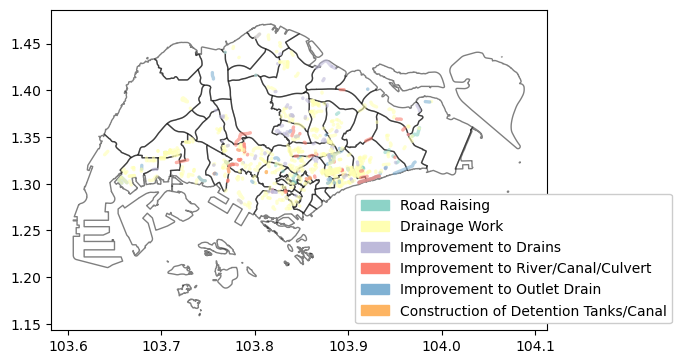

Length of df: 637
Length of df: 637


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\2803830721.py:42: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  drainage_works_omitted.plot(ax=ax,column='work_categories',alpha=0.6, color= drainage_works_omitted['colors'])


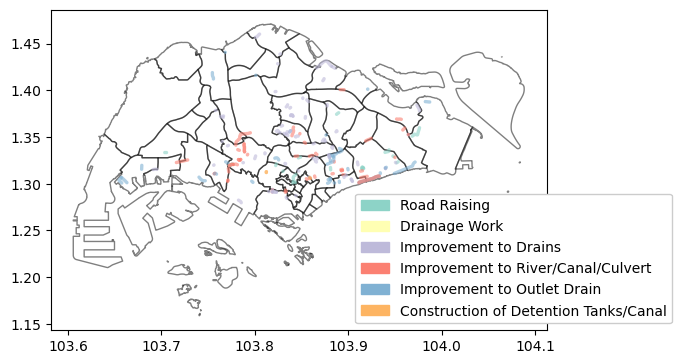

In [465]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

drainage_buffer=200
work_categories = ['Road Raising', 'Drainage Work', 'Improvement to Drains',
       'Improvement to River/Canal/Culvert',
       'Improvement to Outlet Drain', 'Construction of Detention Tanks/Canal']

discrete_cmap = [mcolors.to_hex(c) for c in plt.get_cmap('Set3').colors]
drainage_cmap = {d:c for d,c in zip(work_categories, discrete_cmap)}
# Manual Legend
patches = [mpatches.Patch(color=color, label=label) for label, color in drainage_cmap.items()]
legend_kwds = {'loc': 'lower left','bbox_to_anchor': (0.6, 0.0),
                                      'framealpha':1.0}

drainage_works_df = Data.get_drain_improvement_buffer_df(G_car, Data.DRAINAGE_WORKS_FP, 
                                                         buffer_dist= drainage_buffer, work_categories=None)
drainage_works_df = drainage_works_df[drainage_works_df['work_categories'].isin(work_categories)]
print(drainage_works_df['work_categories'].unique())
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist= drainage_buffer)
road_drainage_works = pd.concat([road_raising_works_buffer_df,drainage_works_df]).drop_duplicates()
road_drainage_works['Drainage_ID'] = list(range(len(road_drainage_works)))
ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.5)
road_drainage_works['colors'] = road_drainage_works['work_categories'].apply(lambda x: drainage_cmap[x])

road_drainage_works.plot(ax=ax,column='work_categories',alpha=0.6, color= road_drainage_works['colors'])
ax.legend(handles=patches,**legend_kwds)
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"full_adaptation_categories.png"), bbox_inches = 'tight')
plt.show()

print(f"Length of df: {len(road_drainage_works)}")
# remove drainage work categories
# flood_drainage_works = road_drainage_works[~road_drainage_works['work_categories'].isin(['Drainage Work'])]
flood_drainage_works = road_drainage_works
print(f"Length of df: {len(flood_drainage_works)}")

ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.5)
drainage_works_omitted = road_drainage_works[~road_drainage_works['work_categories'].isin(['Drainage Work'])]
drainage_works_omitted['colors'] = drainage_works_omitted['work_categories'].apply(lambda x: drainage_cmap[x])
drainage_works_omitted.plot(ax=ax,column='work_categories',alpha=0.6, color= drainage_works_omitted['colors'])
ax.legend(handles=patches,**legend_kwds)
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"adaptation_categories_drainageWorks_omitted.png"), bbox_inches = 'tight')
plt.show()

# Import flooding hotspot and prone area

length of edges:  314
length of edges:  314
length of edges:  847
length of edges:  847
Index(['Flood_Hotspot_Date', 'flooded_locations', 'responses_found',
       'matched_location', 'LATITUDE', 'LONGITUDE', 'geometry', 'year',
       'month'],
      dtype='object')
Index(['Flood_Prone_Date', 'flooded_locations', 'responses_found',
       'matched_location', 'LATITUDE', 'LONGITUDE', 'geometry', 'year',
       'month'],
      dtype='object')


<Axes: >

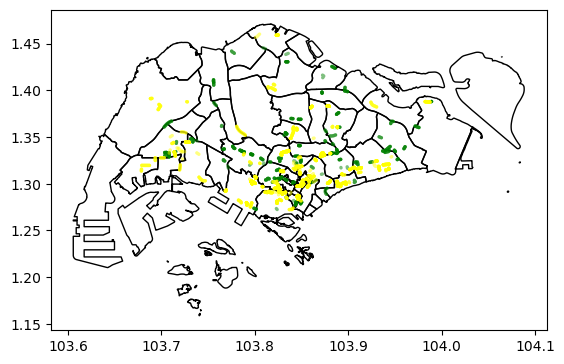

In [463]:
buffer = 200
flooding_hotspot_buffer = Data.get_flooding_hotspot_buffer(G_car, Data.FLOODING_HOTSPOT_FP, radius=buffer)
flood_prone_buffer = Data.get_flooding_hotspot_buffer(G_car, Data.FLOOD_PRONE_FP, radius=buffer)
print(flooding_hotspot_buffer.columns)
flood_prone_buffer = flood_prone_buffer.rename(columns={'Flood_Hotspot_Date':'Flood_Prone_Date'})
print(flood_prone_buffer.columns)
ax = planningArea_shp.plot(fc="None",ec="k")
flooding_hotspot_buffer.plot(ax=ax, alpha=0.5, color="green",legend=True)
flood_prone_buffer.plot(ax=ax, alpha=0.5, color="yellow",legend=True)

# Import residential property prices and landuse

In [460]:
def format_date(date):
    d,m,y = date.split("/")
    return f"{y}-{m.zfill(2)}-{d.zfill(2)}"

def count_property_type(series):
    unique, counts = np.unique(series, return_counts=True)
    return {k:v for k,v in zip(unique, counts)}

buffer=200 # only for flooding
G_car = ox.load_graphml(Data.G_CAR_FP)
residential_df = Data.get_private_residential_df(Data.PRIVATE_RESIDENTIAL_FP)
# spatial join with subzone
residential_df = residential_df.sjoin(subzone_shp[["SUBZONE_N","geometry"]],how="left")
# import HDB
HDB_residential_df = Data.get_hdb_residential_df(Data.HDB_RESALE_RESIDENTIAL_FP)

if (len(HDB_residential_df.index.unique()) == len(HDB_residential_df.index)):
    HDB_residential_df = HDB_residential_df.reset_index(names="Property_ID")
# import commercial rental
commercial_rental_df = Data.get_commercial_rental(Data.COMMERCIAL_RENTAL_FP)
commercial_rental_df = commercial_rental_df[commercial_rental_df['Year']>2013]
commercial_rental_df = commercial_rental_df.reset_index(names='Rental_ID')
# import episodic flood
flooding_df = Data.get_flood_buffer(G_car, Data.FLOOD_FP, radius=buffer)
# import tide
tide_3m_polygon = Data.get_coastal_flood_prone(Data.TIDE_3M_FP)

# landuse
landuse = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Landuse\MP2019_LU_DESC.shp")

lu = landuse['LU_DESC']

landuse['aggregated_LU'] = np.select(
    [
        lu.str.startswith("COMMERCIAL"),
        lu.str.startswith("BUSINESS"),
        lu.str.startswith("RESIDENTIAL"),
        lu.str.contains("TRANS|ROAD", regex=True),
        lu.str.contains("INSTITUTION", regex=True),
        lu.str.contains("HEALTH & MEDICAL CARE|PORT / AIRPORT", regex=True),
        lu.str.startswith("WATER"),
    ],
    [
        "COMMERCIAL",
        "BUSINESS",
        "RESIDENTIAL",
        "TRANSPORT",
        "INSTITUTION",
        "CRITICAL INFRA",
        "WATERBODY",
    ],
    default="OTHERS"
)

landuse.head()

min date: 2014-01-01 00:00:00, max date: 2025-06-22 00:00:00


c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:139: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  resale_prices_df = pd.read_csv(fp)


length of flood_df:  266
length of edges:  266


,Name,Descriptio,LU_DESC,geometry,aggregated_LU
0,kml_1,<center><table><tr><th colspan='2' align='cent...,OPEN SPACE,"POLYGON Z ((103.81658 1.33889 0, 103.81659 1.3...",OTHERS
1,kml_2,<center><table><tr><th colspan='2' align='cent...,ROAD,"POLYGON Z ((103.83533 1.34171 0, 103.83516 1.3...",TRANSPORT
2,kml_3,<center><table><tr><th colspan='2' align='cent...,PLACE OF WORSHIP,"POLYGON Z ((103.73497 1.37614 0, 103.73452 1.3...",OTHERS
3,kml_4,<center><table><tr><th colspan='2' align='cent...,ROAD,"POLYGON Z ((103.86667 1.4052 0, 103.86688 1.40...",TRANSPORT
4,kml_5,<center><table><tr><th colspan='2' align='cent...,COMMERCIAL,"POLYGON Z ((103.86855 1.40995 0, 103.86858 1.4...",COMMERCIAL


In [8]:
print(HDB_residential_df.columns)
print(residential_df.columns)
print(commercial_rental_df.columns)
print(flooding_df.columns)
print(flooding_hotspot_buffer.columns)
print(road_drainage_works.columns)

Index(['Property_ID', 'month_year', 'town', 'Property Type', 'block',
       'Project Name', 'Floor_level', 'Area (SQM)', 'flat_model',
       'lease_commence_date', 'Transacted Price ($)', 'remaining_lease',
       'SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL',
       'X', 'Y', 'LATITUDE', 'LONGITUDE', 'year', 'month', 'Building Name',
       'Building Age', 'Address', 'Sale_Date', 'is_ground_floor',
       'Unit Price ($ PSM)', 'geometry'],
      dtype='object')
Index(['Property_ID', 'Building Name', 'Transacted Price ($)', 'Area (SQFT)',
       'Unit Price ($ PSF)', 'Sale_Date', 'Address', 'Type of Sale',
       'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units', 'Tenure', 'Completion Date',
       'Purchaser Address Indicator', 'Postal Code', 'Postal District',
       'Postal Sector', 'REGION_N', 'PLN_AREA_N', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'Project Name', 'ADDRESS', 'POSTAL', 'X', 'Y', 'L

### Merge land use with land use buffer

- for each buffer around a road segment, calculate proportion of landuse

In [ ]:
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)','geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry','u','v','key']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']

buffer = 500 # set bigger buffer for adaptation
roads_gdf = ox.graph_to_gdfs(G_car, nodes=False, edges=True).reset_index()
roads_gdf['geometry'] = serviceArea.add_buffer(roads_gdf,buffer_dist=buffer, crs="EPSG:4326",plot=False)

roads_gdf_buffer = roads_gdf[['geometry','u','v','key']]
roads_gdf_buffer = roads_gdf_buffer.reset_index(names="Road_ID")
print(len(roads_gdf_buffer))

# merge with LU
landuse_cea = landuse.to_crs({'proj':'cea'})
roads_gdf_buffer_cea = roads_gdf_buffer.to_crs({'proj':'cea'})
landuse_roads_gdf_buffer = gpd.overlay(roads_gdf_buffer_cea, landuse_cea, how='intersection')
landuse_roads_gdf_buffer['area'] = landuse_roads_gdf_buffer.geometry.area / 1e6  # km²
landuse_roads_gdf_buffer = landuse_roads_gdf_buffer.groupby(['Road_ID','aggregated_LU'])['area'].sum().unstack(fill_value=0)
roads_gdf_buffer = roads_gdf_buffer.merge(landuse_roads_gdf_buffer, on = "Road_ID", how='left').fillna(0).to_crs(crs="EPSG:4326")

roads_gdf_buffer

save_dir = r"Data\adaptationAnalysis"
save_fp = f"road_landuse_buffer{buffer}_{datetime.today().strftime('%Y%m%d')}.geojson"
save_fp = os.path.join(save_dir, save_fp)
if not os.path.exists(save_fp):
    roads_gdf_buffer.to_file(save_fp, driver='GeoJSON')

45756


## Import road land use buffer

### Merge roads with subzones

In [493]:
roads_gdf_buffer = os.path.join(r"Data\adaptationAnalysis",f"road_landuse_buffer{drainage_buffer}.geojson")
print(roads_gdf_buffer)
roads_gdf_buffer = gpd.read_file(roads_gdf_buffer)
print(f"Number of unique Road_ID: {roads_gdf_buffer['Road_ID'].nunique()}")
# merge roads with subsone. Note that one road can cross multiple subsones.
roads_subzone = roads_gdf_buffer.sjoin(subzone_shp[['SUBZONE_N','geometry']],how="left")
print(f"Number of unique Road_ID: {roads_subzone['Road_ID'].nunique()}")
print(f"Length of df: {len(roads_subzone)}")
roads_subzone.head()

Data\adaptationAnalysis\road_landuse_buffer200.geojson
Number of unique Road_ID: 45756
Number of unique Road_ID: 45756
Length of df: 95164


,Road_ID,u,v,key,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,RESIDENTIAL,TRANSPORT,WATERBODY,geometry,index_right,SUBZONE_N
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",12,MARINA EAST
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",76,MARINA CENTRE
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",11,NICOLL
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",70,TANJONG RHU
1,1,25455287,1637003462,0,0.0,0.0,0.0,0.0,0.135346,0.074594,0.166587,0.000565,"POLYGON ((103.87346 1.29717, 103.8736 1.29722,...",12,MARINA EAST


### Merge with workplace cluster

Number of unique Road_ID: 45756


,Road_ID,u,v,key,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,RESIDENTIAL,TRANSPORT,WATERBODY,geometry,index_right,SUBZONE_N,distance_to_CBD
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",12,MARINA EAST,2.094013
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",76,MARINA CENTRE,2.094013
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",11,NICOLL,2.094013
0,0,25451929,6749812859,0,0.0,0.0,0.0,0.0,0.174619,0.101227,0.085856,0.070109,"POLYGON ((103.87123 1.29336, 103.87104 1.29332...",70,TANJONG RHU,2.094013
1,1,25455287,1637003462,0,0.0,0.0,0.0,0.0,0.135346,0.074594,0.166587,0.000565,"POLYGON ((103.87346 1.29717, 103.8736 1.29722,...",12,MARINA EAST,2.918437


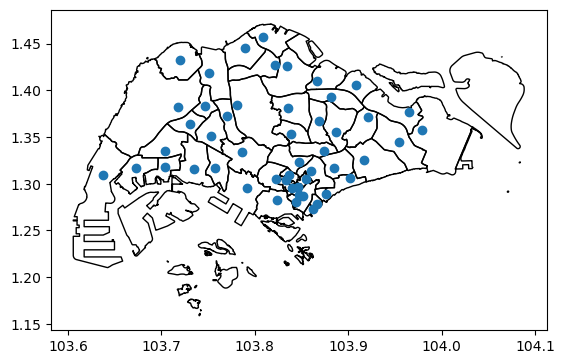

In [494]:
workplace_cluster = gpd.read_file(r"Data\workplace_cluster_planningArea.shp")
ax = planningArea_shp.plot(fc="None",ec="k")
workplace_cluster.plot(ax=ax)
# coordinate places it near raffles place
raffles_place = workplace_cluster[workplace_cluster['PLN_AREA_N'].apply(lambda x: bool(re.search(r".*DOWNTOWN.*",x)))]
# get centroid of subzone
roads_subzone_centroid = gpd.GeoDataFrame(geometry=roads_subzone.to_crs('+proj=cea')['geometry'].centroid)
# add distance to CBD in km
roads_subzone["distance_to_CBD"] = roads_subzone_centroid.distance(raffles_place.to_crs('+proj=cea')['geometry'].values[0])/1000
print(f"Number of unique Road_ID: {roads_subzone['Road_ID'].nunique()}")
roads_subzone.head()

# Split into treated and untreated roads

## Create treatment and control group (version 1)
- treatment group: subsones and Road_ID where there are adaptation works. Only identifies exact roads
- control group: same subsones as treatment group (i.e. exclude subsones outside of treatment) and exclude Road_ID that have adaptation works

In [168]:
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)','geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry','u','v','key']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']

# split to roads with adaptation (treated), and roads without adaptation (untreated)
roads_treated = roads_subzone.drop(columns=["geometry"]).merge(flood_drainage_works[drainage_columns], on=['u','v','key'], how="right").drop(columns=['index_right'])
roads_treated = gpd.GeoDataFrame(roads_treated, geometry=roads_treated['geometry'])
print(f"subzones for roads:{roads_subzone['SUBZONE_N'].nunique()}; subzones for drainage:{roads_treated['SUBZONE_N'].nunique()}")
# roads untreated - limit to only subsones identified in roads_treated
roads_untreated = roads_subzone.overlay(flood_drainage_works, how='difference')
roads_untreated[['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories']] = np.nan
# ensure control group have the same subsone as treated, but do not contain the same road id
roads_untreated = roads_untreated[roads_untreated['SUBZONE_N'].isin(list(roads_treated['SUBZONE_N'].unique()))].drop(columns=['index_right'])
roads_untreated = roads_untreated[~roads_untreated['Road_ID'].isin(list(roads_treated['Road_ID'].unique()))]

print(f"subzones for roads:{roads_subzone['SUBZONE_N'].nunique()}; subzones for control:{roads_untreated['SUBZONE_N'].nunique()}")
print(roads_treated.columns)
print(roads_untreated.columns)
print(f"Length of treated: {len(roads_treated)}, Length of control: {len(roads_untreated)}")

subzones for roads:326; subzones for drainage:291
subzones for roads:326; subzones for control:291
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'geometry'],
      dtype='object')
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'geometry', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories'],
      dtype='object')
Length of treated: 2525, Length of control: 125385


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 923 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


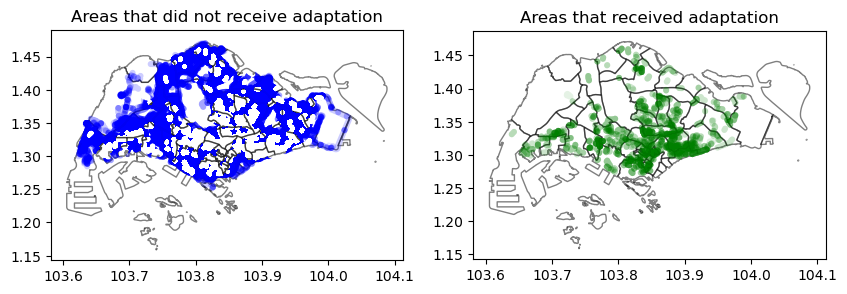

In [170]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
for ax in axes.flatten():
    planningArea_shp.plot(ax=ax, fc="None",ec="k",alpha=0.5)
roads_untreated.plot(ax=axes[0],color="blue",alpha=0.1)
roads_treated.plot(ax=axes[1],color="green",alpha=0.1)
axes[0].set_title("Areas that did not receive adaptation")
axes[1].set_title("Areas that received adaptation")
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"full_adaptation.png"), bbox_inches = 'tight')
plt.show()

## Create treatment and control group (version 2)
- treatment group: subsones and Road_ID where there are adaptation works. Only identifies exact roads
- control group: exclude Road_ID that have adaptation works, also implies that it will contain subsones that are not in treatment group i.e. treatment group is the rest of Singapore
- this does not take into account of the surrounding areas which may have adaptation because drainage work only allows us to retrieve a rough point coordinate but the adaptation may actually affect the entire area

In [ ]:
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)','geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry','u','v','key']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']

# split to roads with adaptation (treated), and roads without adaptation (untreated)
roads_treated = roads_subzone.drop(columns=["geometry"]).merge(flood_drainage_works[drainage_columns], on=['u','v','key'], how="right").drop(columns=['index_right'])
roads_treated = gpd.GeoDataFrame(roads_treated, geometry=roads_treated['geometry'])
print(f"subzones for roads:{roads_subzone['SUBZONE_N'].nunique()}; subzones for drainage:{roads_treated['SUBZONE_N'].nunique()}")
print(f"Number of unique Road_ID in roads_treated: {roads_treated['Road_ID'].nunique()}")
print(f"Number of unique Road ID in flood_drainage_works: {len(flood_drainage_works[['u','v','key']].drop_duplicates())}")

# roads untreated - limit to only subsones identified in roads_treated
roads_untreated = roads_subzone.overlay(flood_drainage_works, how='difference')
roads_untreated[['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories']] = np.nan
# ensure control group have the same subsone as treated, but do not contain the same road id
roads_untreated = roads_untreated[~roads_untreated['Road_ID'].isin(list(roads_treated['Road_ID'].unique()))]
print(f"Number of unique Road_ID in roads_untreated: {roads_untreated['Road_ID'].nunique()}")
print(f"subzones for roads:{roads_subzone['SUBZONE_N'].nunique()}; subzones for control:{roads_untreated['SUBZONE_N'].nunique()}")
print(roads_treated.columns)
print(roads_untreated.columns)
print(f"Length of treated: {len(roads_treated)}, Length of control: {len(roads_untreated)}")

subzones for roads:326; subzones for drainage:291
Number of unique Road_ID in roads_treated: 544
Number of unique Road ID in flood_drainage_works: 544
Number of unique Road_ID in roads_untreated: 38101
subzones for roads:326; subzones for control:326
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'geometry'],
      dtype='object')
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'geometry', 'index_right', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME',
       'Drainage_ID', 'Drainage_Date', 'work_types', 'work_categories'],
      dtype='object')
Length of treated: 2525, Length of control: 137177


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 923 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


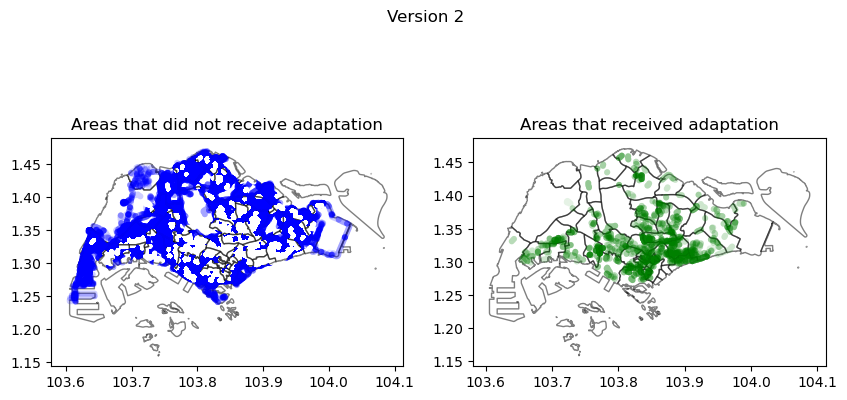

In [335]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
for ax in axes.flatten():
    planningArea_shp.plot(ax=ax, fc="None",ec="k",alpha=0.5)
roads_untreated.plot(ax=axes[0],color="blue",alpha=0.1)
roads_treated.plot(ax=axes[1],color="green",alpha=0.1)
axes[0].set_title("Areas that did not receive adaptation")
axes[1].set_title("Areas that received adaptation")
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"full_adaptation.png"), bbox_inches = 'tight')
fig.suptitle("Version 2")
plt.show()

## Create treatment and control group (version 3)
- treatment group: subsones and Road_ID where there are adaptation works. Include 200m/500m drainage buffer of surrounding areas of the road receiving adaptation
- control group: exclude Road_ID that have adaptation works and are within the buffer radius, also implies that it will contain subsones that are not in treatment group i.e. treatment group is the rest of Singapore

In [495]:
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)','geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']
print(f"Number of Roads_ID within roads_subzone: {len(roads_subzone['Road_ID'].unique())}")

# roads_treated
# check which Road_IDs are within the flood_drainage_works
roads_gdf = ox.graph_to_gdfs(G_car, nodes=False, edges=True).reset_index()
roads_gdf = roads_gdf[['geometry','u','v','key']].reset_index(names="Road_ID")
# all the Road_IDs that are within flood_drainage works will be selected
roads_treated = flood_drainage_works[drainage_columns].sjoin(roads_gdf[['Road_ID','geometry','u','v','key']],
                                                             how='left', predicate='contains').drop(columns=['index_right'])
print(f"Length of treated: {len(roads_treated)}")
print(f"Number of Roads_ID within {drainage_buffer}m buffer of roads_treated: {roads_treated['Road_ID'].nunique()}")
# merge roads_subzone so that landuse attributes will be added to roads_treated
roads_treated = roads_subzone.drop(columns=["geometry"]).merge(roads_treated, 
                                                               on=['Road_ID','u','v','key'], how="right").drop(columns=['index_right'])
print(f"Number of Roads_ID within {drainage_buffer}m buffer of roads_treated: {roads_treated['Road_ID'].nunique()}")
print(f"Length of treated: {len(roads_treated)}")

# convert to gdf
roads_treated = gpd.GeoDataFrame(data=roads_treated, geometry=roads_treated['geometry'])
print(f"Number of Roads_ID within roads_treated: {roads_treated['Road_ID'].nunique()}")
print(f"Length of treated: {len(roads_treated)}")
print(roads_treated.columns)

# roads_untreated
roads_untreated = roads_subzone[~roads_subzone['Road_ID'].isin(list(roads_treated['Road_ID'].unique()))].drop(columns=['index_right'])
roads_untreated[['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories']] = np.nan
print(f"Number of Roads_ID within roads_untreated: {len(roads_untreated['Road_ID'].unique())}")
print(f"Length of treated: {len(roads_treated)}, Length of control: {len(roads_untreated)}")
print(f"Unique Road_ID for road_treated: {roads_treated['Road_ID'].nunique()},\
      Unique Road_ID for road_treated: {roads_untreated['Road_ID'].nunique()}, \
      Sum: {roads_treated['Road_ID'].nunique()+roads_untreated['Road_ID'].nunique()}")
print(f"Is number of Road_ID in roads treated and untreated same as in roads_subzone: \
      {(len(roads_untreated['Road_ID'].unique()) + len(roads_treated['Road_ID'].unique())) == len(roads_subzone['Road_ID'].unique())}")

Number of Roads_ID within roads_subzone: 45756
Length of treated: 20881
Number of Roads_ID within 200m buffer of roads_treated: 11640
Number of Roads_ID within 200m buffer of roads_treated: 11640
Length of treated: 42130
Number of Roads_ID within roads_treated: 11640
Length of treated: 42130
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'geometry'],
      dtype='object')
Number of Roads_ID within roads_untreated: 34116
Length of treated: 42130, Length of control: 70897
Unique Road_ID for road_treated: 11640,      Unique Road_ID for road_treated: 34116,       Sum: 45756
Is number of Road_ID in roads treated and untreated same as in roads_subzone:       True


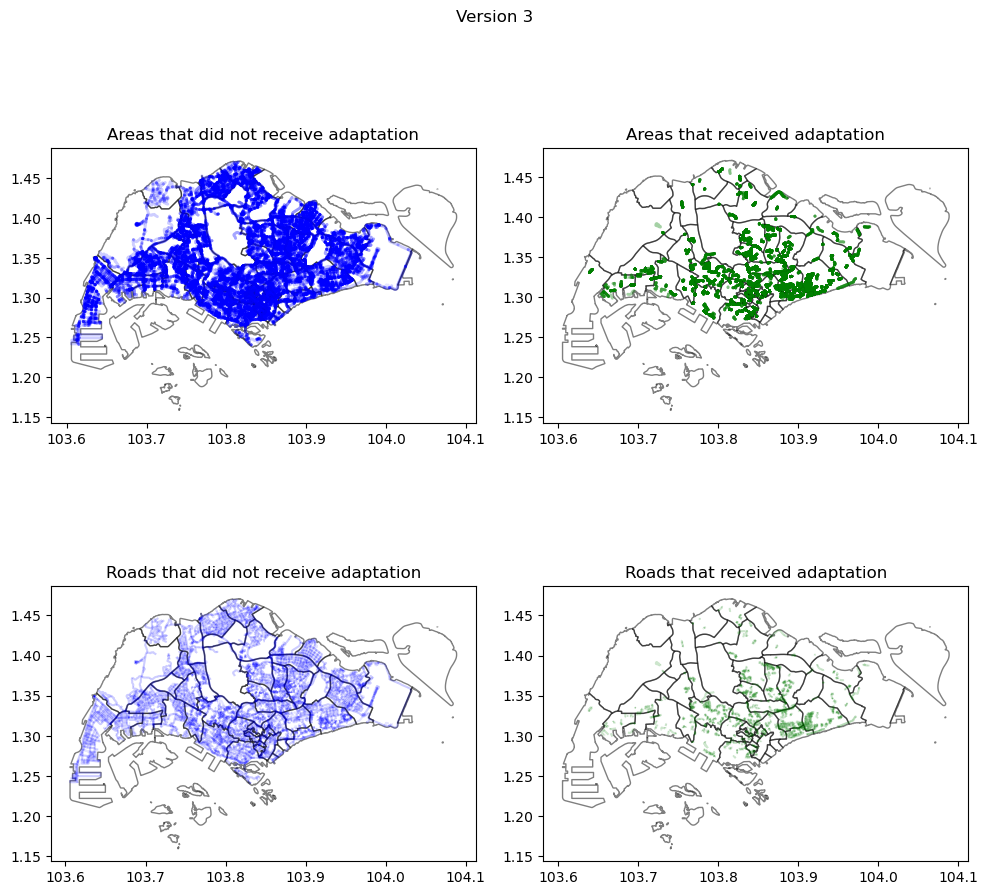

In [474]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
for ax in axes.flatten():
    planningArea_shp.plot(ax=ax, fc="None",ec="k",alpha=0.5)
roads_untreated.plot(ax=axes[0,0],color="blue",alpha=0.1)
roads_treated.plot(ax=axes[0,1],color="green",alpha=0.1)
roads_gdf[roads_gdf['Road_ID'].isin(roads_untreated['Road_ID'].unique())].plot(ax=axes[1,0],color="blue",alpha=0.1)
roads_gdf[roads_gdf['Road_ID'].isin(roads_treated['Road_ID'].unique())].plot(ax=axes[1,1],color="green",alpha=0.1)

axes[0,0].set_title("Areas that did not receive adaptation")
axes[0,1].set_title("Areas that received adaptation")
axes[1,0].set_title("Roads that did not receive adaptation")
axes[1,1].set_title("Roads that received adaptation")
plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
                         f"full_adaptation_{datetime.today().strftime('%Y%m%d')}.png"), bbox_inches = 'tight')
fig.suptitle("Version 3")
plt.tight_layout()
plt.show()

Merge land use with properties

In [174]:
groupby=['Road_ID']
landuse_df = roads_treated#.drop_duplicates(subset=[groupby[0],'SUBZONE_N'])
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)','geometry']
commercial_rental_columns = ["Rental_ID",'Median Rental ($ PSM)','LATITUDE', 'LONGITUDE', 'Rental_Date', 'geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry','u','v','key']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']

property = landuse_df.sjoin(residential_df[private_residential_columns],how="left",
                                                    lsuffix="drainage", rsuffix="property"
                                                    ).drop(columns=['index_property'])
property = property.groupby(groupby).agg({'Unit Price ($ PSM)':'mean',
                                            'Number of Units':'sum',
                                            'LATITUDE':'mean',
                                            'LONGITUDE':'mean'}).reset_index().rename(columns={'Number of Units':'private_units_est'})
df = landuse_df.merge(property)
print(f"Length of df: {len(df)}")
# merge HDB properties
hdb_property = df.sjoin(HDB_residential_df[HDB_residential_columns],how="left",
                                                    lsuffix="private", rsuffix="HDB").drop(columns=['index_HDB'])
print(hdb_property.columns)
# estimate HDB units from address
hdb_property = hdb_property.groupby(groupby).agg({'Unit Price ($ PSM)_HDB':'mean',
                                                  'Address':lambda x: x.nunique()}).reset_index().rename(columns={'Address':'HDB_units_est'})
df = df.merge(hdb_property)
# commercial = df.sjoin(commercial_rental_df[commercial_rental_columns],how="left",
#                                                     lsuffix="drainage", rsuffix="rental").drop(columns=['index_rental'])
# commercial = commercial.groupby(groupby).agg({'Median Rental ($ PSM)':'mean'}).reset_index()
# df = df.merge(commercial)
print(f"Length of df: {len(df)}")
print(df.columns)
df.head()

Length of df: 2525
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME_private', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'geometry',
       'Unit Price ($ PSM)_private', 'private_units_est', 'LATITUDE',
       'LONGITUDE', 'Property_ID', 'ROAD_NAME_HDB', 'Address', 'Property Type',
       'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)_HDB'],
      dtype='object')
Length of df: 2525
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'geometry',
       'Unit Price ($ PSM)', 'private_units_est', 'LATITUDE', 'LONGITUDE',
       'Unit Price ($ PSM)_HDB', 'HDB_u

,Road_ID,u,v,key,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,RESIDENTIAL,...,Drainage_Date,work_types,work_categories,geometry,Unit Price ($ PSM),private_units_est,LATITUDE,LONGITUDE,Unit Price ($ PSM)_HDB,HDB_units_est
0,19670,408735646,2641677416,0,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,...,2012-03-01,Road Raising and Drainage Works,Road Raising,"POLYGON ((103.84474 1.33171, 103.84481 1.33178...",16227.185402,7680.0,1.326809,103.847439,5478.693591,69
1,19670,408735646,2641677416,0,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,...,2012-03-01,Road Raising and Drainage Works,Road Raising,"POLYGON ((103.84474 1.33171, 103.84481 1.33178...",16227.185402,7680.0,1.326809,103.847439,5478.693591,69
2,19670,408735646,2641677416,0,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,...,2012-03-01,Road Raising and Drainage Works,Road Raising,"POLYGON ((103.84474 1.33171, 103.84481 1.33178...",16227.185402,7680.0,1.326809,103.847439,5478.693591,69
3,19670,408735646,2641677416,0,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,...,2012-03-01,Road Raising and Drainage Works,Road Raising,"POLYGON ((103.84474 1.33171, 103.84481 1.33178...",16227.185402,7680.0,1.326809,103.847439,5478.693591,69
4,6908,2168300378,6754998201,0,0.000000,0.000000,0.000000,0.047051,0.195680,0.472585,...,2012-03-01,Road Raising and Drainage Works,Road Raising,"POLYGON ((103.8335 1.31017, 103.8334 1.31008, ...",26303.844228,6594.0,1.314499,103.830552,NaN,0


Merge with other metrics

In [175]:
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
       'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)','geometry']
commercial_rental_columns = ["Rental_ID",'Median Rental ($ PSM)','LATITUDE', 'LONGITUDE', 'Rental_Date', 'geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry','u','v','key']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']

groupby=['Road_ID']
landuse_df = roads_treated
property = landuse_df.sjoin(residential_df[private_residential_columns],how="left",
                                                    lsuffix="drainage", rsuffix="property"
                                                    ).drop(columns=['index_property'])
property = property.groupby(groupby).agg({'Unit Price ($ PSM)':'mean',
                                            'Number of Units':'sum',
                                            'LATITUDE':'mean',
                                            'LONGITUDE':'mean'}).reset_index().rename(columns={'Number of Units':'private_units_est'})
df = landuse_df.merge(property)
print(f"Length of df: {len(df)}")

# merge with tide prone
df["prone_to_high_tide"] = df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))

# merge with centrality metrics
df['betweeness_centrality'] = df.apply(lambda x: Gcar_edge_betweeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
df['closeness_centrality'] = df.apply(lambda x: Gcar_edge_closeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
df = df.dropna(subset=["LATITUDE","LONGITUDE"]).drop(columns=['u','v','key'])

# Merge with DEM
df["DEM"] = df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)

# merge HDB properties
hdb_property = df.sjoin(HDB_residential_df[HDB_residential_columns],how="left",
                                                    lsuffix="private", rsuffix="HDB").drop(columns=['index_HDB'])
print(hdb_property.columns)
# estimate HDB units from address
hdb_property = hdb_property.groupby(groupby).agg({'Unit Price ($ PSM)_HDB':'mean',
                                                  'Address':lambda x: x.nunique()}).reset_index().rename(columns={'Address':'HDB_units_est'})
df = df.merge(hdb_property)

# merge with commercial office price data
commercial = df.sjoin(commercial_rental_df[commercial_rental_columns],how="left",
                                                    lsuffix="drainage", rsuffix="rental").drop(columns=['index_rental'])
commercial = commercial.groupby(groupby).agg({'Median Rental ($ PSM)':'mean'}).reset_index()
df = df.merge(commercial)
print(f"Length of df: {len(df)}")
print(df.columns)

# merge with flood data
flood_freq = df.sjoin(flooding_df[flood_columns],how="left",
            lsuffix="property",rsuffix='flood').drop(columns=['index_flood'])
# print(f"Length of df: {len(x)}")
flood_freq = flood_freq.groupby(groupby).agg({'Flood_ID':lambda x: x.nunique()}).reset_index().rename(columns={'Flood_ID':'flood_frequency'})
df = df.merge(flood_freq)

# merge with flooding hotspot data
flooding_hotspot = df.sjoin(flooding_hotspot_buffer[flood_hotspot_columns],how="left").drop(columns=['index_right'])
# print(f"Length of df: {len(x)}")
flooding_hotspot = flooding_hotspot.groupby(groupby).agg({'Flood_Hotspot_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Hotspot_Date':'flood_hotspot'})
df = df.merge(flooding_hotspot)

# merge with flood prone data
flood_prone = df.sjoin(flood_prone_buffer[flood_prone_columns],how="left").drop(columns=['index_right'])
print(f"Length of df: {len(flood_prone)}")
flood_prone = flood_prone.groupby(groupby).agg({'Flood_Prone_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Prone_Date':'flood_prone'})
df = df.merge(flood_prone)
print(df.columns)
print(f"Length of df: {len(df)}")

Length of df: 2525
Index(['Road_ID', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION',
       'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'SUBZONE_N',
       'distance_to_CBD', 'ROAD_NAME_private', 'Drainage_ID', 'Drainage_Date',
       'work_types', 'work_categories', 'geometry',
       'Unit Price ($ PSM)_private', 'private_units_est', 'LATITUDE',
       'LONGITUDE', 'prone_to_high_tide', 'betweeness_centrality',
       'closeness_centrality', 'DEM', 'Property_ID', 'ROAD_NAME_HDB',
       'Address', 'Property Type', 'Area (SQM)', 'flat_model',
       'lease_commence_date', 'Unit Price ($ PSM)_HDB'],
      dtype='object')
Length of df: 2251
Index(['Road_ID', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION',
       'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'SUBZONE_N',
       'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID', 'Drainage_Date',
       'work_types', 'work_categories', 'geometry', 'Unit Price ($ PSM)',
       'private_units_est', 'LATITUDE', '

## Adaptation analysis on SUBZONE

In [158]:
# # split to roads with adaptation (treated), and roads without adaptation (untreated)
# roads_treated = roads_gdf_buffer.drop(columns=["geometry"]).merge(road_drainage_works[drainage_columns], on=['u','v','key'], how="right")
# roads_treated = gpd.GeoDataFrame(roads_treated, geometry=roads_treated['geometry'])
# print(f"Length of road treated df: {len(roads_treated)}")
# roads_treated = roads_treated.sjoin(subzone_shp[['geometry','SUBZONE_N']],how='left').drop(columns=['index_right'])
# print(f"Length of road treated df: {len(roads_treated)}")
# roads_untreated = roads_gdf_buffer.overlay(road_drainage_works, how='difference')
# roads_untreated[['ROAD_NAME',
#  'Drainage_ID',
#  'Drainage_Date',
#  'work_types',
#  'work_categories']] = None
# roads_untreated = roads_untreated.sjoin(subzone_shp[['geometry','SUBZONE_N']],how='left').drop(columns=['index_right'])
# roads_treated.head()

#----params-------------

groupby=['SUBZONE_N']
landuse_df = roads_untreated
#----params-------------

df_list = []
for landuse_df in [roads_treated, roads_untreated]:
    # # one road can have multiple subsones leading to duplicated rows, best to drop the subsone column for roads
    # property = landuse_df.drop(columns=groupby).sjoin(residential_df[private_residential_columns],how="left",
    #                                                 lsuffix="drainage", rsuffix="property"
    #                                                 ).drop(columns=['index_property'])
    # property = property.groupby(groupby).agg({'Unit Price ($ PSM)':'mean',
    #                                           'Number of Units':'sum',
    #                                             'LATITUDE':'mean',
    #                                             'LONGITUDE':'mean'}).reset_index()
    # print(f"Length of property: {len(property)}")
    # df = landuse_df.merge(property)
    # print(f"Length of df: {len(df)}")
    # # merge with tide prone
    # df["prone_to_high_tide"] = df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
    # # merge with centrality metrics
    # df['betweeness_centrality'] = df.apply(lambda x: Gcar_edge_betweeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
    # df['closeness_centrality'] = df.apply(lambda x: Gcar_edge_closeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
    # df = df.dropna(subset=["LATITUDE","LONGITUDE"]).drop(columns=['u','v','key'])
    # # Merge with DEM
    # df["DEM"] = df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)
    # # merge with flood data
    # flood_freq = df.sjoin(flooding_df[flood_columns],how="left",
    #             lsuffix="property",rsuffix='flood').drop(columns=['index_flood'])
    # print(f"Length of df: {len(df)}")
    # flood_freq = flood_freq.groupby(groupby).agg({'Flood_ID':lambda x: x.nunique()}).reset_index().rename(columns={'Flood_ID':'flood_frequency'})
    # print(f"Length of flood_freq: {len(flood_freq)}")
    # df = df.merge(flood_freq)
    # # merge with flooding hotspot data
    # flooding_hotspot = df.sjoin(flooding_hotspot_buffer[flood_hotspot_columns],how="left").drop(columns=['index_right'])
    # print(f"Length of df: {len(df)}")
    # flooding_hotspot = flooding_hotspot.groupby(groupby).agg({'Flood_Hotspot_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Hotspot_Date':'flood_hotspot'})
    # df = df.merge(flooding_hotspot)
    # print(df.columns)
    # print(f"Length of df: {len(df)}")
    # # merge with flood prone data
    # flood_prone = df.sjoin(flood_prone_buffer[flood_prone_columns],how="left").drop(columns=['index_right'])
    # print(f"Length of df: {len(flood_prone)}")
    # flood_prone = flood_prone.groupby(groupby).agg({'Flood_Prone_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Prone_Date':'flood_prone'})
    # df = df.merge(flood_prone)
    # print(df.columns)
    # print(df['SUBZONE_N'].nunique())
    # print(f"Length of df: {len(df)}")
    # df_list.append(df)
    property = landuse_df.drop(columns=groupby).sjoin(residential_df[private_residential_columns],how="left",
                                                        lsuffix="drainage", rsuffix="property"
                                                        ).drop(columns=['index_property'])
    property = property.groupby(groupby).agg({'Unit Price ($ PSM)':'mean',
                                                'Number of Units':'sum',
                                                'LATITUDE':'mean',
                                                'LONGITUDE':'mean'}).reset_index().rename(columns={'Number of Units':'private_units_est'})
    df = landuse_df.merge(property)
    print(f"Length of df: {len(df)}")

    # merge with tide prone
    df["prone_to_high_tide"] = df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))

    # merge with centrality metrics
    df['betweeness_centrality'] = df.apply(lambda x: Gcar_edge_betweeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
    df['closeness_centrality'] = df.apply(lambda x: Gcar_edge_closeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
    df = df.dropna(subset=["LATITUDE","LONGITUDE"]).drop(columns=['u','v','key'])

    # Merge with DEM
    df["DEM"] = df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)

    # merge HDB properties
    hdb_property = df.sjoin(HDB_residential_df[HDB_residential_columns],how="left",
                                                        lsuffix="private", rsuffix="HDB").drop(columns=['index_HDB'])
    print(hdb_property.columns)
    # estimate HDB units from address
    hdb_property = hdb_property.groupby(groupby).agg({'Unit Price ($ PSM)_HDB':'mean',
                                                    'Address':lambda x: x.nunique()}).reset_index().rename(columns={'Address':'HDB_units_est'})
    df = df.merge(hdb_property)

    # merge with commercial office price data
    commercial = df.sjoin(commercial_rental_df[commercial_rental_columns],how="left",
                                                        lsuffix="drainage", rsuffix="rental").drop(columns=['index_rental'])
    commercial = commercial.groupby(groupby).agg({'Median Rental ($ PSM)':'mean'}).reset_index()
    df = df.merge(commercial)
    print(f"Length of df: {len(df)}")
    print(df.columns)

    # merge with flood data
    flood_freq = df.sjoin(flooding_df[flood_columns],how="left",
                lsuffix="property",rsuffix='flood').drop(columns=['index_flood'])
    # print(f"Length of df: {len(x)}")
    flood_freq = flood_freq.groupby(groupby).agg({'Flood_ID':lambda x: x.nunique()}).reset_index().rename(columns={'Flood_ID':'flood_frequency'})
    df = df.merge(flood_freq)

    # merge with flooding hotspot data
    flooding_hotspot = df.sjoin(flooding_hotspot_buffer[flood_hotspot_columns],how="left").drop(columns=['index_right'])
    # print(f"Length of df: {len(x)}")
    flooding_hotspot = flooding_hotspot.groupby(groupby).agg({'Flood_Hotspot_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Hotspot_Date':'flood_hotspot'})
    df = df.merge(flooding_hotspot)

    # merge with flood prone data
    flood_prone = df.sjoin(flood_prone_buffer[flood_prone_columns],how="left").drop(columns=['index_right'])
    print(f"Length of df: {len(flood_prone)}")
    flood_prone = flood_prone.groupby(groupby).agg({'Flood_Prone_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Prone_Date':'flood_prone'})
    df = df.merge(flood_prone)
    print(df.columns)
    print(f"Length of df: {len(df)}")
    df_list.append(df)

subzone_df = pd.concat(df_list, keys=[1,0],names=['treat_adaptation'])
subzone_df = subzone_df.reset_index(level=[0])
subzone_df.drop(columns=['geometry']).to_csv(os.path.join(r"Exported_Data\adaptation",f"{groupby[0]}_buffer{buffer}_{datetime.today().strftime('%Y%m%d')}.csv"),index=False)
print(subzone_df['treat_adaptation'].sum())
subzone_df

Length of df: 415
Index(['Road_ID', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION',
       'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'SUBZONE_N',
       'ROAD_NAME_private', 'Drainage_ID', 'Drainage_Date', 'work_types',
       'work_categories', 'geometry', 'Unit Price ($ PSM)_private',
       'private_units_est', 'LATITUDE', 'LONGITUDE', 'prone_to_high_tide',
       'betweeness_centrality', 'closeness_centrality', 'DEM', 'Property_ID',
       'ROAD_NAME_HDB', 'Address', 'Property Type', 'Area (SQM)', 'flat_model',
       'lease_commence_date', 'Unit Price ($ PSM)_HDB'],
      dtype='object')
Length of df: 415
Index(['Road_ID', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION',
       'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'SUBZONE_N',
       'ROAD_NAME', 'Drainage_ID', 'Drainage_Date', 'work_types',
       'work_categories', 'geometry', 'Unit Price ($ PSM)',
       'private_units_est', 'LATITUDE', 'LONGITUDE', 'prone_to_high_tide',
       'betwe

,treat_adaptation,Road_ID,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,RESIDENTIAL,TRANSPORT,WATERBODY,...,prone_to_high_tide,betweeness_centrality,closeness_centrality,DEM,Unit Price ($ PSM)_HDB,HDB_units_est,Median Rental ($ PSM),flood_frequency,flood_hotspot,flood_prone
0,1,19670,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,0.251548,0.049520,...,False,0.000243,0.022772,6.390000,5679.013029,120,81.869967,21,True,True
1,1,19670,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,0.251548,0.049520,...,False,0.000243,0.022772,6.750000,5873.650981,535,68.666580,6,True,True
2,1,19670,0.020017,0.139919,0.014499,0.076421,0.174008,0.344989,0.251548,0.049520,...,False,0.000243,0.022772,9.250000,5855.868855,344,81.822472,5,True,True
3,1,6908,0.000000,0.000000,0.000000,0.047051,0.195680,0.472585,0.136424,0.000000,...,False,0.000122,0.020428,19.280001,NaN,0,NaN,7,True,True
4,1,6908,0.000000,0.000000,0.000000,0.047051,0.195680,0.472585,0.136424,0.000000,...,False,0.000122,0.020428,12.690000,NaN,0,NaN,13,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85322,0,45753,0.000000,0.000000,0.001433,0.016513,0.194051,0.433370,0.163508,0.000892,...,True,0.000063,0.019286,11.620000,5241.251945,1219,54.708887,10,True,True
85323,0,45754,0.000000,0.000000,0.001433,0.016057,0.197253,0.412978,0.157518,0.001148,...,True,0.000055,0.018920,20.600000,5072.106277,203,43.624165,4,True,True
85324,0,45754,0.000000,0.000000,0.001433,0.016057,0.197253,0.412978,0.157518,0.001148,...,True,0.000055,0.018920,11.620000,5241.251945,1219,54.708887,10,True,True
85325,0,45755,0.000000,0.000000,0.001433,0.015934,0.215165,0.408918,0.158620,0.001294,...,True,0.000991,0.018920,20.600000,5072.106277,203,43.624165,4,True,True


## Adaptation analysis on Road_ID

In [496]:
private_residential_columns = ["Property_ID",'Address','Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)',
    'Property Type', 'Number of Units','Completion Date','ROAD_NAME','REGION_N', 'PLN_AREA_N',"SUBZONE_N",'geometry',"LATITUDE","LONGITUDE"]
HDB_residential_columns = ["Property_ID",'ROAD_NAME','Address','Property Type','Area (SQM)', 'flat_model', 'lease_commence_date',
    'Unit Price ($ PSM)','geometry']
commercial_rental_columns = ["Rental_ID",'Median Rental ($ PSM)','LATITUDE', 'LONGITUDE', 'Rental_Date', 'geometry']
drainage_columns = ['ROAD_NAME','Drainage_ID','Drainage_Date','work_types','work_categories','geometry','u','v','key']
flood_columns = ['Flood_ID','Flood_Date','geometry']
flood_hotspot_columns = ['Flood_Hotspot_Date','geometry']
flood_prone_columns = ['Flood_Prone_Date','geometry']
landuse_columns = ['LU_DESC', 'geometry']

# use roads_gdf's Road_ID centroid coordinates
roads_gdf['LATITUDE'] = roads_gdf.geometry.centroid.y
roads_gdf['LONGITUDE'] = roads_gdf.geometry.centroid.x

#----params-------------
groupby=['Road_ID']
landuse_df = roads_untreated
buffer=drainage_buffer
#----params-------------
df_list = []
for landuse_df in [roads_treated, roads_untreated]:
    
    property = landuse_df.sjoin(residential_df[private_residential_columns],how="left",
                                                        lsuffix="drainage", rsuffix="property"
                                                        ).drop(columns=['index_property'])
    property = property.groupby(groupby).agg({'Unit Price ($ PSM)':'mean',
                                                'Number of Units':'sum',
                                                # 'LATITUDE':'mean',
                                                # 'LONGITUDE':'mean'
                                                }).reset_index().rename(columns={'Number of Units':'private_units_est'})
    df = landuse_df.merge(property)
    print(f"Number of Roads_ID - property: {df['Road_ID'].nunique()}")
    print(f"Length of df: {len(df)}")

    # merge with tide prone
    df["prone_to_high_tide"] = df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))

    # merge with centrality metrics
    df['betweeness_centrality'] = df.apply(lambda x: Gcar_edge_betweeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
    df['closeness_centrality'] = df.apply(lambda x: Gcar_edge_closeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
    print(f"Number of Roads_ID - centrality: {df['Road_ID'].nunique()}")
    
    df = df.merge(roads_gdf[['Road_ID','LATITUDE','LONGITUDE']], how='left', on='Road_ID')
    # df = df.dropna(subset=["LATITUDE","LONGITUDE"]).drop(columns=['u','v','key'])
    print(f"Number of Roads_ID - centrality: {df['Road_ID'].nunique()}")
    # Merge with DEM
    df["DEM"] = df.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)

    # merge HDB properties
    hdb_property = df.sjoin(HDB_residential_df[HDB_residential_columns],how="left",
                                                        lsuffix="private", rsuffix="HDB").drop(columns=['index_HDB'])
    
    print(hdb_property.columns)
    # estimate HDB units from address
    hdb_property = hdb_property.groupby(groupby).agg({'Unit Price ($ PSM)_HDB':'mean',
                                                    'Address':lambda x: x.nunique()}).reset_index().rename(columns={'Address':'HDB_units_est'})
    df = df.merge(hdb_property)
    print(f"Number of Roads_ID hdb_property: {df['Road_ID'].nunique()}")
    # merge with commercial office price data
    commercial = df.sjoin(commercial_rental_df[commercial_rental_columns],how="left",
                                                        lsuffix="drainage", rsuffix="rental").drop(columns=['index_rental'])
    commercial = commercial.groupby(groupby).agg({'Median Rental ($ PSM)':'mean'}).reset_index()
    df = df.merge(commercial)
    print(f"Length of df: {len(df)}")
    print(df.columns)
    print(f"Number of Roads_ID commercial: {df['Road_ID'].nunique()}")
    # merge with flood data
    flood_freq = df.sjoin(flooding_df[flood_columns],how="left",
                lsuffix="property",rsuffix='flood').drop(columns=['index_flood'])
    # print(f"Length of df: {len(x)}")
    flood_freq = flood_freq.groupby(groupby).agg({'Flood_ID':lambda x: x.nunique()}).reset_index().rename(columns={'Flood_ID':'flood_frequency'})
    df = df.merge(flood_freq)
    print(f"Number of Roads_ID - flood_freq: {df['Road_ID'].nunique()}")

    if ('index_right' in df.columns):
        df = df.drop(columns=['index_right'])
    # merge with flooding hotspot data
    flooding_hotspot = df.sjoin(flooding_hotspot_buffer[flood_hotspot_columns],how="left").drop(columns=['index_right'])
    # print(f"Length of df: {len(x)}")
    flooding_hotspot = flooding_hotspot.groupby(groupby).agg({'Flood_Hotspot_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Hotspot_Date':'flood_hotspot'})
    df = df.merge(flooding_hotspot)
    print(f"Number of Roads_ID - flooding_hotspot: {df['Road_ID'].nunique()}")

    # merge with flood prone data
    flood_prone = df.sjoin(flood_prone_buffer[flood_prone_columns],how="left").drop(columns=['index_right'])
    print(f"Length of df: {len(flood_prone)}")
    flood_prone = flood_prone.groupby(groupby).agg({'Flood_Prone_Date':lambda x: x.notna().any()}).reset_index().rename(columns={'Flood_Prone_Date':'flood_prone'})
    df = df.merge(flood_prone)
    print(f"Number of Roads_ID - flood_prone: {df['Road_ID'].nunique()}")
    print(df.columns)
    print(f"Length of df: {len(df)}")
    df_list.append(df)


roads_id_df = pd.concat(df_list, keys=[1,0],names=['treat_adaptation'])
print(f"Number of Roads_ID within roads_id_df: {roads_id_df['Road_ID'].nunique()}")
roads_id_df = roads_id_df.reset_index(level=[0])
roads_id_df.drop(columns=['geometry']).to_csv(os.path.join(r"Exported_Data\adaptation",f"{groupby[0]}_buffer{buffer}_{datetime.today().strftime('%Y%m%d')}.csv"),index=False)
roads_id_df

C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\65238102.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  roads_gdf['LATITUDE'] = roads_gdf.geometry.centroid.y
C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\65238102.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  roads_gdf['LONGITUDE'] = roads_gdf.geometry.centroid.x


Number of Roads_ID - property: 11640
Length of df: 42130
Number of Roads_ID - centrality: 11640
Number of Roads_ID - centrality: 11640
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME_private', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'geometry',
       'Unit Price ($ PSM)_private', 'private_units_est', 'prone_to_high_tide',
       'betweeness_centrality', 'closeness_centrality', 'LATITUDE',
       'LONGITUDE', 'DEM', 'Property_ID', 'ROAD_NAME_HDB', 'Address',
       'Property Type', 'Area (SQM)', 'flat_model', 'lease_commence_date',
       'Unit Price ($ PSM)_HDB'],
      dtype='object')
Number of Roads_ID hdb_property: 11640
Length of df: 42130
Index(['Road_ID', 'u', 'v', 'key', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'S

,treat_adaptation,Road_ID,u,v,key,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,...,closeness_centrality,LATITUDE,LONGITUDE,DEM,Unit Price ($ PSM)_HDB,HDB_units_est,Median Rental ($ PSM),flood_frequency,flood_hotspot,flood_prone
0,1,26426,2767283087,7168015669,0,0.005173,0.013981,0.000000,0.005137,0.028278,...,0.022075,1.326309,103.847148,8.220000,5901.752662,17,91.886401,1,True,True
1,1,16607,250072177,2767283087,0,0.005173,0.013874,0.000000,0.005095,0.027881,...,0.022293,1.326313,103.847195,8.220000,5901.752662,17,91.886401,1,True,True
2,1,36228,7168015669,535167020,0,0.005173,0.022883,0.000000,0.023980,0.035060,...,0.021976,1.326477,103.846460,6.880000,5901.752662,17,91.886401,1,True,True
3,1,24907,1948692194,249392272,0,0.005173,0.023388,0.000000,0.022741,0.037220,...,0.023294,1.326563,103.846477,6.880000,5901.752662,17,91.886401,1,True,True
4,1,19665,408735640,1948692194,0,0.000000,0.017182,0.000000,0.022326,0.048694,...,0.023387,1.327045,103.845759,6.410000,5901.752662,17,91.886401,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70892,0,45751,12288359624,12000390417,0,0.000000,0.000000,0.001006,0.000000,0.004928,...,0.018948,1.312827,103.940680,15.120000,NaN,0,62.069333,0,False,True
70893,0,45752,12288359644,12288359645,0,0.000000,0.000000,0.000519,0.000000,0.003379,...,0.019286,1.312610,103.940648,13.210000,NaN,0,62.069333,0,False,True
70894,0,45753,12288359644,12000390417,0,0.000000,0.000000,0.000827,0.000000,0.003979,...,0.019286,1.312728,103.940735,13.210000,NaN,0,62.069333,0,False,True
70895,0,45754,12288359645,6777818464,0,0.000000,0.000000,0.000159,0.000000,0.002468,...,0.018920,1.312517,103.940646,13.210000,NaN,0,62.069333,0,False,True


# Compute correlation

In [482]:
from sklearn.metrics import matthews_corrcoef
# a metric used to evaluate the quality of binary and multiclass classifications, especially when dealing with imbalanced datasets

# Calculate MCC
mcc_hotspot = matthews_corrcoef(roads_id_df['treat_adaptation'], roads_id_df['flood_hotspot'].astype(int))
mcc_prone = matthews_corrcoef(roads_id_df['treat_adaptation'], roads_id_df['flood_prone'].astype(int))

# proportion of adaptation that is hotspot/prone
adapt_treat = roads_id_df[roads_id_df['treat_adaptation']>0]
adapt_control = roads_id_df[roads_id_df['treat_adaptation']<1]

treat_hotspot = adapt_treat['flood_hotspot'].astype(int).sum()/len(adapt_treat)*100
treat_prone = adapt_treat['flood_prone'].astype(int).sum()/len(adapt_treat)*100

control_hotspot = adapt_control['flood_hotspot'].astype(int).sum()/len(adapt_control)*100
control_prone = adapt_control['flood_prone'].astype(int).sum()/len(adapt_control)*100

print(f"mcc hotspot: {mcc_hotspot:.4f}, mcc prone: {mcc_prone:.4f}")
print(f"Roads that receive adaptation:\
      \nProportion of roads that are in flooding hotspots: {treat_hotspot:.2f}%;\
      Proportion of roads that are flood prone: {treat_prone:.2f}%")

print(f"Roads that did not receive adaptation:\
      \nProportion of roads that are in flooding hotspots: {control_hotspot:.2f}%;\
      Proportion of roads that are flood prone: {control_prone:.2f}%")

mcc hotspot: 0.2342, mcc prone: 0.2450
Roads that receive adaptation:      
Proportion of roads that are in flooding hotspots: 39.47%;      Proportion of roads that are flood prone: 43.05%
Roads that did not receive adaptation:      
Proportion of roads that are in flooding hotspots: 18.19%;      Proportion of roads that are flood prone: 20.13%


# Machine Learning to find significant variables

In [564]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import matthews_corrcoef, accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

import helper_functions.ML_binary_classifier

importlib.reload(helper_functions.ML_binary_classifier)

import helper_functions.ML_binary_classifier as MLHelper

## Import data for ML

In [503]:
# roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer500_20260420.csv")
# roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer500_20260421.csv")
roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer200_20260423.csv")
# for NA work category, assign None
roads_id_df['work_categories'] = roads_id_df['work_categories'].fillna("None")
# for NA Median Rental, assign 0
roads_id_df['Median Rental ($ PSM)'] = roads_id_df['Median Rental ($ PSM)'].fillna(0)
roads_id_df['Unit Price ($ PSM)_HDB'] = roads_id_df['Unit Price ($ PSM)_HDB'].fillna(0)
roads_id_df['Unit Price ($ PSM)'] = roads_id_df['Unit Price ($ PSM)'].fillna(0)
columns_with_nas = roads_id_df.columns[(roads_id_df.apply(lambda x: x.isna().sum()) > 0)]
print(f"Columns with NAs: {columns_with_nas}")
roads_id_df_dropped = roads_id_df.drop(columns=columns_with_nas)
roads_id_df_dropped = roads_id_df_dropped.drop(columns=['Road_ID','SUBZONE_N','LATITUDE', 'LONGITUDE'])
if set(['u','v','key']).issubset(set(roads_id_df_dropped.columns)):
    roads_id_df_dropped = roads_id_df_dropped.drop(columns=['u','v','key'])
roads_id_df_dropped[roads_id_df_dropped.select_dtypes(include="bool").columns] = roads_id_df_dropped.select_dtypes(include="bool").astype(int)
print(roads_id_df_dropped.columns)
roads_id_df_dropped

Columns with NAs: Index(['ROAD_NAME', 'Drainage_ID', 'Drainage_Date', 'work_types'], dtype='object')
Index(['treat_adaptation', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'distance_to_CBD', 'work_categories', 'Unit Price ($ PSM)',
       'private_units_est', 'prone_to_high_tide', 'betweeness_centrality',
       'closeness_centrality', 'DEM', 'Unit Price ($ PSM)_HDB',
       'HDB_units_est', 'Median Rental ($ PSM)', 'flood_frequency',
       'flood_hotspot', 'flood_prone'],
      dtype='object')


C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\2993983665.py:3: DtypeWarning: Columns (15,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer200_20260423.csv")


,treat_adaptation,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,RESIDENTIAL,TRANSPORT,WATERBODY,distance_to_CBD,...,prone_to_high_tide,betweeness_centrality,closeness_centrality,DEM,Unit Price ($ PSM)_HDB,HDB_units_est,Median Rental ($ PSM),flood_frequency,flood_hotspot,flood_prone
0,1,0.005173,0.013981,0.000000,0.005137,0.028278,0.056041,0.033452,0.000000,4.414637,...,0,0.000019,0.022075,8.22,5901.752662,17,91.886401,1,1,1
1,1,0.005173,0.013874,0.000000,0.005095,0.027881,0.056737,0.033194,0.000000,4.414400,...,0,0.000200,0.022293,8.22,5901.752662,17,91.886401,1,1,1
2,1,0.005173,0.022883,0.000000,0.023980,0.035060,0.057519,0.041973,0.000000,4.443204,...,0,0.000287,0.021976,6.88,5901.752662,17,91.886401,1,1,1
3,1,0.005173,0.023388,0.000000,0.022741,0.037220,0.058422,0.042473,0.000000,4.452412,...,0,0.000618,0.023294,6.88,5901.752662,17,91.886401,1,1,1
4,1,0.000000,0.017182,0.000000,0.022326,0.048694,0.043477,0.034421,0.004069,4.516943,...,0,0.000031,0.023387,6.41,5901.752662,17,91.886401,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113022,0,0.000000,0.000000,0.001006,0.000000,0.004928,0.101120,0.034408,0.000628,10.274589,...,0,0.000886,0.018948,15.12,0.000000,0,62.069333,0,0,1
113023,0,0.000000,0.000000,0.000519,0.000000,0.003379,0.091611,0.037142,0.000628,10.263182,...,0,0.001027,0.019286,13.21,0.000000,0,62.069333,0,0,1
113024,0,0.000000,0.000000,0.000827,0.000000,0.003979,0.096569,0.034488,0.000628,10.276169,...,0,0.000063,0.019286,13.21,0.000000,0,62.069333,0,0,1
113025,0,0.000000,0.000000,0.000159,0.000000,0.002468,0.088152,0.037158,0.000628,10.260113,...,0,0.000055,0.018920,13.21,0.000000,0,62.069333,0,0,1


In [359]:
X = roads_id_df_dropped.drop(columns=['work_categories','treat_adaptation']).values
y=roads_id_df_dropped['treat_adaptation'].values
prob_estimates, coef = MLHelper.log_regression(X,y)

MCC score: 0.4992


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Conduct classification on flood_hotspot and flood_prone

In [362]:
df = roads_id_df_dropped.drop(columns=['work_categories','treat_adaptation'])
features = df.columns.to_list()
X = df.values#[:,-2:]
y = roads_id_df_dropped['treat_adaptation'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

evaluation_results = MLHelper.train_classifier_models(X_train, X_test, y_train, y_test)
evaluation_results
# evaluation_results.round(2).to_csv(os.path.join(r"Exported_Data\adaptation\processed_results","ML_models_results.csv"),index=False)

c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/m

,name,accuracy,roc_auc,log_loss
0,Logistic regression (C=0.01),0.970204,0.848133,0.105636
1,Logistic regression (C=1),0.970204,0.848317,0.105628
2,Logistic regression (RBF features),0.964801,0.531654,0.150909
3,Gradient Boosting,0.998333,0.998723,0.007063
4,Logistic regression (binned features),0.970482,0.896016,0.099715
5,Logistic regression (spline features),0.995214,0.987448,0.020709


## Permutation Importance
[Permutation Importance](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html)

- Permutation Importance measures the reliance of a fitted model on a specific feature by observing the drop in predictive performance when that feature's values are randomly shuffled
    - `importances_mean`: The average decrease in the model's score across all shuffles.
    - High Positive Value: The feature is crucial; shuffling it severely degraded the model's ability to predict correctly.
    - Near Zero Value: The feature is likely redundant or irrelevant; the model performs almost as well without its information.
    - Negative Value: Common in small datasets; the model's predictions on "noisy" (shuffled) data were slightly better than on the real data due to random chance, indicating the feature is not useful.
    - `importances_std`: Measures the variability of the importance across multiple shuffles (controlled by n_repeats). High standard deviation indicates the importance score is unstable.

- The permutation importance is calculated on the training set to show how much the model relies on each feature during training.
- First, a baseline metric, defined by scoring, is evaluated on a (potentially different) dataset defined by the X. Next, a feature column from the validation set is permuted and the metric is evaluated again. The permutation importance is defined to be the difference between the baseline metric and metric from permutating the feature column.

### With drainage works omitted

Features: ['BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'distance_to_CBD', 'Unit Price ($ PSM)', 'private_units_est', 'prone_to_high_tide', 'betweeness_centrality', 'closeness_centrality', 'DEM', 'Unit Price ($ PSM)_HDB', 'HDB_units_est', 'Median Rental ($ PSM)', 'flood_frequency', 'flood_hotspot', 'flood_prone']
MCC score: 0.9485
ROC AUC score: 0.9600
Baseline accuracy on test data: 0.99
MCC score: 0.9497
ROC AUC score: 0.9595
Baseline accuracy on test data: 0.99
MCC score: 0.9580
ROC AUC score: 0.9674
Baseline accuracy on test data: 0.99
max ROC AUC score: 0.9674; max random state: 100
Trained model exported as: Exported_Data\adaptation\ML_models\ML_drainageWorkOmitted_adaptation_20260423.pkl


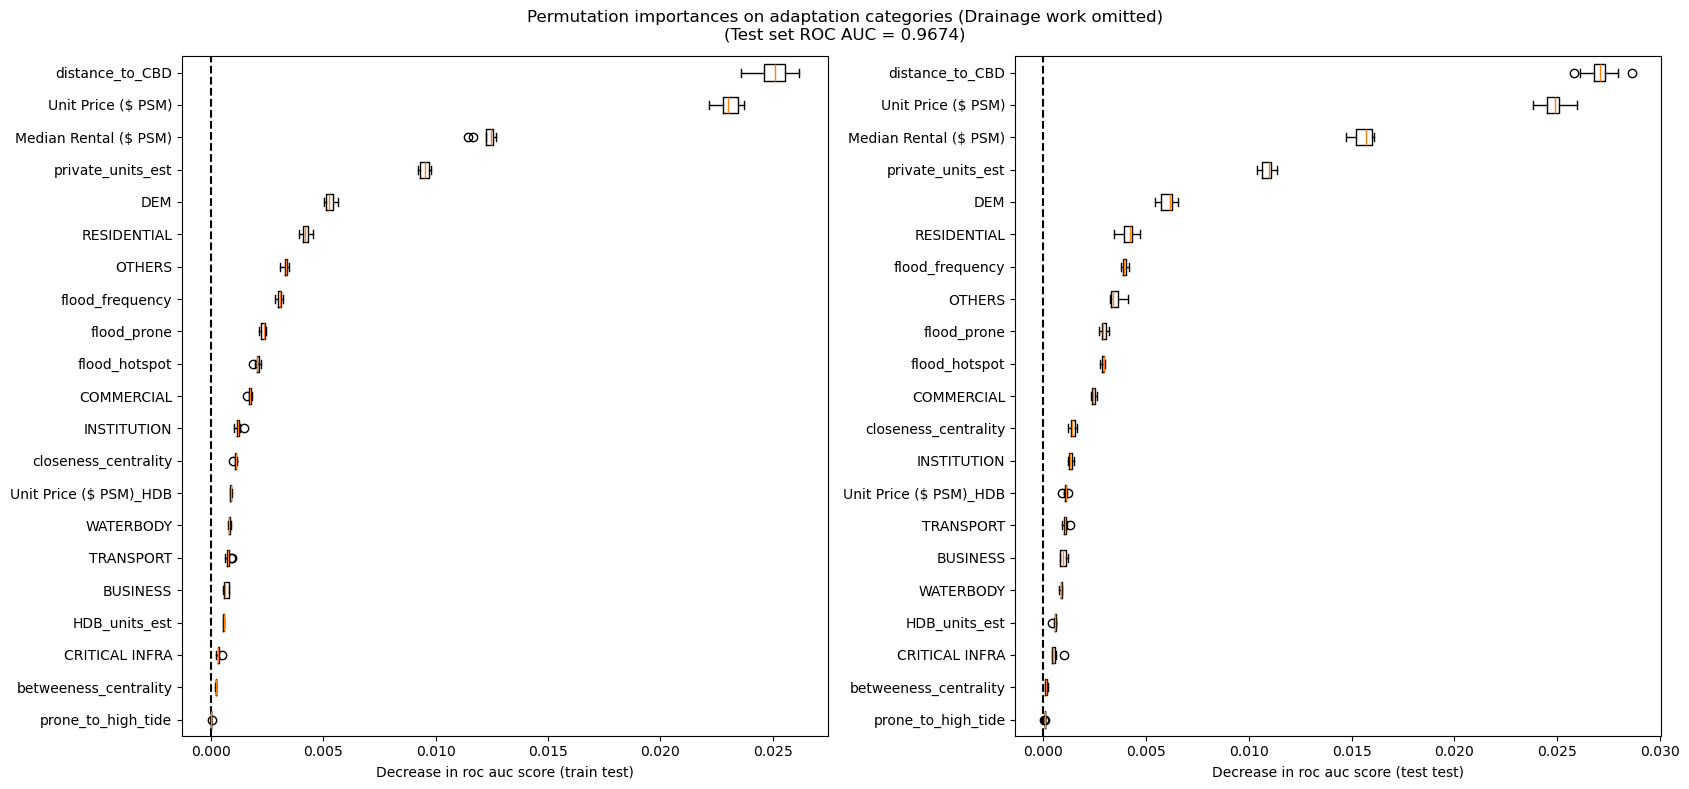

In [506]:
# intiialise random state
random_state=0
max_roc_score = 0
max_random_state=0

# drop drainage works
# initialise dataset
df = roads_id_df_dropped[~roads_id_df_dropped['work_categories'].isin(['Drainage Work'])]
y = df['treat_adaptation']
df = df.drop(columns=['work_categories','treat_adaptation'])
features = df.columns.to_list()
print(f"Features: {features}")
X = df

for random_state in [0,42,100]:
    # split test train data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=random_state
    )
    # initialise classifier
    classifier = HistGradientBoostingClassifier(random_state=random_state)
    y_pred = classifier.fit(X_train, y_train).predict(X_test)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    print(f"MCC score: {mcc:.4f}\nROC AUC score: {roc_auc:.4f}")
    # y_pred_proba = classifier.predict_proba(X_test)
    print(f"Baseline accuracy on test data: {classifier.score(X_test, y_test):.2}")

    if roc_auc > max_roc_score:
        max_roc_score = roc_auc
        max_random_state = random_state
# result = permutation_importance(classifier, X, y, n_repeats=10,
#                                 random_state=random_state)
# result.importances_mean
# result.importances_std


print(f"max ROC AUC score: {max_roc_score:.4f}; max random state: {max_random_state}")

fig, axes = plt.subplots(1,2, figsize=(17,8))
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=max_random_state
    )
classifier = HistGradientBoostingClassifier(random_state=max_random_state)
y_pred = classifier.fit(X_train, y_train).predict(X_test)

# pickle classifier
save_fp = os.path.join(r"Exported_Data\adaptation\ML_models",
                       f"ML_drainageWorkOmitted_adaptation_{datetime.today().strftime('%Y%m%d')}.pkl")
# if not os.path.exists(save_fp):
print(f"Trained model exported as: {save_fp}")
utils.pickle_data(classifier, save_fp = save_fp)
    
# plot
MLHelper.plot_permutation_importance(classifier, X_train, y_train, axes[0], scoring='roc_auc', random_state=max_random_state)
MLHelper.plot_permutation_importance(classifier, X_test, y_test, axes[1], scoring='roc_auc', random_state=max_random_state)
for lab, ax in zip(['train','test'],axes.flatten()):
    ax.set_xlabel(f"Decrease in roc auc score ({lab} test)")
fig.suptitle(
    f"Permutation importances on adaptation categories (Drainage work omitted)\n(Test set ROC AUC = {max_roc_score:.4f})"
)
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
                         f"ML_drainageWorkOmitted_adaptation_roc_auc_{datetime.today().strftime('%Y%m%d')}.svg"), bbox_inches = 'tight')
plt.show()

### On all adaptation categories

Features: ['BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'distance_to_CBD', 'Unit Price ($ PSM)', 'private_units_est', 'prone_to_high_tide', 'betweeness_centrality', 'closeness_centrality', 'DEM', 'Unit Price ($ PSM)_HDB', 'HDB_units_est', 'Median Rental ($ PSM)', 'flood_frequency', 'flood_hotspot', 'flood_prone']
MCC score: 0.8780
ROC AUC score: 0.9316
Baseline accuracy on test data: 0.94
MCC score: 0.8811
ROC AUC score: 0.9330
Baseline accuracy on test data: 0.94
MCC score: 0.8744
ROC AUC score: 0.9289
Baseline accuracy on test data: 0.94
max ROC AUC score: 0.9330; max random state: 42


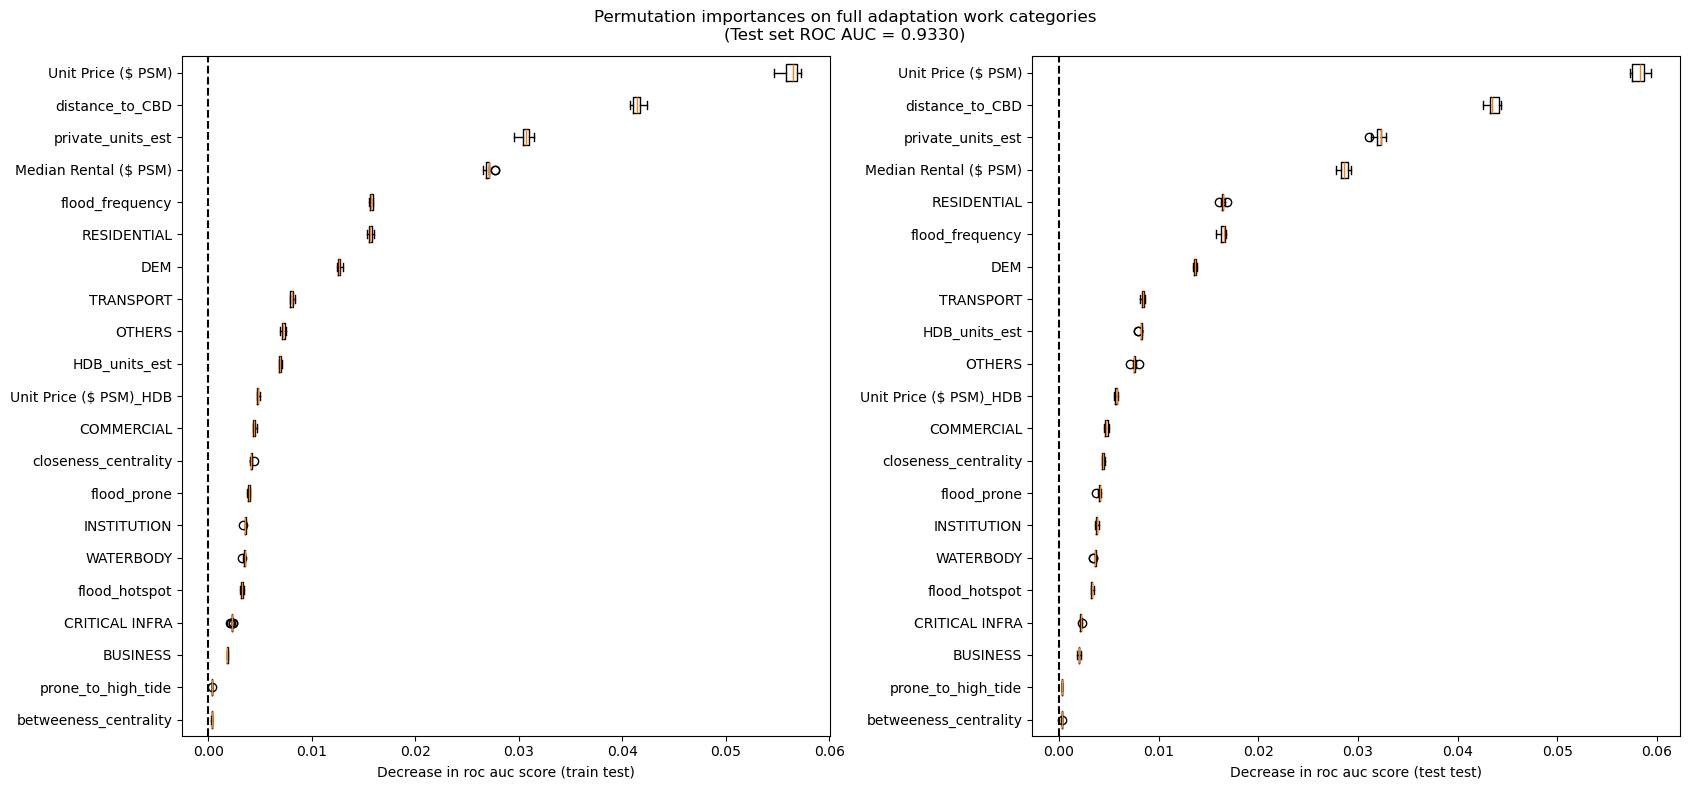

In [570]:
# intiialise random state
random_state=0
max_roc_score = 0
max_random_state=0

# initialise dataset
df = roads_id_df_dropped.drop(columns=['work_categories','treat_adaptation'])
features = df.columns.to_list()
print(f"Features: {features}")
X = df
y = roads_id_df_dropped['treat_adaptation']#.values

for random_state in [0,42,100]:
    # split test train data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=random_state
    )
    # initialise classifier
    classifier = HistGradientBoostingClassifier(random_state=random_state)
    y_pred = classifier.fit(X_train, y_train).predict(X_test)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    print(f"MCC score: {mcc:.4f}\nROC AUC score: {roc_auc:.4f}")
    # y_pred_proba = classifier.predict_proba(X_test)
    print(f"Baseline accuracy on test data: {classifier.score(X_test, y_test):.2}")

    if roc_auc > max_roc_score:
        max_roc_score = roc_auc
        max_random_state = random_state
# result = permutation_importance(classifier, X, y, n_repeats=10,
#                                 random_state=random_state)
# result.importances_mean
# result.importances_std


print(f"max ROC AUC score: {max_roc_score:.4f}; max random state: {max_random_state}")

fig, axes = plt.subplots(1,2, figsize=(17,8))
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=max_random_state
    )
classifier = HistGradientBoostingClassifier(random_state=max_random_state)
y_pred = classifier.fit(X_train, y_train).predict(X_test)

# # pickle classifier
# save_fp = os.path.join(r"Exported_Data\adaptation\ML_models",
#                        f"ML_full_adaptation_{datetime.today().strftime('%Y%m%d')}.pkl")
# # if not os.path.exists(save_fp):
# print(f"Trained model exported as: {save_fp}")
# utils.pickle_data(classifier, save_fp = save_fp)

# plot
features_sorted_train = MLHelper.plot_permutation_importance(classifier, X_train, y_train, axes[0], scoring='roc_auc', random_state=max_random_state)
features_sorted_test = MLHelper.plot_permutation_importance(classifier, X_test, y_test, axes[1], scoring='roc_auc', random_state=max_random_state)
# export permutation importance variables
pd.DataFrame({'train':reversed(features_sorted_train),
              'test':reversed(features_sorted_test),
              'Rank':list(range(1,len(features_sorted_train)+1))}).\
                to_csv(os.path.join(r"Exported_Data\adaptation\processed_results",
                         f"ML_full_adaptation_roc_auc_20260423.csv"),index=False)
# plot
for lab, ax in zip(['train','test'],axes.flatten()):
    ax.set_xlabel(f"Decrease in roc auc score ({lab} test)")
fig.suptitle(
    f"Permutation importances on full adaptation work categories\n(Test set ROC AUC = {max_roc_score:.4f})"
)
plt.tight_layout()
# plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
#                          f"ML_full_adaptation_roc_auc_{datetime.today().strftime('%Y%m%d')}.svg"), bbox_inches = 'tight')
plt.show()

## Get probability of y_pred

- returns the probability estimates for each possible class rather than a single discrete label.
- Provides the specific confidence level for every class
- In a binary classification (classes 0 and 1), the result has two columns: [probability of class 0, probability of class 1].
- get probability of predicting `treat_adaptation`

### Import trained ML model

In [512]:
# import ML model that is trained with 
# classifier = utils.load_pickle(r"Exported_Data\adaptation\ML_models\ML_full_adaptation_20260421.pkl")
classifier = utils.load_pickle(r"Exported_Data\adaptation\ML_models\ML_full_adaptation_20260423.pkl")
# initialise dataset
df = roads_id_df_dropped.drop(columns=['work_categories','treat_adaptation'])
features = df.columns.to_list()
X = df
y = roads_id_df_dropped['treat_adaptation']#.values
# split train test data
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42#100
    )

# tets if loaded trained data works on previous test set
y_pred = classifier.predict(X_test)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print(f"MCC score: {mcc:.4f}\nROC AUC score: {roc_auc:.4f}")

# TODO: use this trained ML model to predict the 20260422 dataset with the expanded control group

MCC score: 0.8811
ROC AUC score: 0.9330


### Import data with unseen data

- TODO: Train the ML model where treatment and control group share the same subzone
    - easily filter where `df[df['treat_adaptation']==1]['SUBZONE_N].unique()`
- and then test the ML model with expanded control group

In [511]:
# roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer500_20260422.csv")
roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer200_20260423.csv")
print(f"Number of unique Road_ID: {roads_id_df['Road_ID'].nunique()}")
roads_id_df['work_categories'] = roads_id_df['work_categories'].fillna("None")
# for NA Median Rental, assign 0
roads_id_df['Median Rental ($ PSM)'] = roads_id_df['Median Rental ($ PSM)'].fillna(0)
roads_id_df['Unit Price ($ PSM)_HDB'] = roads_id_df['Unit Price ($ PSM)_HDB'].fillna(0)
roads_id_df['Unit Price ($ PSM)'] = roads_id_df['Unit Price ($ PSM)'].fillna(0)
columns_with_nas = roads_id_df.columns[(roads_id_df.apply(lambda x: x.isna().sum()) > 0)]
print(f"Columns with NAs: {columns_with_nas}")
roads_id_df_dropped = roads_id_df.drop(columns=columns_with_nas)
roads_id_df_dropped = roads_id_df_dropped.drop(columns=['Road_ID','SUBZONE_N','LATITUDE', 'LONGITUDE'])
if set(['u','v','key']).issubset(set(roads_id_df_dropped.columns)):
    roads_id_df_dropped = roads_id_df_dropped.drop(columns=['u','v','key'])
roads_id_df_dropped[roads_id_df_dropped.select_dtypes(include="bool").columns] = roads_id_df_dropped.select_dtypes(include="bool").astype(int)
print(roads_id_df_dropped.columns)
roads_id_df_dropped
print(f"Length of df: {len(roads_id_df_dropped)}")

# get X and y data
X = roads_id_df_dropped.drop(columns=['work_categories','treat_adaptation'])
y = roads_id_df_dropped['treat_adaptation']
print(f"X shape: {X.shape}, y: {y.shape}")

roads_id_df_dropped.head()

Number of unique Road_ID: 45756
Columns with NAs: Index(['ROAD_NAME', 'Drainage_ID', 'Drainage_Date', 'work_types'], dtype='object')
Index(['treat_adaptation', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA',
       'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY',
       'distance_to_CBD', 'work_categories', 'Unit Price ($ PSM)',
       'private_units_est', 'prone_to_high_tide', 'betweeness_centrality',
       'closeness_centrality', 'DEM', 'Unit Price ($ PSM)_HDB',
       'HDB_units_est', 'Median Rental ($ PSM)', 'flood_frequency',
       'flood_hotspot', 'flood_prone'],
      dtype='object')
Length of df: 113027
X shape: (113027, 21), y: (113027,)


C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\3352521477.py:2: DtypeWarning: Columns (15,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  roads_id_df = pd.read_csv(r"Exported_Data\adaptation\Road_ID_buffer200_20260423.csv")


,treat_adaptation,BUSINESS,COMMERCIAL,CRITICAL INFRA,INSTITUTION,OTHERS,RESIDENTIAL,TRANSPORT,WATERBODY,distance_to_CBD,...,prone_to_high_tide,betweeness_centrality,closeness_centrality,DEM,Unit Price ($ PSM)_HDB,HDB_units_est,Median Rental ($ PSM),flood_frequency,flood_hotspot,flood_prone
0,1,0.005173,0.013981,0.0,0.005137,0.028278,0.056041,0.033452,0.000000,4.414637,...,0,0.000019,0.022075,8.22,5901.752662,17,91.886401,1,1,1
1,1,0.005173,0.013874,0.0,0.005095,0.027881,0.056737,0.033194,0.000000,4.414400,...,0,0.000200,0.022293,8.22,5901.752662,17,91.886401,1,1,1
2,1,0.005173,0.022883,0.0,0.023980,0.035060,0.057519,0.041973,0.000000,4.443204,...,0,0.000287,0.021976,6.88,5901.752662,17,91.886401,1,1,1
3,1,0.005173,0.023388,0.0,0.022741,0.037220,0.058422,0.042473,0.000000,4.452412,...,0,0.000618,0.023294,6.88,5901.752662,17,91.886401,1,1,1
4,1,0.000000,0.017182,0.0,0.022326,0.048694,0.043477,0.034421,0.004069,4.516943,...,0,0.000031,0.023387,6.41,5901.752662,17,91.886401,1,1,1


### Get predicted and pred_prob

In [516]:
y_pred = classifier.predict(X)
y_pred_proba = classifier.predict_proba(X)
print(f"y_pred shape: {y_pred.shape}; y_pred_proba shape: {y_pred_proba.shape}")
print(f"min prob: {y_pred_proba[:,1].min()}, max prob: {y_pred_proba[:,1].max():.4f}")
mcc = matthews_corrcoef(y, y_pred)
roc_auc = roc_auc_score(y, y_pred)
print(f"MCC score on unseen data: {mcc:.4f}\nROC AUC score on unseen data: {roc_auc:.4f}")
# index the second column to get the probability where y==1 (i.e. where adaptation took place)
treat_adaptation_pred_df = pd.DataFrame({'treat_adaptation_prob':y_pred_proba[:,1], 'treat_adaptation_pred': y_pred},index=X.index)
# concat prediction with original df
treat_adaptation_pred_df = pd.concat([roads_id_df,treat_adaptation_pred_df],axis=1)

print(f"length of df: {len(treat_adaptation_pred_df)}")
print(treat_adaptation_pred_df.columns)
print(f"Number of unique Road_ID and subzone: {len(treat_adaptation_pred_df[['Road_ID','SUBZONE_N']].drop_duplicates())}")
print(f"Number of unique Road_ID: {treat_adaptation_pred_df['Road_ID'].nunique()}")
# reconstruct the u,v,key from Road_ID
roads_gdf = ox.graph_to_gdfs(G_car, nodes=False, edges=True).reset_index()
roads_gdf = roads_gdf[['u','v','key']].reset_index(names="Road_ID")
print(roads_gdf.index)
treat_adaptation_pred_df = treat_adaptation_pred_df.merge(roads_gdf,how='left',on=["Road_ID",'u','v','key'])
print(treat_adaptation_pred_df.columns)
print(f"length of df: {len(treat_adaptation_pred_df)}")
# export to csv
treat_adaptation_pred_df.to_csv(os.path.join(r"Exported_Data\adaptation\processed_results",
                                              f"Road_ID_buffer{drainage_buffer}_adaptationProbPredict_{datetime.today().strftime('%Y%m%d')}.csv"),
                                              index=False)

y_pred shape: (113027,); y_pred_proba shape: (113027, 2)
min prob: 0.0009908085788671779, max prob: 0.9983
MCC score on unseen data: 0.8886
ROC AUC score on unseen data: 0.9370
length of df: 113027
Index(['treat_adaptation', 'Road_ID', 'u', 'v', 'key', 'BUSINESS',
       'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL',
       'TRANSPORT', 'WATERBODY', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME',
       'Drainage_ID', 'Drainage_Date', 'work_types', 'work_categories',
       'Unit Price ($ PSM)', 'private_units_est', 'prone_to_high_tide',
       'betweeness_centrality', 'closeness_centrality', 'LATITUDE',
       'LONGITUDE', 'DEM', 'Unit Price ($ PSM)_HDB', 'HDB_units_est',
       'Median Rental ($ PSM)', 'flood_frequency', 'flood_hotspot',
       'flood_prone', 'treat_adaptation_prob', 'treat_adaptation_pred'],
      dtype='object')
Number of unique Road_ID and subzone: 95164
Number of unique Road_ID: 45756
RangeIndex(start=0, stop=45756, step=1)
Index(['treat_ada

### Import logit and ML-predicted probabilities

In [609]:
ML_prob = pd.read_csv(r"Exported_Data\adaptation\processed_results\Road_ID_buffer200_adaptationProbPredict_20260423.csv")
print(ML_prob.columns, 
      f"\nLength of ML_prob: {len(ML_prob)}",
      f"\nNo. unique Road_ID: {ML_prob['Road_ID'].nunique()}",
      ML_prob.index)
logit_prob = pd.read_csv(r"Exported_Data\adaptation\processed_results\Road_ID_buffer200_adaptationLogitProbPredict_20260423.csv")
print(logit_prob.columns, 
      f"\nLength of logit_prob: {len(logit_prob)}",
      f"\nNo. unique Road_ID: {logit_prob['Road_ID'].nunique()}",
      logit_prob.index)
# concat probabilities from ML and probit models
# check if sequence of 
print(f"Check if sequence of Road_ID is the same: {(ML_prob['Road_ID'] == logit_prob['Road_ID']).all()}") 
ML_prob['treat_adaptation_prob_logit'] = logit_prob['treat_adaptation_prob_logit']
# # export to csv
# ML_prob.to_csv(os.path.join(r"Exported_Data\adaptation\processed_results",
#                                               f"Road_ID_buffer{drainage_buffer}_adaptationProbPredict_MLProbit_20260423.csv"),
#                                               index=False)

Index(['treat_adaptation', 'Road_ID', 'u', 'v', 'key', 'BUSINESS',
       'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL',
       'TRANSPORT', 'WATERBODY', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME',
       'Drainage_ID', 'Drainage_Date', 'work_types', 'work_categories',
       'Unit Price ($ PSM)', 'private_units_est', 'prone_to_high_tide',
       'betweeness_centrality', 'closeness_centrality', 'LATITUDE',
       'LONGITUDE', 'DEM', 'Unit Price ($ PSM)_HDB', 'HDB_units_est',
       'Median Rental ($ PSM)', 'flood_frequency', 'flood_hotspot',
       'flood_prone', 'treat_adaptation_prob', 'treat_adaptation_pred'],
      dtype='object') 
Length of ML_prob: 113027 
No. unique Road_ID: 45756 RangeIndex(start=0, stop=113027, step=1)
Index(['Road_ID', 'treat_adaptation_prob_logit', 'treat_adaptation'], dtype='object') 
Length of logit_prob: 113027 
No. unique Road_ID: 45756 RangeIndex(start=0, stop=113027, step=1)
Check if sequence of Road_ID is the same: True


C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\1950650534.py:1: DtypeWarning: Columns (15,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  ML_prob = pd.read_csv(r"Exported_Data\adaptation\processed_results\Road_ID_buffer200_adaptationProbPredict_20260423.csv")


### Stats for adaptation groups

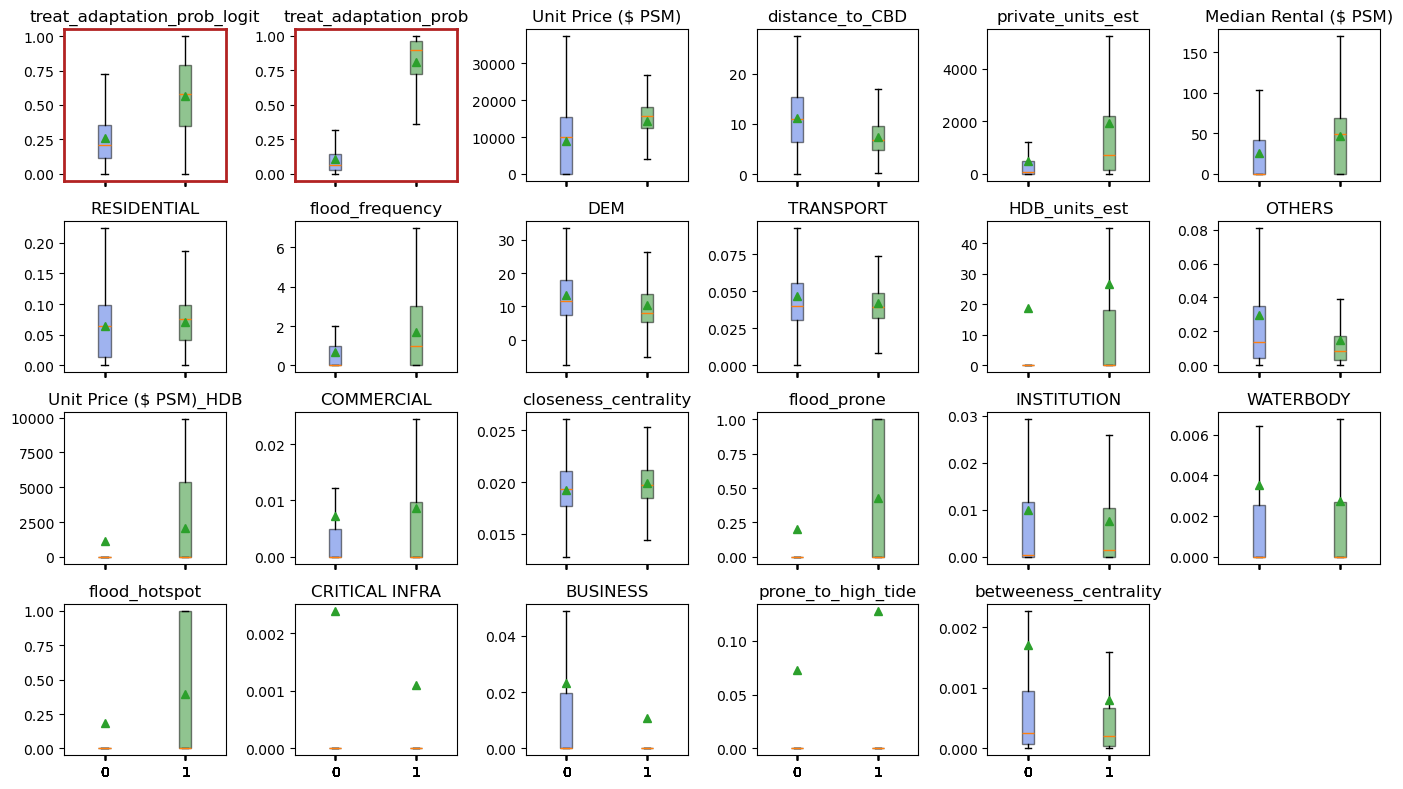

In [602]:
import matplotlib.colors as mcolors
# show statistics for adaptation==1 and 0
features_sorted = pd.read_csv(os.path.join(r"Exported_Data\adaptation\processed_results",
                         f"ML_full_adaptation_roc_auc_20260423.csv"))
features_sorted = features_sorted['test'].to_list() 

def plot_adaptation_boxplot(ML_prob,features_sorted=None,colors=['royalblue','forestgreen']):
    predict_prob_df = ML_prob.drop(columns=['Road_ID', 'u', 'v', 'key','SUBZONE_N', 'ROAD_NAME',
                        'Drainage_ID', 'Drainage_Date', 'work_types', 'work_categories',
                        'LATITUDE','LONGITUDE','treat_adaptation_pred'])
    predict_prob_df[predict_prob_df.select_dtypes(include=['bool']).columns] = predict_prob_df.select_dtypes(include=['bool']).astype(int)
    predict_prob_df = pd.melt(predict_prob_df,id_vars=['treat_adaptation'])
    
    if features_sorted is None:
        features_sorted = list(predict_prob_df['variable'].unique())
    else:
        features = list(predict_prob_df['variable'].unique())
        features_sorted = list(set(features) - set(features_sorted)) + features_sorted

    fig, axes = plt.subplots(4,6, figsize=(14,8),sharex=True)
    for i,(f, ax) in enumerate(zip(features_sorted, axes.flatten())):
        df = predict_prob_df[predict_prob_df['variable']==f]
        df = {k[0]:v['value'].values for k,v in df.groupby(['treat_adaptation'])}
        bplot = ax.boxplot(list(df.values()),
                           showmeans=True,
                   patch_artist=True,  # fill with color
                   tick_labels=list(df),
                   showfliers=False,
                   
                   )  # will be used to label x-ticks

        # fill with colors
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        # ax.set_xlim(-0.5,1.5)
        ax.set_title(f)
        if i < 2:
            for spine in ax.spines.values():
                spine.set_edgecolor('firebrick')
                spine.set_linewidth(2)
                
    axes[-1,-1].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
                         f"ML_full_adaptation_statsBoxplot_20260423.svg"), bbox_inches = 'tight')
    plt.show()
    return 

plot_adaptation_boxplot(ML_prob,features_sorted=features_sorted)

Index(['Feature_', 'treat_adaptation_', 'value_mean', 'value_std'], dtype='object')
Number of features: 23


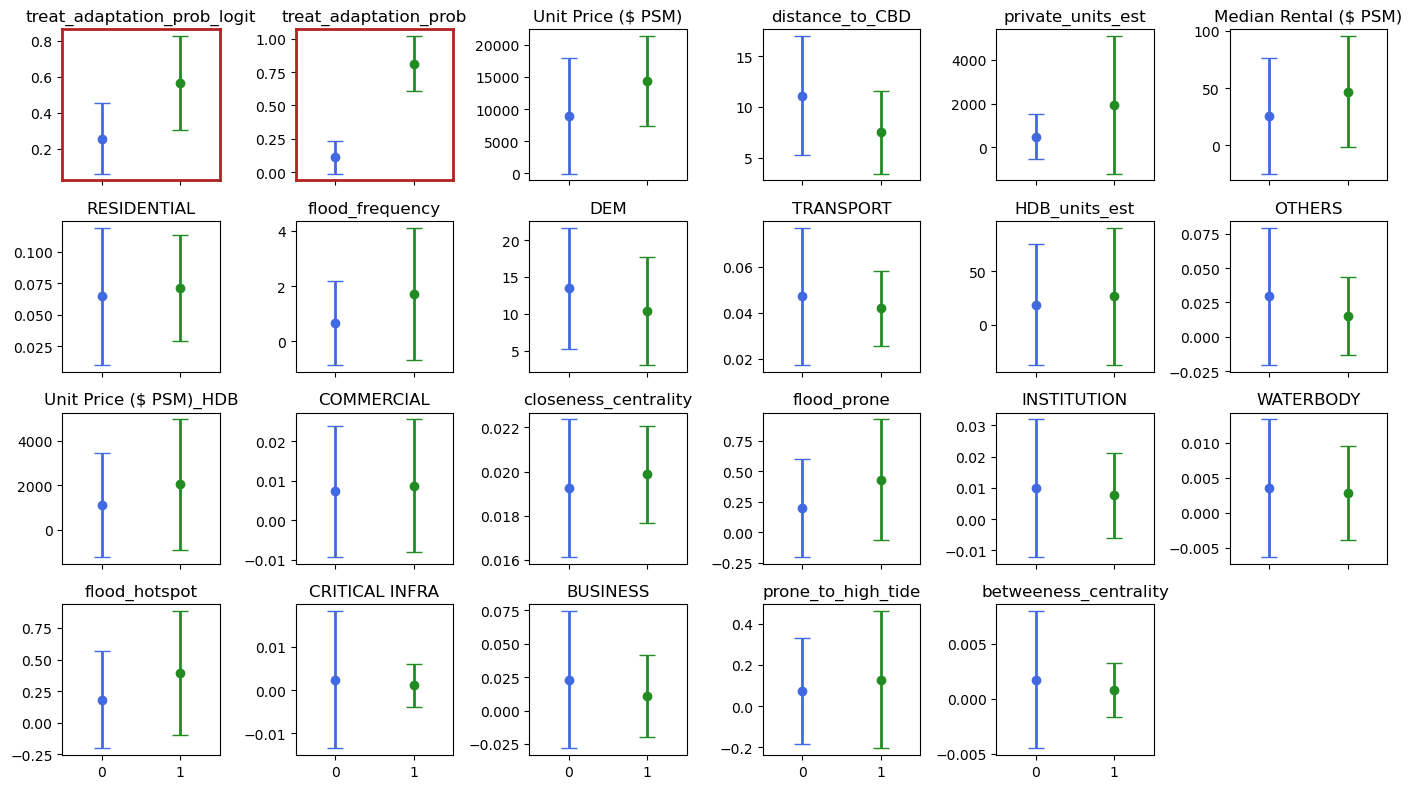

In [605]:
import matplotlib.colors as mcolors

features_sorted = pd.read_csv(os.path.join(r"Exported_Data\adaptation\processed_results",
                         f"ML_full_adaptation_roc_auc_20260423.csv"))
features_sorted = features_sorted['test'].to_list() 

def plot_adaptation_errorbar(ML_prob,features_sorted=None,colors=['royalblue','forestgreen']):   
    # show statistics for adaptation==1 and 0
    predict_prob_df = ML_prob.drop(columns=['Road_ID', 'u', 'v', 'key','SUBZONE_N', 'ROAD_NAME',
                        'Drainage_ID', 'Drainage_Date', 'work_types', 'work_categories',
                        'LATITUDE','LONGITUDE','treat_adaptation_pred'])
    predict_prob_df[predict_prob_df.select_dtypes(include=['bool']).columns] = predict_prob_df.select_dtypes(include=['bool']).astype(int)
    predict_prob_df = predict_prob_df.groupby(['treat_adaptation']).describe(percentiles=[0.5]).T.reset_index(names=['Feature','Stats'])
    predict_prob_df = predict_prob_df[predict_prob_df['Stats'].isin(['mean','std'])]
    predict_prob_df = pd.melt(predict_prob_df, id_vars=['Feature','Stats']).pivot(columns=['Stats'],index=['Feature','treat_adaptation']).reset_index()
    predict_prob_df.columns = ['_'.join(col) for col in predict_prob_df.columns]
    print(predict_prob_df.columns)

    # plot
    if features_sorted is None:
        features_sorted = list(predict_prob_df['Feature_'].unique())
    else:
        features = list(predict_prob_df['Feature_'].unique())
        features_sorted = list(set(features) - set(features_sorted)) + features_sorted

    print(f"Number of features: {len(features_sorted)}")
    fig, axes = plt.subplots(4,6, figsize=(14,8),sharex=True)
    for i,(f, ax) in enumerate(zip(features_sorted, axes.flatten())):
        df = predict_prob_df[predict_prob_df['Feature_']==f]
        for (row_ix, row),c in zip(df.iterrows(),[mcolors.CSS4_COLORS['royalblue'],mcolors.CSS4_COLORS['forestgreen']]):
            ax.errorbar(row['treat_adaptation_'], row['value_mean'], yerr=row['value_std'],
                    fmt='o', linewidth=2, capsize=6,color=c
                    )

        # ax.set_xticks([0,1],labels=['No adaptation','Adaptation'])
        ax.set_xlim(-0.5,1.5)
        ax.set_title(f)
        if i < 2:
            for spine in ax.spines.values():
                spine.set_edgecolor('firebrick')
                spine.set_linewidth(2)
    axes[-1,-1].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
                            f"ML_full_adaptation_stats_20260423.svg"), bbox_inches = 'tight')
    plt.show()

plot_adaptation_errorbar(ML_prob,features_sorted=features_sorted,colors=['royalblue','forestgreen'])

# Adaptation analysis

- sjoin `treat_adaptation_pred_df` with stacked DID
- conduct triple DDD: Treat x Post x Adaptation

## Import stacked DID

In [607]:
residential_df = Data.get_private_residential_df(Data.PRIVATE_RESIDENTIAL_FP)
# map private residential coordinates to the nearest road
# get edges from coordinates
lat = residential_df["LATITUDE"]
lon = residential_df["LONGITUDE"]
edges = ox.nearest_edges(G_car,lon,lat)
for i, col_name in enumerate(['u','v','key']):
    residential_df[col_name] = [e[i] for e in edges]
# print(type(residential_df))
residential_df = residential_df[['Property_ID','geometry','u','v','key']]
# reconstruct Road ID from u,v,key
roads_gdf = ox.graph_to_gdfs(G_car, nodes=False, edges=True).reset_index()
roads_gdf = roads_gdf[['u','v','key']].reset_index(names="Road_ID")
residential_df = residential_df.merge(roads_gdf,how='left',on=['u','v','key'])
print(f"Number of unique Road_ID: {residential_df['Road_ID'].nunique()}")
stacked_did = pd.read_csv(r"Exported_Data\stacked_did\PrivRes_20260403_dsmall170dbig240_networkDepthNone.csv")
print(stacked_did.columns)
print(f"Length of df: {len(stacked_did)}")
# join both df by Property_ID, so that we can reinstate the point geometry of residential properties
stacked_did = stacked_did.merge(residential_df,on='Property_ID',how='left')
print(f"Length of df: {len(stacked_did)}")
print(stacked_did.columns)
print(f"Number of NAs in u: {stacked_did['u'].isna().sum()}")
print(f"Number of unique Road_ID: {stacked_did['Road_ID'].nunique()}")
stacked_did

min date: 2014-01-01 00:00:00, max date: 2025-06-22 00:00:00
Number of unique Road_ID: 7978
Index(['Property_ID', 'Building_Name', 'Transacted_Price_($)', 'Sale_Date',
       'Address', 'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)',
       'Unit_Price_($_PSM)', 'Property_Type', 'Tenure', 'Completion_Date',
       'Postal_Code', 'Postal_District', 'Postal_Sector', 'REGION_N',
       'PLN_AREA_N', 'ROAD_NAME', 'Project_Name', 'year', 'month',
       'Building_Age', 'Floor_level', 'is_ground_floor', 'Sale_Date_corrected',
       'SUBZONE_N', 'flooded_location', 'Flood_Date', 'Flood_ID', '_merge',
       'treat', 'Flood_Date_corrected', 'period_sale', 'period_flood',
       'period_D', 'post', 'contaminated_rows', 'potential_contamination'],
      dtype='object')
Length of df: 80858
Length of df: 80858
Index(['Property_ID', 'Building_Name', 'Transacted_Price_($)', 'Sale_Date',
       'Address', 'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)',
       'Unit_Price_($_PSM)', 'Property_Type', 'Tenu

,Property_ID,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,...,period_flood,period_D,post,contaminated_rows,potential_contamination,geometry,u,v,key,Road_ID
0,18,1 HUME AVENUE,928000,2014-01-08,1 HUME AVENUE #02-04,Resale,Strata,84.0,11048,Condominium/Apartment,...,160,-135,0,0,0,POINT (103.7687 1.35341),6180300656,5963664445,0,34735
1,19,15 HUME AVENUE,1200000,2014-01-08,15 HUME AVENUE #02-05,Resale,Strata,126.0,9524,Condominium/Apartment,...,160,-135,0,0,0,POINT (103.76843 1.3538),236594273,585164051,0,13687
2,22,1 BISHAN STREET 15,1144100,2014-01-09,1 BISHAN STREET 15 #26-07,New/Sub Sale,Strata,63.0,18160,Condominium/Apartment,...,70,-45,0,0,0,POINT (103.85072 1.35232),2524914105,5166391857,0,25745
3,32,4 SIN MING ROAD,1650000,2014-01-15,4 SIN MING ROAD #02-04,Resale,Strata,136.0,12132,Condominium/Apartment,...,61,-36,0,0,0,POINT (103.83643 1.35227),5649980618,5137810887,0,33765
4,33,1 BISHAN STREET 15,1671700,2014-01-15,1 BISHAN STREET 15 #21-10,New/Sub Sale,Strata,106.0,15771,Condominium/Apartment,...,70,-45,0,0,0,POINT (103.85072 1.35232),2524914105,5166391857,0,25745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80853,267930,109 WOODLANDS VIEW,1240000,2025-06-09,109 WOODLANDS VIEW #10-17,Resale,Strata,92.0,13478,Condominium/Apartment,...,13,149,1,0,0,POINT (103.81015 1.4434),4607047030,4607047031,0,30149
80854,267933,40 BELIMBING AVENUE,3915000,2025-06-11,40 BELIMBING AVENUE,Resale,Land,189.2,20692,Landed,...,35,127,1,0,0,POINT (103.87728 1.33258),1366637419,1366637418,0,22457
80855,267933,40 BELIMBING AVENUE,3915000,2025-06-11,40 BELIMBING AVENUE,Resale,Land,189.2,20692,Landed,...,100,62,1,0,0,POINT (103.87728 1.33258),1366637419,1366637418,0,22457
80856,267934,85 PHENG GECK AVENUE,2200000,2025-06-12,85 PHENG GECK AVENUE #19-13,Resale,Strata,162.0,13580,Condominium/Apartment,...,155,7,1,0,0,POINT (103.86998 1.333),1366619136,6038247100,0,22369


## Import predicted likelihood of adaptation

C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\2806294256.py:2: DtypeWarning: Columns (15,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  adaptation_prob_df = pd.read_csv(r"Exported_Data\adaptation\processed_results\Road_ID_buffer200_adaptationProbPredict_MLProbit_20260423.csv")


Index(['treat_adaptation', 'Road_ID', 'u', 'v', 'key', 'BUSINESS',
       'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL',
       'TRANSPORT', 'WATERBODY', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME',
       'Drainage_ID', 'Drainage_Date', 'work_types', 'work_categories',
       'Unit Price ($ PSM)', 'private_units_est', 'prone_to_high_tide',
       'betweeness_centrality', 'closeness_centrality', 'LATITUDE',
       'LONGITUDE', 'DEM', 'Unit Price ($ PSM)_HDB', 'HDB_units_est',
       'Median Rental ($ PSM)', 'flood_frequency', 'flood_hotspot',
       'flood_prone', 'treat_adaptation_prob', 'treat_adaptation_pred',
       'treat_adaptation_prob_logit'],
      dtype='object') 
Length of adaptation_prob_df: 113027 
No. unique Road_ID: 45756
Is stacked_did's Road_ID a subset of adaptation's Road_ID?       True


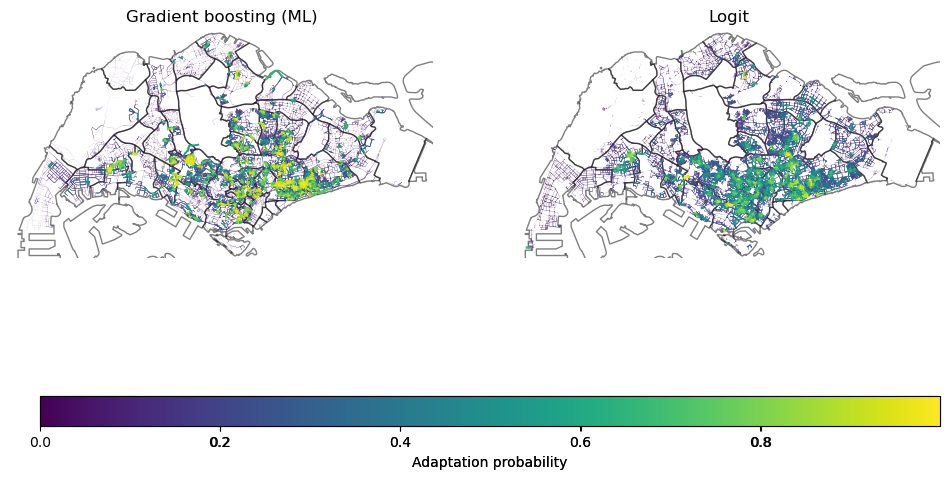

In [635]:
# check if stacked did Road_ID is a subset of adaptation_rob_df
adaptation_prob_df = pd.read_csv(r"Exported_Data\adaptation\processed_results\Road_ID_buffer200_adaptationProbPredict_MLProbit_20260423.csv")
print(adaptation_prob_df.columns, 
      f"\nLength of adaptation_prob_df: {len(adaptation_prob_df)}",
      f"\nNo. unique Road_ID: {adaptation_prob_df['Road_ID'].nunique()}")

print(f"Is stacked_did's Road_ID a subset of adaptation's Road_ID? \
      {set(stacked_did['Road_ID'].unique()).issubset(set(adaptation_prob_df['Road_ID'].unique()))}")

def plot_adaptation_prob_map(G,planningArea_shp,adaptation_prob_df,cmap="coolwarm",cbar_orientation="horizontal",
                    colorbar_label="",edge_size=5,save_fp=None):
      # reconstruct Road ID from u,v,key
      roads_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()
      roads_gdf = roads_gdf[['u','v','key','geometry']].reset_index(names="Road_ID")

      roads_prob = roads_gdf.merge(adaptation_prob_df.drop_duplicates(subset=['u','v','key','Road_ID']),
                  how='left',on=['u','v','key','Road_ID'])
      
      roads_prob = roads_prob[['u','v','key','treat_adaptation_prob','treat_adaptation_prob_logit']].set_index(['u','v','key'])
      
      # plot
      fig, axes = plt.subplots(1,2, figsize=(12,6))
      for ax in axes.flatten():
            planningArea_shp.plot(ax=ax, fc="None",ec="k",alpha=0.5)
      plot_utils.plot_edge(G,roads_prob['treat_adaptation_prob'].to_dict(),
                           ax=axes[0],colorbar_label="Adaptation probability",
                           cmap=cmap, cbar_orientation=cbar_orientation,edge_size=edge_size)
      
      plot_utils.plot_edge(G,roads_prob['treat_adaptation_prob_logit'].to_dict(),
                           ax=axes[1],colorbar_label="Adaptation probability",
                           cmap=cmap, cbar_orientation=cbar_orientation,edge_size=edge_size)
      
      axes[0].set_title('Gradient boosting (ML)')
      axes[1].set_title('Logit')
      if save_fp is not None:
            plt.savefig(save_fp, bbox_inches = 'tight')
      plt.show()
      return 

plot_adaptation_prob_map(G_car,planningArea_shp,
                         adaptation_prob_df,cmap="viridis",edge_size=2, 
                         save_fp = os.path.join(os.getcwd(),"Exported_Data","exported_figures",
                              f"map_ML_Probit_adaptation_roads_20260423.png"))

## Merge adaptation and stacked DID

Length of stacked_did df: 80858
Length of adaptation_stacked_did df: 80860
_merge
both          80860
left_only         0
right_only        0
Name: count, dtype: int64
Sum of NAs in treat_adaptation_prob:  0
Sum of NAs in treat_adaptation_prob_logit:  0


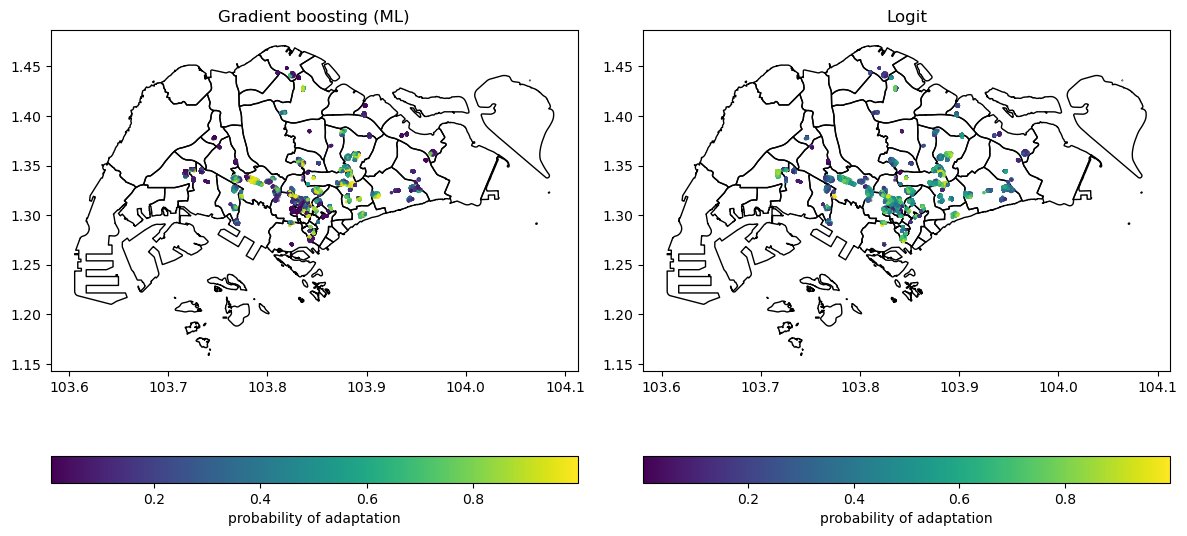

In [623]:
print(f"Length of stacked_did df: {len(stacked_did)}")
adaptation_stacked_did = stacked_did.drop(columns=['_merge']).merge(adaptation_prob_df[['Road_ID','treat_adaptation_prob','treat_adaptation_prob_logit']].drop_duplicates(),
                  how='left',on='Road_ID',indicator=True)
print(f"Length of adaptation_stacked_did df: {len(adaptation_stacked_did)}")
# check that the merge is from both columns, i.e. Road_ID exists in both df
print(adaptation_stacked_did['_merge'].value_counts())
# check if there's NAs in prob
print("Sum of NAs in treat_adaptation_prob: ",adaptation_stacked_did['treat_adaptation_prob'].isna().sum())
print("Sum of NAs in treat_adaptation_prob_logit: ",adaptation_stacked_did['treat_adaptation_prob_logit'].isna().sum())
adaptation_stacked_did.columns
# convert to gdf
adaptation_stacked_did = gpd.GeoDataFrame(data=adaptation_stacked_did, geometry = adaptation_stacked_did['geometry'], crs=4326)
# plot probability based on geometry
fig, axes = plt.subplots(1,2, figsize=(12,6))
for ax in axes.flatten():
    planningArea_shp.plot(ax=ax,fc="None",ec="k")
adaptation_stacked_did.plot(ax=axes[0], column='treat_adaptation_prob',
                            legend=True,markersize=2,alpha=0.5,
                            legend_kwds={'orientation':'horizontal','label':'probability of adaptation'})
adaptation_stacked_did.plot(ax=axes[1], column='treat_adaptation_prob_logit',
                            legend=True,markersize=2,alpha=0.5,
                            legend_kwds={'orientation':'horizontal','label':'probability of adaptation'})
axes[0].set_title('Gradient boosting (ML)')
axes[1].set_title('Logit')
plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(),"Exported_Data","exported_figures",
                         f"map_ML_Probit_adaptation_20260423.png"), bbox_inches = 'tight')
plt.show()

C:\Users\hypak\AppData\Local\Temp\ipykernel_20580\487411893.py:2: DtypeWarning: Columns (12,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  treat_adaptation_pred_df = pd.read_csv(os.path.join(r"Exported_Data\adaptation",


Index(['treat_adaptation', 'Road_ID', 'BUSINESS', 'COMMERCIAL',
       'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT',
       'WATERBODY', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage_Date', 'work_types', 'work_categories', 'Unit Price ($ PSM)',
       'private_units_est', 'LATITUDE', 'LONGITUDE', 'prone_to_high_tide',
       'betweeness_centrality', 'closeness_centrality', 'DEM',
       'Unit Price ($ PSM)_HDB', 'HDB_units_est', 'Median Rental ($ PSM)',
       'flood_frequency', 'flood_hotspot', 'flood_prone',
       'treat_adaptation_prob', 'treat_adaptation_pred', 'u', 'v', 'key'],
      dtype='object')
Length of treat_adaptation_pred_df df: 71427
Length of stacked_did df: 80858
Length of df: 81394
Index(['Property_ID', 'Building_Name', 'Transacted_Price_($)', 'Sale_Date',
       'Address', 'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)',
       'Unit_Price_($_PSM)', 'Property_Type', 'Tenure', 'Completion_Date',
       'Postal_Code

<Axes: >

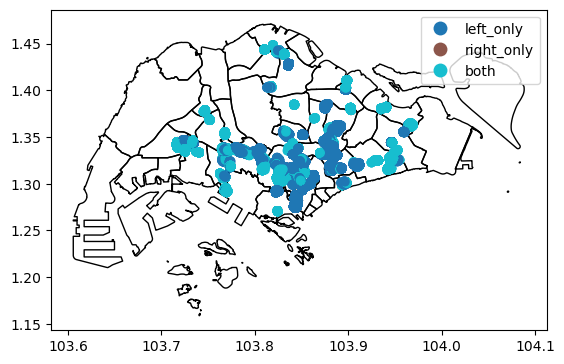

In [401]:
# treat_adaptation_pred_df = gpd.read_file(r"Exported_Data\adaptation\Road_ID_buffer500_adaptationProbPredict_20260421.geojson")
treat_adaptation_pred_df = pd.read_csv(os.path.join(r"Exported_Data\adaptation",
                                              f"Road_ID_buffer500_adaptationProbPredict_20260422.csv"))
print(treat_adaptation_pred_df.columns)
print(f"Length of treat_adaptation_pred_df df: {len(treat_adaptation_pred_df)}")
print(f"Length of stacked_did df: {len(stacked_did)}")
adaptation_stacked_did = stacked_did.drop(columns=['_merge']).merge(treat_adaptation_pred_df, 
                                           how='left', on=['SUBZONE_N','u','v','key'], indicator=True)
print(f"Length of df: {len(adaptation_stacked_did)}")
print(adaptation_stacked_did.columns)
print(adaptation_stacked_did['_merge'].value_counts())
adaptation_stacked_did = gpd.GeoDataFrame(data=adaptation_stacked_did, geometry = adaptation_stacked_did['geometry'], crs=residential_df.crs)
ax = planningArea_shp.plot(fc="None",ec="k")
adaptation_stacked_did.plot(ax=ax, column='_merge',legend=True)

In [415]:
# # reconstruct the u,v,key from Road_ID
roads_gdf = ox.graph_to_gdfs(G_car, nodes=False, edges=True).reset_index()
roads_gdf = roads_gdf[['u','v','key']].reset_index(names="Road_ID")
# print(roads_gdf[['u', 'v', 'key']].merge(stacked_did[['u', 'v', 'key']],
#                                      how='outer',on=['u', 'v', 'key'], indicator=True)['_merge'].value_counts())
# print(roads_gdf[['u', 'v', 'key']].merge(treat_adaptation_pred_df[['u', 'v', 'key']],
#                                      how='outer',on=['u', 'v', 'key'], indicator=True)['_merge'].value_counts())
print(roads_gdf["Road_ID"].nunique())
print(len(roads_gdf[['u', 'v', 'key']].drop_duplicates()))
print(len(stacked_did[['u', 'v', 'key']].drop_duplicates()))
print(roads_id_df["Road_ID"].nunique())

45756
45756
1406
19240


## Merge adaptation and stacked DID

In [331]:
print(stacked_did.columns)
print(stacked_did[['u', 'v', 'key']].nunique())
print(treat_adaptation_pred_df.columns)
print(treat_adaptation_pred_df[['u', 'v', 'key']].nunique())
stacked_did[['u', 'v', 'key']].merge(treat_adaptation_pred_df[['u', 'v', 'key']],
                                     how='left',on=['u', 'v', 'key'], indicator=True)['_merge'].value_counts()
# left only rows has 49416, which means there are u,v,keys in stacked did but not in treat_adaptation_pred_df.
# this is because we created a control group for adaptation, where we ensured control group have the same subsone as treated, but do not contain the same road id
# there are some residential areas in subsones that are outside the control group and are therefore not within treat_adaptation_pred_df

Index(['Property_ID', 'Building_Name', 'Transacted_Price_($)', 'Sale_Date',
       'Address', 'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)',
       'Unit_Price_($_PSM)', 'Property_Type', 'Tenure', 'Completion_Date',
       'Postal_Code', 'Postal_District', 'Postal_Sector', 'REGION_N',
       'PLN_AREA_N', 'ROAD_NAME', 'Project_Name', 'year', 'month',
       'Building_Age', 'Floor_level', 'is_ground_floor', 'Sale_Date_corrected',
       'SUBZONE_N', 'flooded_location', 'Flood_Date', 'Flood_ID', '_merge',
       'treat', 'Flood_Date_corrected', 'period_sale', 'period_flood',
       'period_D', 'post', 'contaminated_rows', 'potential_contamination',
       'geometry', 'u', 'v', 'key'],
      dtype='object')
u      1092
v      1105
key       2
dtype: int64
Index(['treat_adaptation', 'Road_ID', 'BUSINESS', 'COMMERCIAL',
       'CRITICAL INFRA', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT',
       'WATERBODY', 'SUBZONE_N', 'distance_to_CBD', 'ROAD_NAME', 'Drainage_ID',
       'Drainage

_merge
both          143245
left_only      49416
right_only         0
Name: count, dtype: int64

In [327]:
print(f"Length of df: {len(stacked_did)}")
print(stacked_did[['u','v','key']].nunique())
print("Number of NAs in treat_adaptation_pred: ",treat_adaptation_pred_df['treat_adaptation_pred'].isna().sum())
# adaptation_stacked_did = stacked_did.sjoin(treat_adaptation_pred_df, how='left', on_attribute=['SUBZONE_N','u','v','key'])
adaptation_stacked_did = stacked_did.merge(treat_adaptation_pred_df, 
                                           how='left', on=['u','v','key'])
print(f"Length of df: {len(adaptation_stacked_did)}")
print("Number of NAs in treat_adaptation_pred: ",adaptation_stacked_did['treat_adaptation_pred'].isna().sum())
print(adaptation_stacked_did[['u','v','key']].nunique())
adaptation_stacked_did[adaptation_stacked_did['treat_adaptation_pred'].isna()]
# after sjoin, the duplicated rows come from having multiple different wrk_categories or work_categories on different Drainage_Date
# duplicated_rows = adaptation_stacked_did[adaptation_stacked_did.index.duplicated(keep=False)]
# duplicated_columns = ['flooded_location', 'Flood_Date', 'Flood_ID', 'treat',
#        'Flood_Date_corrected', 'period_flood', 'period_D', 'post',
#        'contaminated_rows', 'Drainage_ID', 'Drainage_Date',
#        'work_types', 'work_categories']
# duplicated_rows[duplicated_columns]
# find the columns that contributed to the duplicated index
# duplicated_rows.columns[duplicated_rows.groupby(['Property_ID']).apply(lambda x: x.nunique()).gt(1,axis=1).any()]
# adaptation_stacked_did.to_csv(r"Exported_Data\adaptation\PrivRes_20260403_dsmall170dbig240_networkDepthNone.csv",index=False)

Length of df: 80858
u      1092
v      1105
key       2
dtype: int64
Number of NAs in treat_adaptation_pred:  0
Length of df: 192661
Number of NAs in treat_adaptation_pred:  49416
u      1092
v      1105
key       2
dtype: int64


,Property_ID,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,...,DEM,Unit Price ($ PSM)_HDB,HDB_units_est,Median Rental ($ PSM),flood_frequency,flood_hotspot,flood_prone,treat_adaptation_prob,treat_adaptation_pred,geometry_y
5,22,1 BISHAN STREET 15,1144100,2014-01-09,1 BISHAN STREET 15 #26-07,New/Sub Sale,Strata,63.0,18160,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
6,32,4 SIN MING ROAD,1650000,2014-01-15,4 SIN MING ROAD #02-04,Resale,Strata,136.0,12132,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
7,33,1 BISHAN STREET 15,1671700,2014-01-15,1 BISHAN STREET 15 #21-10,New/Sub Sale,Strata,106.0,15771,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
12,43,1 BISHAN STREET 15,732300,2014-01-17,1 BISHAN STREET 15 #18-04,New/Sub Sale,Strata,45.0,16273,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13,51,6 SIN MING ROAD,1755000,2014-01-22,6 SIN MING ROAD #02-15,Resale,Strata,148.0,11858,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192645,267910,34 ANGSANA AVENUE,4188000,2025-06-02,34 ANGSANA AVENUE,Resale,Land,217.1,19291,Landed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
192646,267920,7 THOMSON LANE,6000000,2025-06-05,7 THOMSON LANE #07-05,Resale,Strata,252.0,23810,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
192651,267933,40 BELIMBING AVENUE,3915000,2025-06-11,40 BELIMBING AVENUE,Resale,Land,189.2,20692,Landed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
192652,267933,40 BELIMBING AVENUE,3915000,2025-06-11,40 BELIMBING AVENUE,Resale,Land,189.2,20692,Landed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [322]:
adaptation_stacked_did[adaptation_stacked_did['treat_adaptation_pred'].isna()]

,Property_ID,Building_Name,Transacted_Price_($),Sale_Date,Address,Type_of_Sale,Type_of_Area,Area_(SQM),Unit_Price_($_PSM),Property_Type,...,DEM,Unit Price ($ PSM)_HDB,HDB_units_est,Median Rental ($ PSM),flood_frequency,flood_hotspot,flood_prone,treat_adaptation_prob,treat_adaptation_pred,geometry_y
5,22,1 BISHAN STREET 15,1144100,2014-01-09,1 BISHAN STREET 15 #26-07,New/Sub Sale,Strata,63.0,18160,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
6,32,4 SIN MING ROAD,1650000,2014-01-15,4 SIN MING ROAD #02-04,Resale,Strata,136.0,12132,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
7,33,1 BISHAN STREET 15,1671700,2014-01-15,1 BISHAN STREET 15 #21-10,New/Sub Sale,Strata,106.0,15771,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
12,43,1 BISHAN STREET 15,732300,2014-01-17,1 BISHAN STREET 15 #18-04,New/Sub Sale,Strata,45.0,16273,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
13,51,6 SIN MING ROAD,1755000,2014-01-22,6 SIN MING ROAD #02-15,Resale,Strata,148.0,11858,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192645,267910,34 ANGSANA AVENUE,4188000,2025-06-02,34 ANGSANA AVENUE,Resale,Land,217.1,19291,Landed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
192646,267920,7 THOMSON LANE,6000000,2025-06-05,7 THOMSON LANE #07-05,Resale,Strata,252.0,23810,Condominium/Apartment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
192651,267933,40 BELIMBING AVENUE,3915000,2025-06-11,40 BELIMBING AVENUE,Resale,Land,189.2,20692,Landed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
192652,267933,40 BELIMBING AVENUE,3915000,2025-06-11,40 BELIMBING AVENUE,Resale,Land,189.2,20692,Landed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [317]:
treat_adaptation_pred_df[['u','v','key']].merge(stacked_did[['u','v','key']], on=['u','v','key'],how='left',indicator=True)['_merge'].value_counts()

_merge
both          143245
left_only      62680
right_only         0
Name: count, dtype: int64

In [312]:
print(treat_adaptation_pred_df[['u','v','key']].nunique())
print(stacked_did[['u','v','key']].nunique())
print(adaptation_stacked_did[['u','v','key']].nunique())
print(treat_adaptation_pred_df['treat_adaptation_pred'].isna().sum())
print(adaptation_stacked_did['treat_adaptation_pred'].isna().sum())

u      10576
v      10583
key        2
dtype: int64
u      1092
v      1105
key       2
dtype: int64
u      1092
v      1105
key       2
dtype: int64
0
49416


In [281]:
adaptation_stacked_did.columns

Index(['Property_ID', 'Building_Name', 'Transacted_Price_($)', 'Sale_Date',
       'Address', 'Type_of_Sale', 'Type_of_Area', 'Area_(SQM)',
       'Unit_Price_($_PSM)', 'Property_Type', 'Tenure', 'Completion_Date',
       'Postal_Code', 'Postal_District', 'Postal_Sector', 'REGION_N',
       'PLN_AREA_N', 'ROAD_NAME_left', 'Project_Name', 'year', 'month',
       'Building_Age', 'Floor_level', 'is_ground_floor', 'Sale_Date_corrected',
       'SUBZONE_N', 'flooded_location', 'Flood_Date', 'Flood_ID', '_merge',
       'treat', 'Flood_Date_corrected', 'period_sale', 'period_flood',
       'period_D', 'post', 'contaminated_rows', 'potential_contamination',
       'geometry', 'u', 'v', 'key', 'index_right', 'treat_adaptation',
       'Road_ID', 'BUSINESS', 'COMMERCIAL', 'CRITICAL INFRA', 'INSTITUTION',
       'OTHERS', 'RESIDENTIAL', 'TRANSPORT', 'WATERBODY', 'distance_to_CBD',
       'ROAD_NAME_right', 'Drainage_ID', 'Drainage_Date', 'work_types',
       'work_categories', 'Unit Price ($ PSM

# Test code below

In [ ]:
def get_past_flood_count(df,sale_date_column="Sale_Date", event_date_column="Flood_Date"):
    """
    Returns:
        pd.Series (bool): identifies where sale date occurs strictly after flood date
    """
    # return get_year_month_date(df[sale_date_column]) >= get_year_month_date(df[event_date_column])
    return df[sale_date_column] >= df[event_date_column]

def calculate_lu_desc_area(geom, landuse_shp):
    """returns area in m2"""
    landuse_area = landuse_shp.clip(geom).to_crs({'proj':'cea'})
    landuse_area['area'] = landuse_area.area
    return landuse_area.groupby('aggregated_LU')['area'].agg('sum')/1e6

# merge with private residential
x = road_drainage_works[drainage_columns].sjoin(residential_df[private_residential_columns],how="left",
                                                lsuffix="drainage", rsuffix="property"
                                                ).drop(columns=['index_property'])
print(f"Length of df: {len(x)}")
print(x.columns)
# # merge with LU
# landuse_drainage_area = road_drainage_works.set_index('Drainage_ID')['geometry'].apply(lambda x: calculate_lu_desc_area(x, landuse)).fillna(0).reset_index()
# x = x.merge(landuse_drainage_area,on="Drainage_ID")
print(f"Length of df: {len(x)}")
# keep rows where road names for private and HDB residential matches drainage road names
road_columns = [i for i in  x.columns if i.startswith("ROAD_NAME")]
x = x[x[road_columns].nunique(axis=1) == 1]#.dropna(subset = road_columns)

print(f"Length of df: {len(x)}")
# x = x.drop_duplicates(subset=['Drainage_ID','Address'])
# print(f"Length of df: {len(x)}")
# merge with tide prone
x["prone_to_high_tide"] = x['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
# merge with centrality metrics
x['betweeness_centrality'] = x.apply(lambda x: Gcar_edge_betweeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
x['closeness_centrality'] = x.apply(lambda x: Gcar_edge_closeness_centrality[(x['u'],x['v'],x['key'])],axis=1)
x = x.dropna(subset=["LATITUDE","LONGITUDE"]).drop(columns=['u','v','key'])
# Merge with DEM
x["DEM"] = x.apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)
# merge with HDB residential
# x = x.sjoin(HDB_residential_df[HDB_residential_columns],how="left",
#             lsuffix="property",rsuffix='HDB').drop(columns=['index_HDB'])

# merge with flood data
x = x.sjoin(flooding_df[flood_columns],how="left",
            lsuffix="property",rsuffix='flood').drop(columns=['index_flood'])
print(f"Length of df: {len(x)}")
# merge with flooding hotspot data
x = x.sjoin(flooding_hotspot_buffer[flood_hotspot_columns],how="left").drop(columns=['index_right'])
print(f"Length of df: {len(x)}")
x = x.drop_duplicates()
# print(f"Length of df: {len(x)}")
# # TODO: import land use data, amenities data e.g. Dewey if available
# private_res_summary = x.groupby('Drainage_ID').agg({'Unit Price ($ PSM)':'mean', 
#                             'Number of Units':"sum",
#                             'Property Type': count_property_type,
#                             'betweeness_centrality': 'mean', 
#                             'closeness_centrality': 'mean',
#                             'DEM':'mean',
#                             "prone_to_high_tide": lambda x: x.any(),
#                             }).reset_index(level=[0])
# private_res_summary = pd.concat([private_res_summary.drop(['Property Type'], axis=1),pd.json_normalize(private_res_summary['Property Type'])],axis=1)
# x = x.drop(['Unit Price ($ PSM)','Number of Units','Property Type'], axis=1).merge(private_res_summary,on="Drainage_ID")
# print(f"Length of df: {len(x)}")

# print(f"Length of df: {len(x)}")
# # x = x.drop_duplicates(subset=["Drainage_ID","Flood_ID"])
# # drop floods that occur after drainage date
# # x = x[x['Flood_Date']<=x['Drainage_Date']]
print(x.columns)
print(f"Length of df: {len(x)}")
# x[["ROAD_NAME_drainage","ROAD_NAME_property"]]
# print(len(x["ROAD_NAME_drainage"].unique()), len(x["ROAD_NAME_privateproperty"].unique()))
# x[x['Flood_Date']<= x['Drainage_Date']]

Length of df: 17647
Index(['ROAD_NAME_drainage', 'Drainage_ID', 'Drainage_Date', 'work_types',
       'work_categories', 'geometry', 'u', 'v', 'key', 'Property_ID',
       'Address', 'Type of Area', 'Area (SQM)', 'Unit Price ($ PSM)',
       'Nett Price($)', 'Property Type', 'Number of Units', 'Completion Date',
       'ROAD_NAME_property', 'REGION_N', 'PLN_AREA_N', 'SUBZONE_N', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')
Length of df: 17647
Length of df: 5477
Length of df: 8746
Length of df: 15868
Index(['ROAD_NAME_drainage', 'Drainage_ID', 'Drainage_Date', 'work_types',
       'work_categories', 'geometry', 'Property_ID', 'Address', 'Type of Area',
       'Area (SQM)', 'Unit Price ($ PSM)', 'Nett Price($)', 'Property Type',
       'Number of Units', 'Completion Date', 'ROAD_NAME_property', 'REGION_N',
       'PLN_AREA_N', 'SUBZONE_N', 'LATITUDE', 'LONGITUDE', 'BUSINESS',
       'COMMERCIAL', 'INSTITUTION', 'OTHERS', 'RESIDENTIAL', 'TRANSPORT',
       'WATERBODY', 'CRITICAL

# Import and process empirical flood data (2013 to 2025)

In [53]:
historical_floods_df = DataProcessing.get_flood_df(save_fp=r"Data\flood_events_2013_2025.csv")
historical_floods_df

,Date,Time_floods_subside (h),Planning_Area,Location_Road,High Tide,Rain duration (hours),Roads_Flooded_Time,Max depth (m),Human Casuality/ injuries,Business affected,...,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE
0,2/1/2013,NaN,NaN,58589 (Bus stop),False,NaN,58589 (????-0.667),NaN,NaN,NaN,...,58589 (BUS STOP),,GAMBAS AVE,58589 (BUS STOP),58589 (BUS STOP),NIL,25757.9851021431,47244.5652665291,1.44353745712975,103.813171865201
1,8/2/2013,NaN,NaN,"One Commonwealth, 42059",False,NaN,One Commonwealth (1345-1),NaN,NaN,NaN,...,ONE COMMONWEALTH,1,COMMONWEALTH LANE,ONE COMMONWEALTH,1 COMMONWEALTH LANE ONE COMMONWEALTH SINGAPORE...,149544,23935.1422138568,31862.5763759911,1.3044280714535,103.796793941006
2,8/2/2013,NaN,NaN,"One Commonwealth, 42059",False,NaN,One Commonwealth (1345-1),NaN,NaN,NaN,...,42059 (BUS STOP),,DUNEARN RD,42059 (BUS STOP),42059 (BUS STOP),NIL,22373.58227704,35402.8554126695,1.3364448467879,103.782761954673
3,28/4/2013,NaN,NaN,Ansar Garden,False,NaN,Ansar Garden(1100-1),NaN,NaN,NaN,...,ANSAR GARDEN,36,CHAI CHEE AVENUE,ANSAR GARDEN,36 CHAI CHEE AVENUE ANSAR GARDEN SINGAPORE 461036,461036,38251.6753160208,34175.1843283568,1.32534102499628,103.92543538387
4,5/9/2013,NaN,NaN,"34 Jubilee Rd, The Clement Canopy, One Commonw...",False,NaN,"34 Jubilee Rd (0850-0.667), The Clement Canopy...",0.5,NaN,NaN,...,34 JUBILEE ROAD SINGAPORE 128585,34,JUBILEE ROAD,NIL,34 JUBILEE ROAD SINGAPORE 128585,128585,20693.9509613849,32036.202701794,1.30599769059269,103.767670299058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,4/12/2025,0.45,NaN,"Pesawat Drive, 21231 (BUS STOP), 22439 (BUS ST...",False,NaN,"Pesawat Drive (1507-0.3667), 21231 (1420-0.366...",NaN,NaN,NaN,...,21231 (BUS STOP),,CORPORATION RD,21231 (BUS STOP),21231 (BUS STOP),NIL,14942.6450207056,36193.7771684434,1.34359535062254,103.71599040332
262,4/12/2025,0.45,NaN,"Pesawat Drive, 21231 (BUS STOP), 22439 (BUS ST...",False,NaN,"Pesawat Drive (1507-0.3667), 21231 (1420-0.366...",NaN,NaN,NaN,...,22439 (BUS STOP),,ENTERPRISE RD,22439 (BUS STOP),22439 (BUS STOP),NIL,13920.8425962217,35034.6936681829,1.33311257526196,103.706809446595
263,4/12/2025,0.45,NaN,"Pesawat Drive, 21231 (BUS STOP), 22439 (BUS ST...",False,NaN,"Pesawat Drive (1507-0.3667), 21231 (1420-0.366...",NaN,NaN,NaN,...,PANDAN ROAD,,PANDAN ROAD,NIL,PANDAN ROAD,NIL,18706.1804055277,31574.2788381851,1.30181982649506,103.749809337204
264,12/12/2025,0.583333333,NaN,"83031 (BUS STOP), 94041 (BUS STOP)",False,NaN,"83031 (1625-0.583), 94041(1616-0.733)",NaN,NaN,NaN,...,83031 (BUS STOP),,SIMS AVE EAST,83031 (BUS STOP),83031 (BUS STOP),NIL,36533.9243503325,33614.4271613322,1.32027026923552,103.910000324093


# Import and process flooding hotspot (2011 - 2025)

In [4]:
# flooding_hotspots = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\Climate Impacts in Singapore\Flooding\flooding_hotspots_2011_2024.csv")
flooding_hotspots = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\Climate Impacts in Singapore\Flooding\flooding_hotspots_2011_2025.csv")

flooding_hotspots.head()

headers = OneMapAPI.generate_OneMap_headers()
def get_flooding_hotspots(flooding_hotspots,headers,save_fp=None):
    """ Returns the matched location given a flooded location, using the OneMap API
    Args:
        flooding_hotspots (pd.DataFrame): each column corresponds to flooding locations in that particular year
        save_fp (str): file to save csv
    Returns:
        pd.DataFrame: 
    """
    hotspots = []
    for col in flooding_hotspots.columns.to_list():
        locations = flooding_hotspots[col].dropna()
        year = col.split('-')[1]
        year = year.strip()
        for l in locations:
            results = OneMapAPI.get_coordinates_from_location(l,headers=headers)
            # response_found, searchVal, latitude, longitude = flood_utils.get_coordinates_from_location(l)
            # get first result
            try:
                result = results[0]

                hotspots.append({'year':year,
                                'flooded_location':l,
                                'responses_found':len(results), 
                                'matched_location':result['SEARCHVAL'], 
                                'latitude':result['LATITUDE'], 
                                'longitude':result['LONGITUDE']})
            except:
                print(l)
    df = pd.DataFrame(hotspots)
    df = df.sort_values(by=['flooded_location'])
    if save_fp is not None and os.path.exists(os.path.dirname(save_fp)):
        df.to_csv(save_fp,index=False)
    
    return df.dropna(subset=['flooded_location'])

get_flooding_hotspots(flooding_hotspots, headers,
                      save_fp = r"Data\flooding_hotspots_2011_2025.csv")


,year,flooded_location,responses_found,matched_location,latitude,longitude
169,Jul 2017,52079 (BUS STOP),1,52079 (BUS STOP),1.32931477158469,103.843828857222
166,Jul 2017,MAXWELL FOOD CENTRE,1,MAXWELL FOOD CENTRE,1.28033142727315,103.844747227479
168,Jul 2017,MOUNT PLEASANT FLYOVER,1,MOUNT PLEASANT FLYOVER,1.32712606069462,103.826616246479
167,Jul 2017,Tiong Bahru Road,1,TIONG BAHRU ROAD,1.28488132800849,103.834042986942
13,Dec 2011,01419 (BUS STOP),1,01419 (BUS STOP),1.30201999999138,103.863263332944
...,...,...,...,...,...,...
29,Dec 2011,Upper Paya Lebar Road,2,KPE-UPPER PAYA LEBAR ROAD,1.33518425281789,103.888238315227
175,Jul 2017,Upper Paya Lebar Road,2,KPE-UPPER PAYA LEBAR ROAD,1.33518425281789,103.888238315227
102,Jan 2015,Wan Lee Road,1,WAN LEE ROAD,1.33174687038172,103.705505236658
1,Dec 2011,Wan Lee Road,1,WAN LEE ROAD,1.33174687038172,103.705505236658


# Import flooding hotspot

length of edges:  314
length of edges:  314


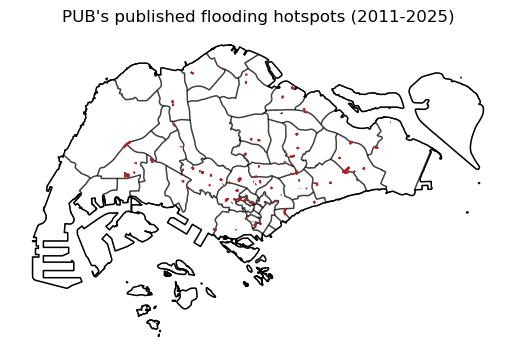

In [157]:
# flooding_hotspot = pd.read_csv(r"Data\flooding_hotspots.csv")
flooding_hotspot = pd.read_csv(r"Data\flooding_hotspots_2011_2025.csv")

flooding_hotspot
G_edges = ox.graph_to_gdfs(G_car, edges=True,nodes=False)
flooding_hotspot_edges = ox.nearest_edges(G_car,flooding_hotspot['longitude'],flooding_hotspot['latitude'])
print("length of edges: ", len(flooding_hotspot_edges))
flooding_hotspot_edges = G_edges.loc[flooding_hotspot_edges]
print("length of edges: ", len(flooding_hotspot_edges))
# flooding_hotspot['geometry'] = flooding_hotspot_edges['geometry'].to_list()
flooding_hotspot = gpd.GeoDataFrame(data=flooding_hotspot,geometry=flooding_hotspot_edges['geometry'].to_list(),crs=planningArea_shp.crs)
ax = gpd.GeoSeries(planningArea_shp.union_all()).plot(fc="none",ec="k")
planningArea_shp.plot(ax=ax, fc="None", ec="k",alpha=0.5)
flooding_hotspot.plot(ax=ax,ec="firebrick")
ax.set_title("PUB's published flooding hotspots (2011-2025)")
ax.axis('off')
plt.savefig(r"Exported_Data\exported_figures\PUB_compiled_flooding_hotspot_2011_2025_1.svg",bbox_inches='tight')
# flooding_hotspot.to_file(r"Data\flooding_hotspots_2011_2024.shp",driver="ESRI Shapefile")

# Import DEM
- FABDEM (30m spatial resolution)

To check if higher elevation has lower flood risk, and also fetches higher property prices

In [6]:
SG_DEM = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\FABDEM_SG_30m\FABDEM_SG_30m_Clipped.tif"
SG_DEM_raster = gdal.Open(SG_DEM)
print("Projection is {}".format(SG_DEM_raster.GetProjection()))
# get geotransform
geotransform_SG_DEM_raster = SG_DEM_raster.GetGeoTransform()

band = SG_DEM_raster.GetRasterBand(1)
print("Band Type={}".format(gdal.GetDataTypeName(band.DataType)))

min_ = band.GetMinimum()
max_ = band.GetMaximum()
if not min_ or not max_:
    (min_,max_) = band.ComputeRasterMinMax(True)
print("Min={:.3f}, Max={:.3f}".format(min_,max_))

# read as array
SG_DEM_raster_arr = np.array(SG_DEM_raster.GetRasterBand(1).ReadAsArray())

def get_coords(dx,dy, geotransform):
    """" get coordinate with any array index
    Args:
        dx (int): column pixel from the origin (upper left corner)
        dy (int): row pixel from the origin (upper left corner)
    """
    # origin
    px = geotransform[0]
    py = geotransform[3]
    # pixel size
    rx = geotransform[1]
    ry = geotransform[5]
    x = dx*rx + px
    y = dy*ry + py
    return y,x

def get_DEM_value(lon,lat,geotransform):
    """
    Returns:
        dx (int): column pixel from the origin (upper left corner)
        dy (int): row pixel from the origin (upper left corner)
    """
    # origin
    px = geotransform[0]
    py = geotransform[3]
    # pixel size
    rx = geotransform[1]
    ry = geotransform[5]
    dx = (lon -px)/rx
    dy = (lat - py)/ry
    return round(dx), round(dy)

# bukit timah elevation validation (163.63m)
dx, dy = get_DEM_value(103.7763750,1.3546806,geotransform_SG_DEM_raster)
SG_DEM_raster_arr[dy, dx]

Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Band Type=Float32
Min=-37.000, Max=180.180


c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


np.float32(167.37)

In [118]:
# add DEM as a column
residential_transaction_df[["LATITUDE","LONGITUDE"]].apply(lambda x: DEM.get_DEM_value(x["LONGITUDE"],x["LATITUDE"]),axis=1)#.isna().any()

0         10.650000
1         26.629999
2         19.180000
3         21.820000
4         29.610001
            ...    
267941     6.690000
267942    18.590000
267943     6.180000
267944    18.250000
267945    10.820000
Length: 267452, dtype: float32

### Areas prone to flooding under 3m high-tide levels

Text(0.5, 1.0, 'Areas prone to flooding under 3 m high tide')

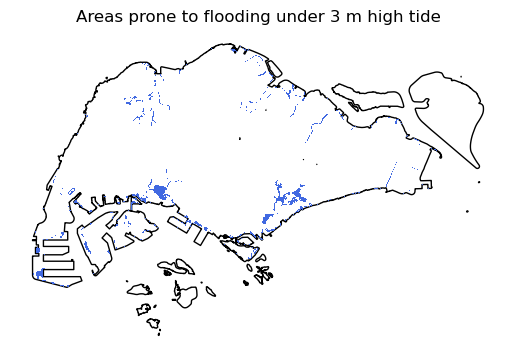

In [14]:
tide_3m = gpd.read_file(r"Data\water_depth_3m.shp")
ax = gpd.GeoDataFrame(geometry=gpd.GeoSeries(planningArea_shp.union_all())).plot(fc="none",ec="k")
gpd.GeoDataFrame(geometry=gpd.GeoSeries(tide_3m.union_all())).plot(ax=ax,fc="royalblue")
ax.axis('off')
ax.set_title("Areas prone to flooding under 3 m high tide")
# plt.savefig(os.path.join(r"Exported_Data\exported_figures","3m_high_tide.svg"),bbox_inches='tight')

In [28]:
tide_3m_polygon = tide_3m.union_all()
coastal_flood_prone = residential_transaction_df['geometry'].apply(lambda x: tide_3m_polygon.intersects(x))
residential_transaction_df["prone_to_high_tide"] = coastal_flood_prone
residential_transaction_df

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,POSTAL,X,Y,LATITUDE,LONGITUDE,year,month,geometry,SUBZONE_N,prone_to_high_tide
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,787056.0,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),YIO CHU KANG WEST,False
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,596230.0,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),HILLVIEW,False
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,573893.0,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),UPPER THOMSON,False
3,KINGSFORD . HILLVIEW PEAK,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New Sale,Strata,48.0,15208,...,667982.0,20304.463939,38537.214606,1.364790,103.764169,2014,1,POINT (103.76417 1.36479),HILLVIEW,False
4,MEADOWS @ PEIRCE,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,787131.0,27381.798079,40248.119710,1.380264,103.827764,2014,1,POINT (103.82776 1.38026),TAGORE,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267941,THE TRE VER,2300000,1097.93,2095,2025-06-18,66 POTONG PASIR AVENUE 1 #13-30,Sub Sale,Strata,102.0,22549,...,358394.0,31436.687533,35557.251883,1.337841,103.864199,2025,6,POINT (103.8642 1.33784),POTONG PASIR,False
267942,TWIN FOUNTAINS,1600000,1205.57,1327,2025-06-18,19 WOODLANDS AVENUE 6 #05-26,Resale,Strata,112.0,14286,...,738999.0,24248.043549,45896.792457,1.431349,103.799604,2025,6,POINT (103.7996 1.43135),WOODLANDS SOUTH,False
267943,BARTLEY RIDGE,890000,559.73,1590,2025-06-19,46 MOUNT VERNON ROAD #01-47,Resale,Strata,52.0,17115,...,368063.0,33357.349916,35916.628376,1.341091,103.881458,2025,6,POINT (103.88146 1.34109),JOO SENG,False
267944,THE WOODLEIGH RESIDENCES,1865000,742.72,2511,2025-06-20,21 BIDADARI PARK DRIVE #10-26,Sub Sale,Strata,69.0,27029,...,367795.0,32238.669180,35625.737646,1.338461,103.871406,2025,6,POINT (103.87141 1.33846),BIDADARI,False


In [21]:
tide_3m_union = gpd.GeoDataFrame(geometry=gpd.GeoSeries(tide_3m.union_all()),crs=planningArea_shp.crs)
residential_transaction_df.sjoin(tide_3m_union,predicate="intersects")

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,POSTAL,X,Y,LATITUDE,LONGITUDE,year,month,geometry,SUBZONE_N,index_right
44785,CORALS AT KEPPEL BAY,6520000,2658.71,2452,2017-03-09,3 KEPPEL BAY DRIVE #03-07,New Sale,Strata,247.0,26397,...,98013.0,26107.064154,27447.181010,1.264497,103.816310,2017,3,POINT (103.81631 1.2645),MARITIME SQUARE,0
54033,CORALS AT KEPPEL BAY,7600000,2658.71,2859,2019-04-24,3 KEPPEL BAY DRIVE #02-07,Resale,Strata,247.0,30769,...,98013.0,26107.064154,27447.181010,1.264497,103.816310,2019,4,POINT (103.81631 1.2645),MARITIME SQUARE,0
59849,CORALS AT KEPPEL BAY,6900000,2658.71,2595,2020-11-25,3 KEPPEL BAY DRIVE #04-07,Resale,Strata,247.0,27935,...,98013.0,26107.064154,27447.181010,1.264497,103.816310,2020,11,POINT (103.81631 1.2645),MARITIME SQUARE,0
60789,THE REEF AT KING'S DOCK,3439270,1216.33,2828,2021-01-29,20 HARBOURFRONT AVENUE #04-48,New Sale,Strata,113.0,30436,...,98000.0,26187.067308,27406.533741,1.264129,103.817029,2021,1,POINT (103.81703 1.26413),MARITIME SQUARE,0
60790,THE REEF AT KING'S DOCK,1120757,484.38,2314,2021-01-29,20 HARBOURFRONT AVENUE #03-52,New Sale,Strata,45.0,24906,...,98000.0,26187.067308,27406.533741,1.264129,103.817029,2021,1,POINT (103.81703 1.26413),MARITIME SQUARE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232389,THE RESIDENCES AT W SINGAPORE SENTOSA COVE,5050800,2572.60,1963,2025-02-14,5 OCEAN WAY #06-21,Resale,Strata,239.0,21133,...,98369.0,29033.675772,25598.523951,1.247778,103.842606,2025,2,POINT (103.84261 1.24778),SENTOSA,0
232418,THE RESIDENCES AT W SINGAPORE SENTOSA COVE,2966700,1657.66,1790,2025-02-27,5 OCEAN WAY #03-18,Resale,Strata,154.0,19264,...,98369.0,29033.675772,25598.523951,1.247778,103.842606,2025,2,POINT (103.84261 1.24778),SENTOSA,0
232587,CAPE ROYALE,5656000,2508.01,2255,2025-04-04,15 COVE WAY #16-05,Resale,Strata,233.0,24275,...,98204.0,28697.490397,24943.664500,1.241856,103.839586,2025,4,POINT (103.83959 1.24186),SENTOSA,0
232717,THE RESIDENCES AT W SINGAPORE SENTOSA COVE,3042000,1657.66,1835,2025-05-14,5 OCEAN WAY #04-17,Resale,Strata,154.0,19753,...,98369.0,29033.675772,25598.523951,1.247778,103.842606,2025,5,POINT (103.84261 1.24778),SENTOSA,0


# Import drainage works on roads
- with a buffer of 200 m around roads

['Development of Kallang River' 'Road Raising and Drainage Works'
 'Drainage Work' 'Improvement to Roadside Drains In EUP' 'Road Raising'
 'Improvement' 'Improvement to Culvert' 'Improvement to Outlet Drain'
 'Service Road' 'Construction' 'Improvement to Roadside Drains'
 'Improvement to Roadside Drains and Watermain Replacement'
 'Proposed Drainage Scheme' 'ABC Waters Project']
S/N              int64
Location        object
Date            object
Status          object
year             int64
month            int64
work_types      object
location_1      object
locations       object
SEARCHVAL       object
BLK_NO          object
ROAD_NAME       object
BUILDING        object
ADDRESS         object
POSTAL          object
X              float64
Y              float64
LATITUDE       float64
LONGITUDE      float64
number_of_     float64
work_categ      object
u                int64
v                int64
key              int64
geometry      geometry
dtype: object
596


,S/N,Location,Date,Status,year,month,work_types,location_1,locations,SEARCHVAL,...,X,Y,LATITUDE,LONGITUDE,number_of_,work_categ,u,v,key,geometry
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River,4684558080,5643502198,0,"POLYGON ((103.83566 1.36457, 103.83563 1.36458..."
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works,408735646,2641677416,0,"POLYGON ((103.84634 1.32943, 103.84654 1.32967..."
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works,2168300378,6754998201,0,"POLYGON ((103.83165 1.31215, 103.83161 1.31211..."
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works,1268263183,1268264187,0,"POLYGON ((103.94684 1.32824, 103.94673 1.32837..."
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works,243486752,3030270542,0,"POLYGON ((103.95411 1.32159, 103.95398 1.3215,..."


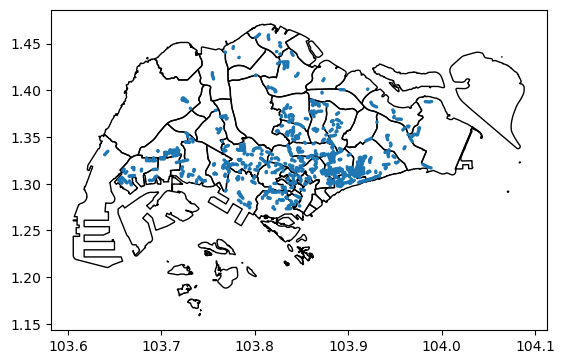

In [193]:
completed_drainage_works = gpd.read_file(r"Exported_Data\drainage_works_buffer200m.shp")
ax = planningArea_shp.plot(fc='none',ec='k')
completed_drainage_works.plot(ax=ax)
print(completed_drainage_works["work_categ"].unique())
completed_drainage_works = completed_drainage_works.rename(columns={"Year":"year","Month":"month"})
print(completed_drainage_works.dtypes)
print(len(completed_drainage_works))
# work_categ has no NAs but ROAD_NAME column has NAs
completed_drainage_works.head()

# Merge drainage works with residential transaction

In [288]:
residential_drainage = residential_transaction_df.sjoin(completed_drainage_works[["work_categ","year","month","ROAD_NAME","geometry"]],how="left",
                                                        rsuffix="drainage",lsuffix="property",on_attribute=["year","month"])
residential_drainage = residential_drainage.sort_values(by=["Sale_Date","year","month"])
print(len(residential_drainage))
# remove duplicated index
residential_drainage = residential_drainage[~residential_drainage.index.duplicated(keep="first")]
print(len(residential_drainage))
print(f"Number of NAs in work_categ: {residential_drainage["work_categ"].isna().sum()}")
print(f"Number of NAs in ROAD_NAME_drainage: {residential_drainage["ROAD_NAME_drainage"].isna().sum()}")
residential_drainage = residential_drainage.drop(columns=['index_drainage'])
residential_drainage

267554
267452
Number of NAs in work_categ: 266878
Number of NAs in ROAD_NAME_drainage: 267057


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,POSTAL,X,Y,LATITUDE,LONGITUDE,year,month,geometry,work_categ,ROAD_NAME_drainage
111375,THE WATERSIDE,2000000,2142.04,934,2014-01-01,11 TANJONG RHU ROAD #18-02,Resale,Strata,199.0,10050,...,436896.0,33503.361368,31008.607863,1.296705,103.882769,2014,1,POINT (103.88277 1.2967),NaN,NaN
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,787056.0,28883.630900,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),NaN,NaN
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,596230.0,20479.219140,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),NaN,NaN
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,573893.0,27661.184826,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),NaN,NaN
20475,BLUE HORIZON,1330000,1216.33,1093,2014-01-02,27 WEST COAST CRESCENT #24-23,Resale,Strata,113.0,11770,...,128048.0,20373.536810,31096.807133,1.297502,103.764791,2014,1,POINT (103.76479 1.2975),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153145,GRAND DUNMAN,3284000,1291.68,2542,2025-06-21,6 DUNMAN ROAD #01-17,New Sale,Strata,120.0,27367,...,439395.0,34382.377061,32298.376712,1.308369,103.890667,2025,6,POINT (103.89067 1.30837),NaN,NaN
80885,PINETREE HILL,3214000,1216.33,2642,2025-06-22,32 PINE GROVE #22-09,New Sale,Strata,113.0,28442,...,598442.0,21613.042222,33614.295829,1.320270,103.775928,2025,6,POINT (103.77593 1.32027),NaN,NaN
80886,NAVA GROVE,2903700,1108.69,2619,2025-06-22,40 PINE GROVE #24-10,New Sale,Strata,103.0,28191,...,597775.0,21521.152286,33552.534129,1.319711,103.775103,2025,6,POINT (103.7751 1.31971),NaN,NaN
168511,HILL HOUSE,1400000,430.56,3252,2025-06-22,11 INSTITUTION HILL #09-08,New Sale,Strata,40.0,35000,...,239666.0,28700.262278,30852.885352,1.295297,103.839611,2025,6,POINT (103.83961 1.2953),NaN,NaN


In [287]:
# add drainage related columns
# drainage_work_nearby (is this property located in the area served by a drainage improvement)
def add_drainage_work_nearby(df):
    """                                 
    is this property located in the area served by a drainage improvement
    """
    df_copy = copy.deepcopy(df)
    df_copy["drainage_work_nearby"] = df["work_categ"].notna()
    return df_copy

def add_drainage_completion_date(df):
    """                              
    (NA if no drainage work applies)
    """
    df_copy = copy.deepcopy(df)
    df_copy["drainage_completion_date"] = pd.Series("Never treated",index=df_copy.index).mask(df["work_categ"].notna(),"Completed")
    return df_copy

def get_drainage_period(df_subset, construction_period=6):
    """ 
    Args:
        df_subset (pd.DataFrame) refers to the specific project name that have/will undergo(ne) a specific drainage work
        e.g. residential_drainage[residential_drainage["Project Name"] == "ASCENTIA SKY]
        construction_period (float): number of months that the drainage work will last for
    Returns:
        pd.Series
    """
    # make sure the df_subset is sorted by date
    df_subset = df_subset.sort_values(by="Sale_Date")
    # identify rows which coincides with drainage works
    drainage_entries = df_subset["work_categ"].notna()
    if drainage_entries.sum() > 0:
        # create drainage period series
        drainage_period = pd.Series(np.nan,index=df_subset.index,dtype="string")
        drainage_period.loc[drainage_entries] = "construction"
        # shift drainage completion down by one to indicate after completion
        after_completion = drainage_period.shift(1)
        drainage_period.loc[after_completion=="construction"] = "after"
        # get drainage_date 
        # cannot use this because it will also pick up dates that are not drainage completion dates
        # drainage_date = pd.to_datetime(df_subset["year"].astype(str) + '-' + df_subset["month"].astype(str).str.zfill(2)+ '-28')
        # to get drainage completion date from ROAD_NAME_drainage, rest is na
        drainage_completion = pd.Series(np.nan,index=df_subset.index,dtype='datetime64[ns]')
        drainage_completion_date = df_subset.loc[drainage_entries,["year","month"]]
        drainage_completion.loc[drainage_entries] = pd.to_datetime(drainage_completion_date["year"].astype(str) + '-' + drainage_completion_date["month"].astype(str).str.zfill(2)+ '-28')
        
        # backward fill drainage completion date so that NAs are filled with drainage completion date
        drainage_completion = drainage_completion.bfill()
        # get drainage construction date e.g. 6 months before completion date
        drainage_construction_start = drainage_completion - pd.DateOffset(months=construction_period)
        # get the first drainage construction start date
        first_construction_date = drainage_construction_start.values[0]

        # identify rows before construction start date
        drainage_period.loc[df_subset["Sale_Date"] < first_construction_date] = "before" 
        # assign as construction if sale date is between drainage completion and construction start
        drainage_period.loc[(df_subset["Sale_Date"]>=drainage_construction_start) & (df_subset["Sale_Date"]<drainage_completion)] = "construction"
        # assign as after if sale date is after drainage completion
        # forward fill NA with after
        drainage_period = drainage_period.ffill()
        return drainage_period
    
    else:
        # if work categ rows are all NAs, it means no drainage work has been implemented (untreated), input "never"
        return pd.Series("never",index=df_subset.index)
    
def get_work_categ(df_subset):
    """ 
    Args:
        df_subset (pd.DataFrame) refers to the specific project name that have/will undergo(ne) a specific drainage work
        e.g. residential_drainage[residential_drainage["Project Name"] == "ASCENTIA SKY]
        df after applying get_drainage_period
    Returns:
        pd.Series
    """
    # identify rows which coincides with drainage works
    drainage_entries = df_subset["work_categ"].notna()
    if drainage_entries.sum() > 0:
        # make sure the df_subset is sorted by date
        df_subset = df_subset.sort_values(by="Sale_Date")
        work_categ = df_subset['work_categ'].bfill()
        # create mask for rows with "after"
        mask = (df_subset["drainage_period"]=="after")|(df_subset["drainage_period"]=="before")
        work_categ.loc[mask] = np.nan
        work_categ = work_categ.ffill().fillna(value="none") # so as to fill the rows that are "after", and fill "before" rows with "none"
        return work_categ
    else:
        return pd.Series("none",index=df_subset.index)


def add_drainage_period(df,construction_period=6):
    """                             
    assign before, construction, after, never based on transaction_date and drainage work_date
    """
    df_copy = copy.deepcopy(df)
    df_copy["drainage_period"] = pd.Series(np.nan,index=df_copy.index,dtype="string")
    # get drainage period for each project name with at least one drainage work
    drainage_period = df_copy.groupby(["Project Name"]).apply(lambda x: get_drainage_period(x,construction_period=construction_period)).reset_index(level=[0],name="drainage_period")
    df_copy.loc[drainage_period.index,"drainage_period"] = drainage_period["drainage_period"]
    # get work_categ for each project name with at least one drainage work
    work_categ = df_copy.groupby(["Project Name"]).apply(lambda x: get_work_categ(x)).reset_index(level=[0],name="work_categ")
    df_copy.loc[work_categ.index,"work_categ"] = work_categ["work_categ"]
    
    return df_copy

# add_drainage_work_nearby(residential_drainage)
# x = add_drainage_completion_date(residential_drainage)
df_test = add_drainage_period(residential_drainage)
# get_drainage_period(df_test, construction_period=6)
# df_test["drainage_period"] = get_drainage_period(df_test, construction_period=6)
df_test

C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\2038850932.py:98: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  drainage_period = df_copy.groupby(["Project Name"]).apply(lambda x: get_drainage_period(x,construction_period=construction_period)).reset_index(level=[0],name="drainage_period")
C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\2038850932.py:101: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  work_

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,Y,LATITUDE,LONGITUDE,year,month,geometry,index_drainage,work_categ,ROAD_NAME_drainage,drainage_period
111375,THE WATERSIDE,2000000,2142.04,934,2014-01-01,11 TANJONG RHU ROAD #18-02,Resale,Strata,199.0,10050,...,31008.607863,1.296705,103.882769,2014,1,POINT (103.88277 1.2967),NaN,none,NaN,never
0,CASTLE GREEN,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,40954.900104,1.386656,103.841259,2014,1,POINT (103.84126 1.38666),NaN,none,NaN,never
1,SUMMERHILL,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,37907.302875,1.359094,103.765739,2014,1,POINT (103.76574 1.35909),NaN,none,NaN,never
2,THOMSON THREE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New Sale,Strata,68.0,15456,...,37765.008907,1.357808,103.830274,2014,1,POINT (103.83027 1.35781),NaN,none,NaN,never
20475,BLUE HORIZON,1330000,1216.33,1093,2014-01-02,27 WEST COAST CRESCENT #24-23,Resale,Strata,113.0,11770,...,31096.807133,1.297502,103.764791,2014,1,POINT (103.76479 1.2975),NaN,none,NaN,never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153145,GRAND DUNMAN,3284000,1291.68,2542,2025-06-21,6 DUNMAN ROAD #01-17,New Sale,Strata,120.0,27367,...,32298.376712,1.308369,103.890667,2025,6,POINT (103.89067 1.30837),NaN,none,NaN,never
80885,PINETREE HILL,3214000,1216.33,2642,2025-06-22,32 PINE GROVE #22-09,New Sale,Strata,113.0,28442,...,33614.295829,1.320270,103.775928,2025,6,POINT (103.77593 1.32027),NaN,none,NaN,never
80886,NAVA GROVE,2903700,1108.69,2619,2025-06-22,40 PINE GROVE #24-10,New Sale,Strata,103.0,28191,...,33552.534129,1.319711,103.775103,2025,6,POINT (103.7751 1.31971),NaN,none,NaN,never
168511,HILL HOUSE,1400000,430.56,3252,2025-06-22,11 INSTITUTION HILL #09-08,New Sale,Strata,40.0,35000,...,30852.885352,1.295297,103.839611,2025,6,POINT (103.83961 1.2953),NaN,none,NaN,never


### Validation
- to check if drainage type and construction period corresponds with the start and completion date
- handling of multiple drainage types for the same project name

In [282]:
x = df_test[df_test["Project Name"]=="6 DERBYSHIRE"][["Sale_Date","work_categ","drainage_period"]].iloc[20:40,:]
residential_drainage[residential_drainage["Project Name"]=="# 1 LOFT"][["Project Name","work_categ"]].sort_index().head()
residential_drainage[["Project Name","work_categ"]].dropna().drop_duplicates().sort_values(by="Project Name")
x = residential_drainage[residential_drainage["Project Name"]=="6 DERBYSHIRE"][["Sale_Date","work_categ"]].sort_values(by="Sale_Date")
x[x["work_categ"].notna()]
x = residential_drainage.groupby(["Project Name"]).apply(lambda x: get_drainage_period(x)).reset_index(level=[0],name="drainage_period")
# residential_drainage.loc[x.index,:]
x[x["Project Name"]=="COTE D'AZUR"]
x = residential_drainage.groupby(["Project Name"])["work_categ"].apply(lambda x:x.bfill().ffill()).reset_index(level=[0])
df_test.loc[x.index,"work_categ"] = x["work_categ"]
df_test[df_test["Project Name"]=='# 1 LOFT']
def add_drainage_period():
    x = pd.Series(np.nan,index=residential_drainage.index[:10])
    t = pd.Series(np.nan,index=residential_drainage.index[:10])
    drainage_type = pd.Series(np.nan,index=residential_drainage.index[:10],dtype="string")
    t.iloc[[3,7]] = ["2012-05-07","2015-07-05"]
    drainage_type.iloc[[3,7]] = ["road raising", "drainage improvement"]
    t1 = pd.to_datetime(pd.Series(["2012-02-07","2012-03-07","2012-04-07","2012-05-07","2012-06-07",
                                "2015-05-05","2015-06-05","2015-07-05","2015-08-05","2015-09-05"],index=residential_drainage.index[:10]))
    t = pd.to_datetime(t)
    x.iloc[[3,7]] = "construction"
    # print(x)
    # x.ffill().bfill()
    df = pd.DataFrame({'sale_date':t1,'drainage_period':x,'drainage_date':t,'drainage_type':drainage_type})
    # where df represents a specific project name and the construction works
    # shift drainage_period down by one
    after = df['drainage_period'].shift(1)
    df.loc[after=="construction",'drainage_period'] = "after"
    # drainage completion date
    drainage_completion = df["drainage_date"].bfill()
    # drainage_construction_start
    drainage_construction_start = drainage_completion - pd.DateOffset(months=1)
    # get the first drainage construction start date
    first_construction_date = drainage_construction_start.values[0]
    df.loc[df["sale_date"] < first_construction_date,"drainage_period"] = "before"
    # assign as construction if sale date is between drainage completion and construction start
    df.loc[(df["sale_date"]>=drainage_construction_start) & (df["sale_date"]<drainage_completion) ,"drainage_period"] = "construction"
    # assign as after if sale date is after drainage completion
    # forward fill NA with after
    df['drainage_period'] = df['drainage_period'].ffill()
    # update work category
    df['work_categ'] = df['drainage_type'].bfill()
    # create mask for rows with "after"
    mask = (df["drainage_period"]=="after")|(df["drainage_period"]=="before")
    df.loc[mask,"work_categ"] = np.nan
    df["work_categ"] = df["work_categ"].ffill()
    return df
add_drainage_period()

def test(construction_period=6):
    x = residential_drainage.copy()#[~residential_drainage["work_categ"].isna()]
    x = {k: df for k, df in x.groupby(["work_categ","Project Name"])}
    print(list(x))
    y = x[('Drainage Work', '# 1 LOFT')]
    z = residential_drainage[residential_drainage["Project Name"] == list(x)[0][1]]
    drainage_completion = pd.Series(np.nan,index=z.index,dtype='datetime64[ns]')
    drainage_entries = z["work_categ"].notna()
    drainage_completion_date = z.loc[drainage_entries,["year","month"]]
    drainage_completion.loc[drainage_entries] = pd.to_datetime(drainage_completion_date["year"].astype(str) + '-' + drainage_completion_date["month"].astype(str).str.zfill(2)+ '-28')
    drainage_construction_start = drainage_completion - pd.DateOffset(months=construction_period)
    return drainage_construction_start[drainage_construction_start.notna()]

test()

C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\1301724109.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['2012-05-07', '2015-07-05']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  t.iloc[[3,7]] = ["2012-05-07","2015-07-05"]
C:\Users\hypak\AppData\Local\Temp\ipykernel_1220\1301724109.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'construction' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  x.iloc[[3,7]] = "construction"


,sale_date,drainage_period,drainage_date,drainage_type,work_categ
111375,2012-02-07,before,NaT,<NA>,<NA>
0,2012-03-07,before,NaT,<NA>,<NA>
1,2012-04-07,construction,NaT,<NA>,road raising
2,2012-05-07,construction,2012-05-07,road raising,road raising
20475,2012-06-07,after,NaT,<NA>,road raising
36378,2015-05-05,after,NaT,<NA>,road raising
36379,2015-06-05,construction,NaT,<NA>,drainage improvement
36380,2015-07-05,construction,2015-07-05,drainage improvement,drainage improvement
36381,2015-08-05,after,NaT,<NA>,drainage improvement
36382,2015-09-05,after,NaT,<NA>,drainage improvement


# Analysis

In [175]:
drainage_works_df = Data.get_drainage_works_df(Data.DRAINAGE_WORKS_FP)
print(drainage_works_df.columns)
drainage_works_df

Index(['S/N', 'Location', 'Drainage_Date', 'Status', 'year', 'month',
       'work_types', 'location', 'locations', 'SEARCHVAL', 'BLK_NO',
       'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE',
       'LONGITUDE', 'number_of_searches', 'work_categories'],
      dtype='object')


,S/N,Location,Drainage_Date,Status,year,month,work_types,location,locations,SEARCHVAL,...,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,436,ABC Waters Project @ Jurong Canal,1/10/2023,Completed,2023,10,ABC Waters Project,Jurong Canal,Jurong Canal,JURONG CANAL DRIVE,...,JURONG CANAL DRIVE,NIL,JURONG CANAL DRIVE,NIL,16303.58721,37042.24305,1.351269,103.728219,1.0,ABC Waters Project
592,437,Improvement to Roadside Drains and Watermain R...,1/12/2023,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Aljunied park,ALJUNIED PARK,...,NIL,ALJUNIED PARK,ALJUNIED PARK,NIL,33185.87141,34630.63258,1.329461,103.879916,1.0,Improvement to Roadside Drains and Watermain R...
593,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,...,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.64591,31481.20325,1.300979,103.842274,1.0,Road Raising
594,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,...,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.50445,32268.65509,1.308094,103.842139,1.0,Road Raising


### Road raising + buffer

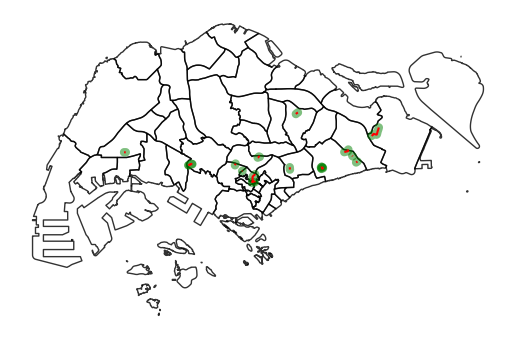

In [217]:
# overlay roads + buffer
ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.8)
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=None)
road_raising_works_buffer_df.plot(ax=ax,color="red")
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=500)
road_raising_works_buffer_df.plot(ax=ax,color="green",alpha=0.5)

ax.axis('off')
plt.savefig(os.path.join(r"Exported_Data\exported_figures\RoadRaising",f"RoadRaising_buffer500m_SG.svg"),
            bbox_inches = "tight")
plt.show()

### Road raising + downstream road network + buffer

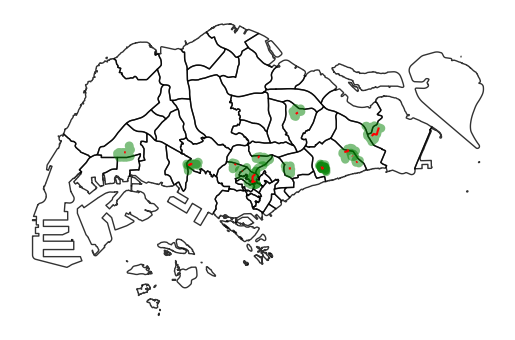

In [219]:
road_raising_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=None)
road_raising_works_buffer_df = Data.get_road_raising_network_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                                            reverse = False, 
                                                                            depth_limit = 5,
                                                                            buffer_dist=500)

# overlay roads with downstream + buffer
ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.8)
# fig, ax = plt.subplots(1,1)
road_raising_works_buffer_df.plot(ax=ax,color="green",alpha=0.5)
road_raising_df.plot(ax=ax,color="red")
ax.axis('off')
plt.savefig(os.path.join(r"Exported_Data\exported_figures\RoadRaising",
                         "downstreamRoadRaising_depth5_buffer500m_SG.svg"),
            bbox_inches = "tight")

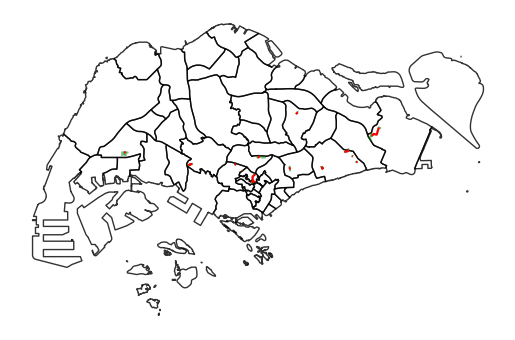

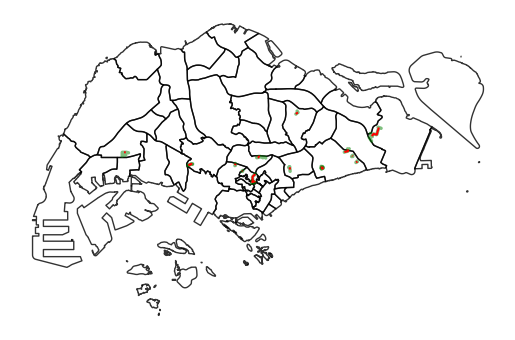

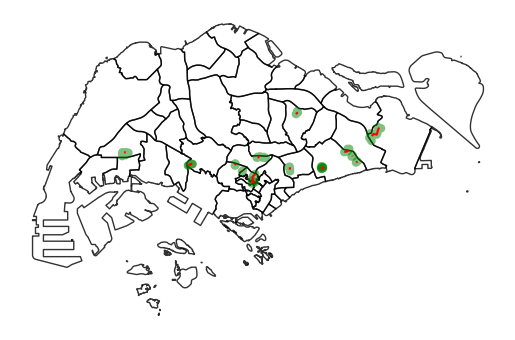

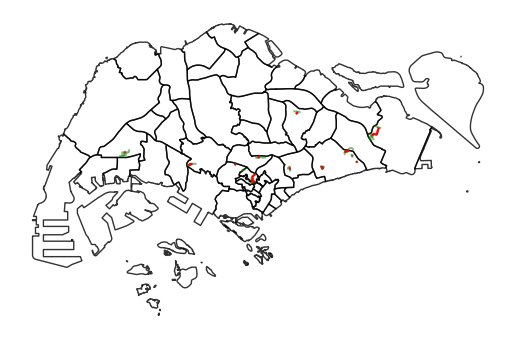

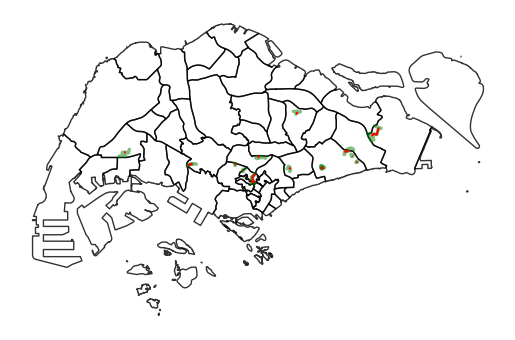

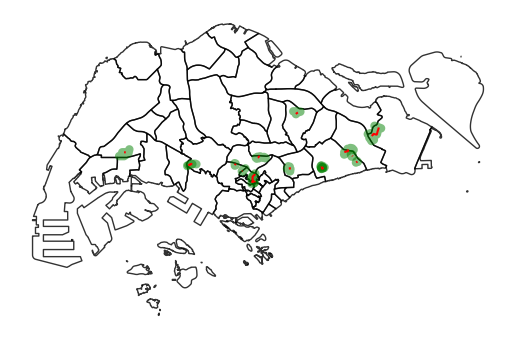

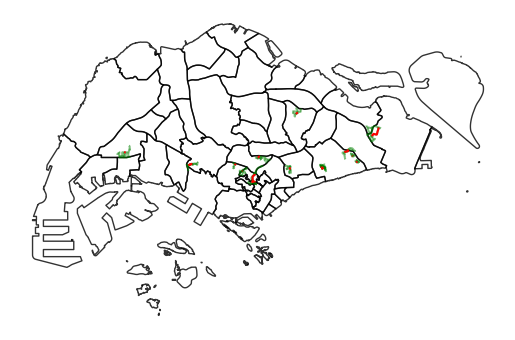

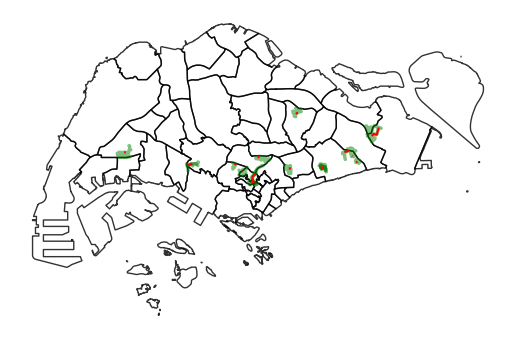

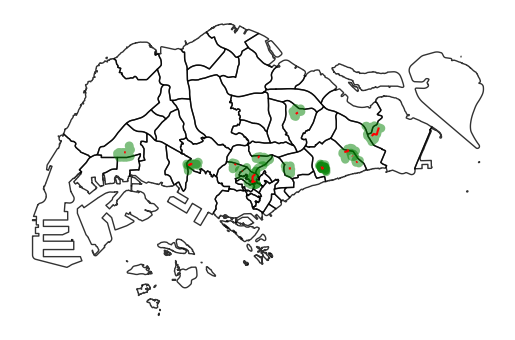

In [ ]:
for depth_limit in [1,2,5]:
    for buffer_dist in [None, 200, 500]:
        road_raising_works_buffer_df = Data.get_road_raising_network_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                                            reverse = False, 
                                                                            depth_limit = depth_limit,
                                                                            buffer_dist=buffer_dist)

        # overlay roads with downstream + buffer
        ax = planningArea_shp.plot(fc="None",ec="k",alpha=0.8)
        # fig, ax = plt.subplots(1,1)
        road_raising_works_buffer_df.plot(ax=ax,color="green",alpha=0.5)
        road_raising_df.plot(ax=ax,color="red")
        ax.axis('off')
        plt.savefig(os.path.join(r"Exported_Data\exported_figures\RoadRaising",f"downstreamRoadRaising_depth{depth_limit}_buffer{buffer_dist}m_SG.svg"))
        plt.show()
        # road_raising_works_buffer_df.head()

In [ ]:
# includes both drainage works on roadside and outlet drains + culvert improvement works
Data.get_drain_improvement_buffer_df(G_car, Data.DRAINAGE_WORKS_FP, buffer_dist=400)

c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:169: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drains_df['work_categories'] = "Improvement to Roadside/Outlet Drains"
c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  culvert_df['work_categories'] = "

,S/N,Location,Drainage_Date,Status,year,month,work_types,location,locations,SEARCHVAL,...,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,u,v,key,geometry
0,10,Improvement to Roadside Drains In Estate Upgra...,1/11/2012,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Jalan Bunga Rampai,Jalan Bunga Rampai,JALAN BUNGA RAMPAI,...,33568.17623,35757.66191,1.339652,103.883349,1.0,Improvement to Roadside/Outlet Drains,378628547,245566400,0,"POLYGON ((103.88026 1.33601, 103.88004 1.33621..."
1,11,Improvement to Roadside Drains In Estate Upgra...,1/11/2012,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Phoenix,Phoenix,"Phoenix, 40, Choa Chu Kang Road, Teck Whye, Ch...",...,NaN,NaN,1.378616,103.758008,2.0,Improvement to Roadside/Outlet Drains,2145148899,2145148900,0,"POLYGON ((103.7572 1.38194, 103.75726 1.38196,..."
2,26,Improvement to Roadside Drains In Batch 5 of t...,1/5/2013,Completed,2013,5,Improvement to Roadside Drains In Batch 5 of t...,Gerald Drive,Gerald Drive,GERALD DRIVE,...,32912.49351,40725.09521,1.384580,103.877461,1.0,Improvement to Roadside/Outlet Drains,2392369426,1711536770,0,"POLYGON ((103.87484 1.38092, 103.87482 1.38093..."
3,110,Improvement to Roadside Drains In Batch 5 of t...,1/1/2014,Completed,2014,1,Improvement to Roadside Drains In Batch 5 of t...,Charlton Park,Charlton Park,CHARLTON PARK,...,33994.84181,37544.11698,1.355810,103.887186,10.0,Improvement to Roadside/Outlet Drains,1366728322,1366728360,0,"POLYGON ((103.88452 1.35811, 103.88458 1.35825..."
4,111,Improvement to Roadside Drains In Batch 5 of t...,1/1/2014,Completed,2014,1,Improvement to Roadside Drains In Batch 5 of t...,Sembawang Springs,Sembawang Springs,SEMBAWANG SPRINGS ESTATE,...,27312.64524,46684.80334,1.438475,103.827142,10.0,Improvement to Roadside/Outlet Drains,1436113713,1436113594,0,"POLYGON ((103.829 1.43558, 103.82877 1.43545, ..."
5,112,Improvement to Roadside Drains In Batch 5 of t...,1/1/2014,Completed,2014,1,Improvement to Roadside Drains In Batch 5 of t...,Kebun Bahru Villas,Kebun Bahru Villas,"Kebun Bahru, Ang Mo Kio, Singapore, North-East...",...,NaN,NaN,1.373450,103.839610,1.0,Improvement to Roadside/Outlet Drains,308944345,308940893,0,"POLYGON ((103.83875 1.3694, 103.83854 1.36938,..."
6,114,Improvement to Outlet Drain at Sin Ming Rd,1/1/2014,Completed,2014,1,Improvement to Outlet Drain,Sin Ming Rd,Sin Ming Rd,SIN MING ROAD,...,28491.70585,37546.36853,1.355832,103.837739,2.0,Improvement to Roadside/Outlet Drains,243415165,1843181719,0,"POLYGON ((103.83504 1.35827, 103.83508 1.35832..."
7,181,Improvement to Roadside Drains In Batch 6 of t...,1/11/2014,Completed,2014,11,Improvement to Roadside Drains In Batch 6 of t...,Windsor Park,Windsor Park,WINDSOR NATURE PARK,...,26632.16670,37694.02803,1.357166,103.821028,10.0,Improvement to Roadside/Outlet Drains,1318498273,3784797715,0,"POLYGON ((103.82207 1.35273, 103.82207 1.35273..."
8,187,Improvement to Roadside Drains In Batch 6 of t...,1/12/2014,Completed,2014,12,Improvement to Roadside Drains In Batch 6 of t...,Thomson Ridge,Thomson Ridge,THOMSON RIDGE,...,28170.66836,37166.05657,1.352391,103.834852,10.0,Improvement to Roadside/Outlet Drains,3987285531,4735281548,0,"POLYGON ((103.83239 1.34969, 103.8322 1.34977,..."
9,198,Improvement to Roadside Drains In Estate Upgra...,1/4/2015,Completed,2015,4,Improvement to Roadside Drains In Estate Upgra...,Jalan Mata Ayer,Jalan Mata Ayer,JALAN MATA AYER,...,26991.24977,45562.39434,1.428325,103.824254,1.0,Improvement to Roadside/Outlet Drains,2395975759,2395975757,0,"POLYGON ((103.82554 1.43194, 103.82577 1.43187..."


# Import ongoing drainage works

In [ ]:
drainage_works = pd.read_csv(r"Exported_Data\drainage_works_2012_2027.csv")
if drainage_works['Date'].str.contains("/").all():
# drainage_works['Date'] = drainage_works['Date'].apply(utils.format_date)
# drainage_works['work_categories'].unique()

True


In [ ]:
ongoing_drainage = pd.read_csv(r"Exported_Data\drainage_works_ongoing_2024-2027.csv")
def get_date_from_quarters(text):
    quart = int(text.split("Q")[0])*3
    year = text.split(" ")[-1].strip()
    return f"{year}-{str(quart).zfill(2)}-01"

def extract_road_names(text):
    
    pattern = r"^(.*?)\s*(?:\bat\b|[-–—@])\s*(.*)$"

    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        work_types = match.group(1).strip()
        location = match.group(2).strip()
    else:
        pattern = r"^(.*?)\s*\b(?:in|to|along|of|for)\s*(.*)$"

        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            work_types = match.group(1).strip()
            location = match.group(2).strip()
        else:
            work_types = None
            location = text
    
    return pd.Series({"work_types":work_types,"location":location},index=["work_types","location"])


# Find multiple roads and split them if applicable

def extract_multiple_road_names(text):

    # Remove extra whitespace
    text = text.strip()

    def split_separator(s):
        # Otherwise, split by common separators (/, &, to, ,)
        pattern = r'\s*(?:/|&|,|\bto\b)\s*'
        parts = re.split(pattern, s, flags=re.IGNORECASE)
        return [p.strip() for p in parts if p.strip()]
    
    # 1. Handle parentheses first — extract before and inside ()
    bracket_match = re.match(r'^(.*?)\s*\(([^)]+)\)\s*$', text)
    if bracket_match:
        before = bracket_match.group(1).strip()
        inside = bracket_match.group(2).strip()
        
        return [before] + split_separator(inside)

    return split_separator(text)

ongoing_drainage['Date'] = pd.to_datetime(ongoing_drainage['Date'].apply(get_date_from_quarters))
ongoing_drainage[["work_types","location"]] = ongoing_drainage["Location"].apply(lambda x: extract_road_names(x))
ongoing_drainage["locations"] = ongoing_drainage["location"].apply(lambda x: extract_multiple_road_names(x))
ongoing_drainage = ongoing_drainage.explode("locations")
ongoing_drainage.head()
# ongoing_drainage.to_csv(r"Exported_Data\drainage_works_2024_2027.csv",index=False)

,S/N,Location,Date,Status,work_types,location,locations
0,1,Improvement to Bukit Timah Canal (between Rifl...,2026-03-01,Ongoing,Improvement,Bukit Timah Canal (between Rifle Range Road to...,Bukit Timah Canal
0,1,Improvement to Bukit Timah Canal (between Rifl...,2026-03-01,Ongoing,Improvement,Bukit Timah Canal (between Rifle Range Road to...,between Rifle Range Road
0,1,Improvement to Bukit Timah Canal (between Rifl...,2026-03-01,Ongoing,Improvement,Bukit Timah Canal (between Rifle Range Road to...,Jalan Kampong Chantek
1,2,Improvement to PA Camp and Parbury Outlet Drains,2024-09-01,Ongoing,Improvement,PA Camp and Parbury Outlet Drains,PA Camp and Parbury Outlet Drains
2,3,Construction of Syed Alwi Detention Tank and A...,2024-12-01,Ongoing,Construction,Syed Alwi Detention Tank and Ancillary Facilities,Syed Alwi Detention Tank and Ancillary Facilities


In [ ]:
ongoing_drainage = pd.read_csv(r"Exported_Data\drainage_works_2024_2027.csv")
ongoing_drainage.tail()

headers = OneMapAPI.generate_OneMap_headers()
response = OneMapAPI.get_coordinates_from_location(ongoing_drainage["locations"].values[0],headers)
print(ongoing_drainage["locations"].values[0], response[0])
new_headers = list(response[0])
new_headers

def postal_to_coord(row,column_names,headers):
    try:
        searchVal = OneMapAPI.get_coordinates_from_location(row,headers)
        searchVal = searchVal[0]
    except:
        searchVal = {c:np.nan for c in column_names}
    return pd.Series(searchVal,index=list(searchVal))

ongoing_drainage_locations = ongoing_drainage["locations"].apply(lambda x: postal_to_coord(x,new_headers, headers))
ongoing_drainage_locations = pd.concat([ongoing_drainage,ongoing_drainage_locations],axis=1)
# ongoing_drainage_locations.to_csv(r"Exported_Data\drainage_works_2024_2027.csv",index=False)
ongoing_drainage = pd.read_csv(r"Exported_Data\drainage_works_2024_2027.csv")
completed_drainage = pd.read_csv(r"Exported_Data\drainage_works_roads_2012_2024.csv")
print(ongoing_drainage.columns)
print(completed_drainage.columns)
drainage_works = pd.concat([completed_drainage[ongoing_drainage.columns.to_list()],ongoing_drainage],keys=['completed','ongoing'], names=["status"],axis=0).reset_index()
# drainage_works.to_csv(r"Exported_Data\drainage_works_2012_2027.csv",index=False)

Bukit Timah Canal {'SEARCHVAL': 'BUKIT TIMAH SECOND DIVERSION CANAL', 'BLK_NO': '', 'ROAD_NAME': 'NIL', 'BUILDING': 'BUKIT TIMAH SECOND DIVERSION CANAL', 'ADDRESS': 'BUKIT TIMAH SECOND DIVERSION CANAL', 'POSTAL': 'NIL', 'X': '29161.511693378', 'Y': '34598.7758919615', 'LATITUDE': '1.32917353830157', 'LONGITUDE': '103.84375540553'}


,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE
0,BUKIT TIMAH SECOND DIVERSION CANAL,,NIL,BUKIT TIMAH SECOND DIVERSION CANAL,BUKIT TIMAH SECOND DIVERSION CANAL,NIL,29161.511693378,34598.7758919615,1.32917353830157,103.84375540553
1,RIFLE RANGE ROAD,,RIFLE RANGE ROAD,NIL,RIFLE RANGE ROAD,NIL,22485.9438126273,36720.2092009448,1.34835854291761,103.783771348059
2,JALAN KAMPONG CHANTEK,,JALAN KAMPONG CHANTEK,NIL,JALAN KAMPONG CHANTEK,NIL,23025.4816436628,36038.509343066,1.34219504421672,103.788619656487
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ADMIRALTY ROAD WEST,,ADMIRALTY ROAD WEST,NIL,ADMIRALTY ROAD WEST,NIL,24595.9591785906,48826.6223054292,1.4578426108351,103.802726906139
8,PULAU PUNGGOL BARAT,,NIL,PULAU PUNGGOL BARAT,PULAU PUNGGOL BARAT,NIL,33044.2097662659,45241.8604240436,1.42542536115929,103.878645413567
9,SELETAR NORTH LINK,,SELETAR NORTH LINK,NIL,SELETAR NORTH LINK,NIL,33599.1168398201,45183.5720370314,1.42489170884178,103.883643250421


In [ ]:
def recategorise_drainage_works(text):
    text = text.strip()
    # Check if the entire string matches "drainage work(s)"
    if re.match(r"^Drainage\s+Work(.*)$",text, flags=re.IGNORECASE):
        cat = "Drainage Work"
    elif re.match(r"Road\s+Raising(.*)$",text, flags=re.IGNORECASE):
        cat = "Road Raising"
    # elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+In\s+(.*)(EUP)",text, flags=re.IGNORECASE):
    #     cat = 'Improvement to Roadside Drains In EUP'
    # elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+and\s+Watermain\s+Replacement(.*)$",text, flags=re.IGNORECASE):
    #     cat = "Improvement to Roadside Drains and Watermain Replacement"
    elif re.match(r"Improvement\s+to\s+(.*)Outlet\s+Drain(.*)$",text, flags=re.IGNORECASE):
        cat = "Improvement to Outlet Drain"
    elif re.match(r"Improvement\s+(to|of)(.*)Drain(.*)$",text, flags=re.IGNORECASE):
        cat = "Improvement to Drains"
    elif re.match(r"Improvement\s+to\s+(.*)(Sungei|River|Canal|Culvert)(.*)$",text, flags=re.IGNORECASE):
        cat = "Improvement to River/Canal/Culvert"
    elif re.match(r"Construction\s+of\s+(.*)(Detention\s+Tank|Canal)(.*)$",text, flags=re.IGNORECASE):
        cat = "Construction of Detention Tanks/Canal"
    else:
        cat = text
    return cat
drainage_works = pd.read_csv(r"Exported_Data\drainage_works_2012_2027_20260408.csv")
drainage_works['work_categories'] = drainage_works['Location'].apply(recategorise_drainage_works)
# drainage_works.to_csv(r"Exported_Data\drainage_works_2012_2027.csv",index=False)

In [5]:
drainage_works = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\Exported_Data\drainage_works_roads_2012_2024.csv")
print("length of df: ",len(drainage_works))
drainage_works = drainage_works.dropna(subset=["LATITUDE","LONGITUDE"])
print("length of df: ",len(drainage_works))
print(drainage_works.dtypes)
# # rename similar types of drainage works
# def recategorise_drainage_works(text):
#     text = text.strip()
#     # Check if the entire string matches "drainage work(s)"
#     if re.fullmatch(r"drainage\s+works?", text, flags=re.IGNORECASE):
#         cat = "Drainage Work"
#     elif re.fullmatch(r"road\s+raising(\s+works?)?", text, flags=re.IGNORECASE):
#         cat = "Road Raising"
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+In\s+(.*)(EUP)",text, flags=re.IGNORECASE):
#         cat = 'Improvement to Roadside Drains In EUP'
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains\s+and\s+Watermain\s+Replacement(.*)$",text, flags=re.IGNORECASE):
#         cat = "Improvement to Roadside Drains and Watermain Replacement"
#     elif re.match(r"Improvement\s+to\s+Roadside\s+Drains(.*)$",text, flags=re.IGNORECASE):
#         cat = "Improvement to Roadside Drains"
#     else:
#         cat = text==
#     return cat
# drainage_works["work_categories"] = drainage_works["work_types"].apply(lambda x: recategorise_drainage_works(x))

drainage_works#["ROAD_NAME"]

length of df:  596
length of df:  596
S/N                     int64
Location               object
Date                   object
Status                 object
Year                    int64
Month                   int64
work_types             object
location               object
locations              object
SEARCHVAL              object
BLK_NO                 object
ROAD_NAME              object
BUILDING               object
ADDRESS                object
POSTAL                 object
X                     float64
Y                     float64
LATITUDE              float64
LONGITUDE             float64
number_of_searches    float64
work_categories        object
dtype: object


,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,...,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories
0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),...,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River
1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,...,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works
2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,...,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works
3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,...,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works
4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,"Bedok Garden, Bedok, Southeast, Singapore, 469...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,436,ABC Waters Project @ Jurong Canal,1/10/2023,Completed,2023,10,ABC Waters Project,Jurong Canal,Jurong Canal,JURONG CANAL DRIVE,...,JURONG CANAL DRIVE,NIL,JURONG CANAL DRIVE,NIL,16303.58721,37042.24305,1.351269,103.728219,1.0,ABC Waters Project
592,437,Improvement to Roadside Drains and Watermain R...,1/12/2023,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Aljunied park,ALJUNIED PARK,...,NIL,ALJUNIED PARK,ALJUNIED PARK,NIL,33185.87141,34630.63258,1.329461,103.879916,1.0,Improvement to Roadside Drains and Watermain R...
593,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,...,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.64591,31481.20325,1.300979,103.842274,1.0,Road Raising
594,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,...,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.50445,32268.65509,1.308094,103.842139,1.0,Road Raising


In [151]:
drainage_works['work_categories'].unique()

array(['Development of Kallang River', 'Road Raising and Drainage Works',
       'Drainage Work', 'Improvement to Roadside Drains In EUP',
       'Road Raising', 'Improvement', 'Improvement to Culvert',
       'Improvement to Outlet Drain', 'Service Road', 'Construction',
       'Improvement to Roadside Drains',
       'Improvement to Roadside Drains and Watermain Replacement',
       'Proposed Drainage Scheme', 'ABC Waters Project'], dtype=object)

### Plot drainage works

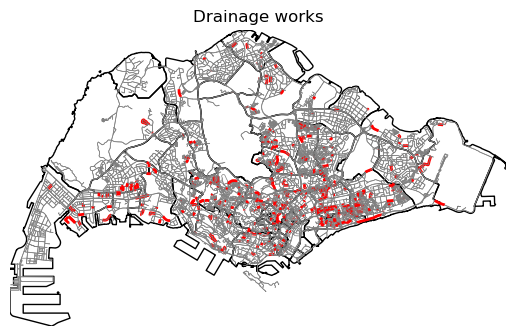

,index,S/N,Location,Date,Status,Year,Month,work_types,location,locations,...,X,Y,LATITUDE,LONGITUDE,number_of_searches,work_categories,u,v,key,geometry
0,0,1,Development of Kallang River â€“ Bishan-Ang Mo...,1/1/2012,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,...,28331.59936,38579.15538,1.365171,103.836298,2.0,Development of Kallang River,4684558080,5643502198,0,"LINESTRING (103.83684 1.36609, 103.8362 1.3663..."
1,1,2,Road Raising and Drainage Works at Ah Hood Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,...,29506.53095,34437.90694,1.327719,103.846855,2.0,Road Raising and Drainage Works,408735646,2641677416,0,"LINESTRING (103.84899 1.32839, 103.84893 1.328..."
2,2,3,Road Raising and Drainage Works at Balmoral Road,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,...,27650.84321,32837.30661,1.313244,103.830181,1.0,Road Raising and Drainage Works,2168300378,6754998201,0,"LINESTRING (103.83054 1.31357, 103.83043 1.313..."
3,3,4,Road Raising and Drainage Works at Bedok Lane,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,...,40790.72226,34619.56054,1.329357,103.948251,1.0,Road Raising and Drainage Works,1268263183,1268264187,0,"LINESTRING (103.94847 1.32906, 103.94825 1.329..."
4,4,5,Road Raising and Drainage Works at Bedok Garden,1/3/2012,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,...,NaN,NaN,1.322983,103.952932,3.0,Road Raising and Drainage Works,243486752,3030270542,0,"LINESTRING (103.95356 1.32342, 103.95306 1.323..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,591,436,ABC Waters Project @ Jurong Canal,1/10/2023,Completed,2023,10,ABC Waters Project,Jurong Canal,Jurong Canal,...,16303.58721,37042.24305,1.351269,103.728219,1.0,ABC Waters Project,4604170412,139672081,0,"LINESTRING (103.7282 1.35027, 103.7282 1.35073..."
592,592,437,Improvement to Roadside Drains and Watermain R...,1/12/2023,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Aljunied park,...,33185.87141,34630.63258,1.329461,103.879916,1.0,Improvement to Roadside Drains and Watermain R...,4603005311,385954195,0,"LINESTRING (103.87923 1.33073, 103.87928 1.330..."
593,593,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,...,28996.64591,31481.20325,1.300979,103.842274,1.0,Road Raising,1363263572,26778809,0,"LINESTRING (103.84248 1.30146, 103.84245 1.301..."
594,594,438,Road raising work at Kramat Lane / Cavenagh Road,1/12/2023,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,...,28982.50445,32268.65509,1.308094,103.842139,1.0,Road Raising,1738410982,571883466,0,"LINESTRING (103.84405 1.30984, 103.844 1.30977..."


In [22]:
planningArea_shp_mainland = planningArea_shp[~planningArea_shp["PLN_AREA_N"].str.contains("ISLAND")]
minx = planningArea_shp_mainland.bounds["minx"].min()
miny = planningArea_shp_mainland.bounds["miny"].min()
maxx = planningArea_shp_mainland.bounds["maxx"].max()
maxy = planningArea_shp_mainland.bounds["maxy"].max()

bbox = (minx, miny, maxx - 4e-4*maxx, maxy)

def identify_road_with_drainage_works(G,drainage_works, plot=True,ax=None,**kwargs):
    """                           
    Args:
        G (MultiDiGraph): graph of walking or driving network
        drainage_works (pd.DataFrame): dataframe that describes the type and location of drainage works
    Return:
        gpd: edges corresponding to drainage works location
    """
    lat = drainage_works["LATITUDE"]
    lon = drainage_works["LONGITUDE"]
    edges_drain = list(ox.nearest_edges(G,lon,lat))

    if plot:
        ec = ["red" if e in edges_drain else "grey" for e in G.edges(keys=True)]
        lw = [2 if e in edges_drain else 0.5 for e in G.edges(keys=True)]
        fig, ax = ox.plot_graph(
            G,
            ax=ax,
            node_size=0,
            node_alpha=0.8,
            edge_linewidth=lw,
            edge_color=ec,
            show=False,
            close=False,
            bgcolor="white",
            **kwargs
        )

    # get the polyline of the roads that has drainage works
    edges = ox.graph_to_gdfs(G,nodes=False,edges=True)
    edges_geometry = edges.loc[edges_drain,["geometry"]].reset_index()
    # append geometry to drainage works
    drainage_works_copy = copy.deepcopy(drainage_works)
    # reset index so the index aligns with the index of edges_geometry_df
    drainage_works_copy = drainage_works_copy.reset_index()
    drainage_works_copy[edges_geometry.columns.to_list()] = edges_geometry
    drainage_works_copy = gpd.GeoDataFrame(drainage_works_copy,geometry=drainage_works_copy["geometry"])
    return drainage_works_copy

fig, ax = plt.subplots(1,1)
planningArea_shp_mainland.plot(ax=ax,fc="None",ec="k")
drainage_works_geometry = identify_road_with_drainage_works(G_car,drainage_works,plot=True,ax=ax,bbox=bbox)
# drainage_works_geometry = identify_road_with_drainage_works(G_car,road_raising_df,plot=True,ax=ax,bbox=bbox)
ax.set_title("Drainage works")
save_fp = os.path.join(r"Exported_Data\exported_figures","road raising works.png")
# plt.savefig(save_fp, bbox_inches = 'tight')
plt.show()
drainage_works_geometry

<Axes: >

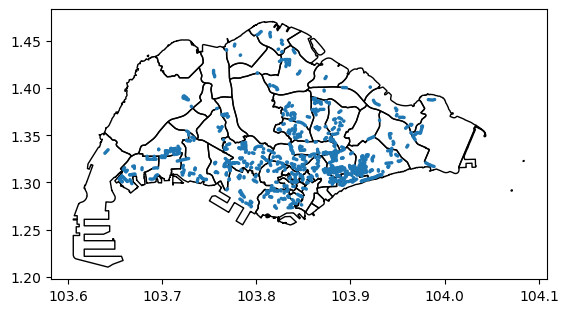

In [ ]:
def buffer_road(drainage_works_geometry,buffer=200):
    """ 
    Args:
        drainage_works_geometry (gpd): drainage works in linestring
        buffer (float): buffer around the geometry in metres
    Returns:
        polygon gpd
    """
    # project to meters UTM
    crs = drainage_works_geometry.crs
    # reproject to something that is in meters projection
    reproj_drainage_works = drainage_works_geometry.to_crs({'proj':'cea'})#.to_crs(3003)
    drainage_buffer = reproj_drainage_works.buffer(buffer)
    drainage_buffer = drainage_buffer.to_crs(crs)
    drainage_works_copy = copy.deepcopy(drainage_works_geometry)
    drainage_works_copy["geometry"] = drainage_buffer
    return drainage_works_copy

drainage_works_buffer = buffer_road(drainage_works_geometry,buffer=200)
ax = planningArea_shp_mainland.plot(fc="None",ec="k")
drainage_works_buffer.plot(ax=ax)
# drainage_works_buffer.to_file(os.path.join(r"Exported_Data","drainage_works_buffer200m.shp"),driver='ESRI Shapefile')

# Import drainage network

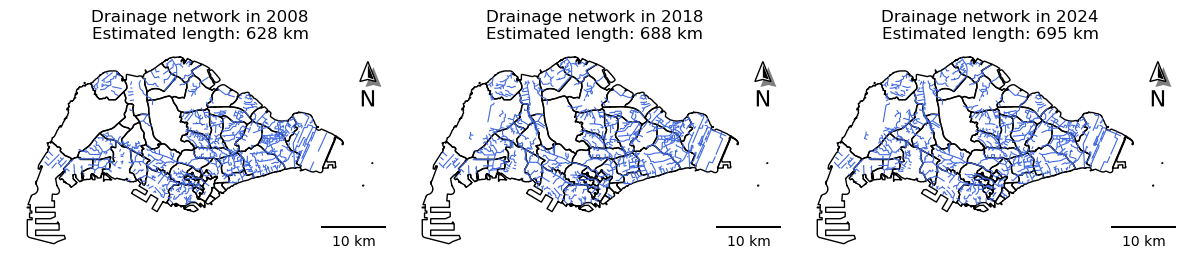

In [29]:
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\BlueMapShpFiles"
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251027 BlueMapShpFiles"
# drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251110 Blue Map layers"
drain_dir = r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\251117 Blue Map layers"
# drain_undated = "UndatedSGDrainage.shp"
drain_2008 = "2008Bluemap.shp"
drain_2018 = "251112_2018Bluemap.shp"
drain_2024 = "251117_2024Bluemap.shp"

def plot_drains(fp,planningArea,ax=None,lw=2):
    planningArea = planningArea[~planningArea['PLN_AREA_N'].str.contains("ISLAND")]
    # convert the dataset to a coordinate system which uses meters e.g. UTM work in metres
    planningArea = planningArea.to_crs(planningArea.estimate_utm_crs())
    gdf = gpd.read_file(fp)
    gdf = gdf.to_crs(planningArea.crs)
    gdf = gpd.clip(gdf,planningArea)
    # calculate total length
    drain_length = int(gdf['geometry'].length.sum()/1000) # m to km
    ax = planningArea.plot(fc="None",ec="k",ax=ax)
    gdf.plot(ax=ax,lw=lw,color="royalblue")
    # add scale
    ax.set_aspect(1)
    scalebar = ScaleBar(1, "m",location="lower right")
    # add north arrow
    north_arrow(
        ax, location="upper right", rotation={"crs": planningArea.crs, "reference": "center"},
        scale=0.2
    )
    ax.add_artist(scalebar)
    if ax is None:
        plt.show()
    
    return drain_length

fig, axes = plt.subplots(1,3,figsize=(12,6))
for ax, drain_fp,title in zip(axes.flatten(),[drain_2008,drain_2018,drain_2024],
                              ["2008","2018","2024"]):
    drain_length = plot_drains(os.path.join(drain_dir,drain_fp),planningArea_shp,ax=ax,lw=0.8)
    ax.set_title(f"Drainage network in {title}\nEstimated length: {drain_length} km")
    ax.axis('off')

save_dir = r"Exported_Data\exported_figures"
save_fp = os.path.join(save_dir,"sg_drainage_with_time.svg")
plt.tight_layout()
# plt.savefig(save_fp, bbox_inches="tight")
plt.show()

## Calculate drainage density
- calculate length of drain
- calculate area of planning area polygon
- Calculate drainage density: length of drain/planning area (km/km2)

In [ ]:
planningArea_shp_mainland = planningArea_shp[~planningArea_shp['PLN_AREA_N'].str.contains("ISLAND")]
year_drainage_density = dict()
for drain_fp,drain_year in zip([drain_2008,drain_2018,drain_2024],["2008","2018","2024"]):
    drain_shp = gpd.read_file(os.path.join(drain_dir,drain_fp))
    year_drainage_density[drain_year] = drainage_work.get_drainage_density_df(drain_shp,planningArea_shp_mainland, 
                                                             plot = False, planningArea_column="PLN_AREA_N")
year_drainage_density = pd.concat(list(year_drainage_density.values()),keys=list(year_drainage_density)).reset_index(level=[0])
year_drainage_density = year_drainage_density.rename(columns={"level_0":"year_drainage_density"})
# year_drainage_density.to_csv(os.path.join(r"Data","drainage_density_planningArea.csv"),index=False)
print("is there any NA values in drainage length: ", year_drainage_density['drainage_length_km'].isna().any())
year_drainage_density

is there any NA values in drainage length:  False


,year_drainage_density,PLN_AREA_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,BEDOK,39.297495,21.733905,1.808119
1,2008,BOON LAY,9.778237,8.282764,1.180552
2,2008,BUKIT BATOK,11.364697,11.140156,1.020156
3,2008,BUKIT MERAH,20.794830,14.461198,1.437974
4,2008,BUKIT PANJANG,5.170875,9.019930,0.573272
...,...,...,...,...,...
50,2024,BISHAN,14.121524,7.608112,1.856114
51,2024,ANG MO KIO,21.693473,13.942584,1.555915
52,2024,GEYLANG,24.056455,9.644787,2.494244
53,2024,PAYA LEBAR,11.536274,11.685269,0.987249


In [178]:
subzone_shp_mainland = subzone_shp[~subzone_shp['PLN_AREA_N'].str.contains("ISLAND")]
year_drainage_density = dict()
for drain_fp,drain_year in zip([drain_2008,drain_2018,drain_2024],[2008,2018,2024]):
    drain_shp = gpd.read_file(os.path.join(drain_dir,drain_fp))
    year_drainage_density[drain_year] = drainage_work.get_drainage_density_df(drain_shp,subzone_shp_mainland, 
                                                             plot = False, planningArea_column="SUBZONE_N")
year_drainage_density = pd.concat(list(year_drainage_density.values()),keys=list(year_drainage_density)).reset_index(level=[0])
year_drainage_density = year_drainage_density.rename(columns={"level_0":"year_drainage_density"})
# year_drainage_density.to_csv(os.path.join(r"Data","drainage_density_subzone.csv"),index=False)
print("is there any NA values in drainage length: ", year_drainage_density['drainage_length_km'].isna().any())
year_drainage_density

is there any NA values in drainage length:  False


,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,DEPOT ROAD,0.141179,0.442297,0.319195
1,2008,BUKIT MERAH,1.312479,0.411723,3.187775
2,2008,CHINATOWN,0.000000,0.587223,0.000000
3,2008,PHILLIP,0.000000,0.039438,0.000000
4,2008,RAFFLES PLACE,0.000000,0.188767,0.000000
...,...,...,...,...,...
327,2024,UPPER THOMSON,5.942076,3.849507,1.543594
328,2024,SHANGRI-LA,1.433712,0.687914,2.084146
329,2024,TOWNSVILLE,0.780752,0.546394,1.428919
330,2024,MARYMOUNT,3.793594,1.964145,1.931423


### Merge residential with drainage density

In [174]:
x = year_drainage_density[year_drainage_density["SUBZONE_N"]=="TANJONG RHU"].reset_index(drop=True)
x

,year_drainage_density,SUBZONE_N,drainage_length_km,area_km2,drainage_density (km/km2)
0,2008,TANJONG RHU,2.130096,2.434593,0.874929
1,2018,TANJONG RHU,2.114527,2.434593,0.868534
2,2024,TANJONG RHU,2.106817,2.434593,0.865368


In [217]:
residential_drainage_den = residential_transaction_df.merge(year_drainage_density,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"]).sort_values(by="Sale_Date")
# residential_drainage_den = drainage_work.add_drainage_density(residential_drainage_den,year_drainage_density)
# residential_drainage_den
residential_drainage_den.groupby(["SUBZONE_N"]).apply(lambda i: drainage_work.get_drainage_density(i,year_drainage_density)).reset_index(drop=True)

C:\Users\hypak\AppData\Local\Temp\ipykernel_26584\4135806920.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  residential_drainage_den.groupby(["SUBZONE_N"]).apply(lambda i: drainage_work.get_drainage_density(i,year_drainage_density)).reset_index(drop=True)


,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,LONGITUDE,year,month,geometry,index_right,SUBZONE_N,year_drainage_density,drainage_length_km,area_km2,drainage_density (km/km2)
0,TANGLIN VIEW,1600000,1151.75,1389,2014-03-05,152 PRINCE CHARLES CRESCENT #14-10,Resale,Strata,107.0,14953,...,103.817881,2014,3,POINT (103.81788 1.292),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
1,TANGLIN REGENCY,1430000,1044.11,1370,2014-03-13,381 TANGLIN ROAD #06-04,Resale,Strata,97.0,14742,...,103.815998,2014,3,POINT (103.816 1.29204),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
2,TANGLIN VIEW,1560000,1140.98,1367,2014-04-16,152 PRINCE CHARLES CRESCENT #10-14,Resale,Strata,106.0,14717,...,103.817881,2014,4,POINT (103.81788 1.292),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
3,TANGLIN REGENCY,1443000,1108.69,1302,2014-04-28,381 TANGLIN ROAD #11-07,Resale,Strata,103.0,14010,...,103.815998,2014,4,POINT (103.816 1.29204),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
4,TANGLIN REGENCY,1180000,850.36,1388,2014-05-12,383 TANGLIN ROAD #08-06,Resale,Strata,79.0,14937,...,103.816570,2014,5,POINT (103.81657 1.29197),65,ALEXANDRA NORTH,2008.0,1.107530,0.293695,3.771018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267447,WESTVILLE,2330000,1747.00,1334,2025-06-03,13 WESTWOOD ROAD,Resale,Land,162.3,14356,...,103.699206,2025,6,POINT (103.69921 1.35138),258,YUNNAN,2024.0,4.444214,2.206292,2.014336
267448,THE FLORAVALE,1375000,1248.62,1101,2025-06-03,236 WESTWOOD AVENUE #09-08,Resale,Strata,116.0,11853,...,103.696366,2025,6,POINT (103.69637 1.3506),258,YUNNAN,2024.0,4.444214,2.206292,2.014336
267449,WESTWOOD RESIDENCES,1320000,1033.34,1277,2025-06-09,180 WESTWOOD AVENUE #03-02,Resale,Strata,96.0,13750,...,103.696215,2025,6,POINT (103.69621 1.3519),258,YUNNAN,2024.0,4.444214,2.206292,2.014336
267450,WESTWOOD RESIDENCES,1440000,1033.34,1394,2025-06-12,190 WESTWOOD AVENUE #13-23,Resale,Strata,96.0,15000,...,103.697101,2025,6,POINT (103.6971 1.35254),258,YUNNAN,2024.0,4.444214,2.206292,2.014336


In [211]:

residential_drainage_den = residential_transaction_df.merge(year_drainage_density,how="left",left_on=["SUBZONE_N","year"],right_on=["SUBZONE_N","year_drainage_density"]).sort_values(by="Sale_Date")
# residential_drainage_den = drainage_work.add_drainage_density(residential_drainage_den,year_drainage_density)
# 
# mask = residential_drainage_den[["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]]<1
# residential_drainage_den.loc[mask.all(axis=1),"Sale_Date"].dt.year.min()
# residential_drainage_den.loc[mask.all(axis=1),["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]] = residential_drainage_den.loc[152817,["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]].values
# residential_drainage_den[["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]]

drainage_density_columns = ["year_drainage_density","drainage_length_km","area_km2","drainage_density (km/km2)"]
    
def get_drainage_density(df_subset,drain_df):
    """ For each subzone, fill down the same drainage density
    Args:
        df_subset (pd.DataFrame) refers to the specific subzone df_subset
        
    Returns:
        pd.Series
    """
    sale_date_column = "Sale_Date"
    noData=0
    # filter drain_df to match the subzone
    drain_df_subset = drain_df[drain_df["SUBZONE_N"]==df_subset["SUBZONE_N"].values[0]].sort_values(by="year_drainage_density").reset_index(drop=True)
    if len(drain_df_subset) > 0: # means there is drain in the SUBZONE_N
        drain_year = drain_df_subset["year_drainage_density"]
        
        df_subset = df_subset.sort_values(by=sale_date_column)
        df_subset[drainage_density_columns] = df_subset[drainage_density_columns].ffill()#.fillna(noData)
        # check if there's na
        mask = df_subset[drainage_density_columns].isna()
        if mask.all(axis=1).any():
            # obtain the years where there is NA
            year_NA = df_subset.loc[mask.all(axis=1),sale_date_column].dt.year
            # extract the drain_df where drain years are lesser than minimum transaction year
            min_year = year_NA.min()
            year_mask = drain_year < min_year
            drain_NA = drain_df_subset.loc[year_mask,drainage_density_columns]
            # use idxmax to find the latest drain year that is smaller than transaction year
            df_subset.loc[mask.all(axis=1),drainage_density_columns] = drain_NA.iloc[-1].values
            return df_subset
        else:
            return df_subset
    else: # means no drain in SUBZONE_N
        df_subset[drainage_density_columns] = df_subset[drainage_density_columns].fillna(noData)
        return df_subset

def add_drainage_density(df,drain_df,sale_date_column = "Sale_Date",noData=0):
    """                             
    add drainage density based on drainage density of specific year and to that subzone
    # TODO: create a buffer of 200 m around drainage df to see if residential areas living near to drains are more/less prone to flooding, since canal overflowing often can lead to higher flood risk
    Args:
        df (pd.DataFrame): dataframe after merging drainage density to residential df
        drain_df (pd.DataFrame): dataframe on drainage density (output from get_drainage_density_df)
        noData (float): for subzones where there are no drainage length data before 2008, assign missing data as noData (default=0)
    Returns:
        pd.DataFrame with added columns describing the stages of drainage work and drainage type
    """
    df_copy = copy.deepcopy(df)
    
    return df_copy.groupby(["SUBZONE_N"]).apply(lambda i: get_drainage_density(i,drain_df)).reset_index(level=[0])[drainage_density_columns]

# add_drainage_density(residential_drainage_den,year_drainage_density,sale_date_column = "Sale_Date",noData=0)
for k, df in residential_drainage_den.groupby("SUBZONE_N"):
    # x = residential_drainage_den[residential_drainage_den["SUBZONE_N"]=="TANJONG RHU"]
    try:
        get_drainage_density(df,year_drainage_density)
    except:
        print(k)

# x = residential_drainage_den[residential_drainage_den["SUBZONE_N"]=="SENTOSA"]
# get_drainage_density(x,year_drainage_density)
# len(year_drainage_density[year_drainage_density["SUBZONE_N"]=="SENTOSA"])

In [197]:
residential_drainage_den[residential_drainage_den["SUBZONE_N"]=="BIDADARI"]

,Project Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,LONGITUDE,year,month,geometry,index_right,SUBZONE_N,year_drainage_density,drainage_length_km,area_km2,drainage_density (km/km2)
259792,THE WOODLEIGH RESIDENCES,1480000,721.19,2052,2018-11-10,27 BIDADARI PARK DRIVE #08-46,New Sale,Strata,67.0,22090,...,103.871540,2018,11,POINT (103.87154 1.33921),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259793,THE WOODLEIGH RESIDENCES,1409000,645.84,2182,2018-11-10,23 BIDADARI PARK DRIVE #06-34,New Sale,Strata,60.0,23483,...,103.871424,2018,11,POINT (103.87142 1.33885),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259794,THE WOODLEIGH RESIDENCES,1140000,592.02,1926,2018-11-10,25 BIDADARI PARK DRIVE #05-38,New Sale,Strata,55.0,20727,...,103.871225,2018,11,POINT (103.87123 1.33914),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259795,THE WOODLEIGH RESIDENCES,1191000,592.02,2012,2018-11-10,25 BIDADARI PARK DRIVE #12-38,New Sale,Strata,55.0,21655,...,103.871225,2018,11,POINT (103.87123 1.33914),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
259797,THE WOODLEIGH RESIDENCES,1450000,721.19,2011,2018-11-10,27 BIDADARI PARK DRIVE #03-46,New Sale,Strata,67.0,21642,...,103.871540,2018,11,POINT (103.87154 1.33921),205,BIDADARI,2018.0,0.259188,0.572502,0.452728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267391,THE WOODLEIGH RESIDENCES,2700000,958.00,2818,2025-05-19,31 BIDADARI PARK DRIVE #06-57,Sub Sale,Strata,89.0,30337,...,103.872040,2025,5,POINT (103.87204 1.33915),205,BIDADARI,NaN,NaN,NaN,NaN
267403,THE WOODLEIGH RESIDENCES,1580000,699.66,2258,2025-05-26,21 BIDADARI PARK DRIVE #07-23,Sub Sale,Strata,65.0,24308,...,103.871406,2025,5,POINT (103.87141 1.33846),205,BIDADARI,NaN,NaN,NaN,NaN
267424,THE WOODLEIGH RESIDENCES,1270000,570.49,2226,2025-06-05,21 BIDADARI PARK DRIVE #03-22,Sub Sale,Strata,53.0,23962,...,103.871406,2025,6,POINT (103.87141 1.33846),205,BIDADARI,NaN,NaN,NaN,NaN
267421,THE WOODLEIGH RESIDENCES,2430000,958.00,2537,2025-06-05,27 BIDADARI PARK DRIVE #04-48,Sub Sale,Strata,89.0,27303,...,103.871540,2025,6,POINT (103.87154 1.33921),205,BIDADARI,NaN,NaN,NaN,NaN


Import hydrographic

<Axes: >

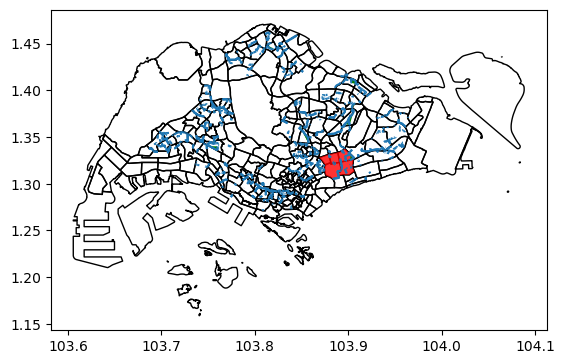

In [48]:
hydrographic = gpd.read_file(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\SG_HDB_DRAIN_OUTLINE_L.shp")
hydrographic = hydrographic.to_crs(subzone_shp.crs)
ax = subzone_shp.plot(fc="none",ec="k")
planningArea_shp[planningArea_shp["PLN_AREA_N"]=="GEYLANG"].plot(ax=ax,fc="red",alpha=0.8)
hydrographic.plot(ax=ax)

Calculate drainage difference across the years

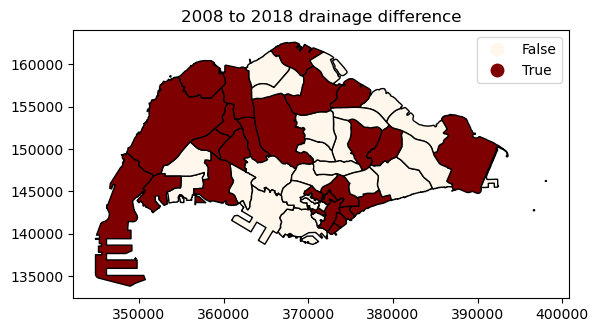

In [215]:
def drainage_density_difference(drain_before,drain_after,plot=True,ax=None,title=""):
    """    
    calculate difference in drainage density between years                         
    Args:
        drain_before (pd.DataFrame):
        drain_after (pd.DataFrame):
    """
    drain_after["drainage_density_difference"] = drain_after["drainage_density (km/km2)"] - drain_before["drainage_density (km/km2)"]
    # positive if there is an increase in drainage density, -ve if there is a decrease
    drain_after["drainage_density_direction"] = drain_after["drainage_density_difference"]>0
    if plot:
        ax = drain_after.plot(column="drainage_density_direction",cmap='OrRd',ec="k",
                               ax=ax,
                               legend=True)
        ax.set_title(title)
    return 

drainage_density_difference(year_drainage_density["2008Bluemap.shp"],
                            year_drainage_density["2018Bluemap.shp"],
                            title="2008 to 2018 drainage difference",
                            plot=True,ax=None)

# Correct completed drainage projects (2012-2024) [Analysis]

In [92]:
drainage_projects = pd.read_csv(r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\SG_Drains\Drainage plans\PUB_All_Drainage_Projects_2012_2024.csv")
drainage_projects_completed = drainage_projects[drainage_projects["Status"]=="Completed"]
drainage_projects_completed["Date"] = pd.to_datetime(drainage_projects_completed["Date"],format="%b-%y")
drainage_projects_completed["Year"] = drainage_projects_completed["Date"].dt.year
drainage_projects_completed["Month"] = drainage_projects_completed["Date"].dt.month

# separate project type and location

def extract_road_names(text):
    
    pattern = r"^(.*?)\s*(?:\bat\b|[-–—@])\s*(.*)$"

    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        work_types = match.group(1).strip()
        location = match.group(2).strip()
    else:
        pattern = r"^(.*?)\s*\b(?:in|to|along|of|for)\s*(.*)$"

        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            work_types = match.group(1).strip()
            location = match.group(2).strip()
        else:
            work_types = None
            location = text
    
    return pd.Series({"work_types":work_types,"location":location},index=["work_types","location"])

drainage_projects_completed[["work_types","location"]] = drainage_projects_completed["Location"].apply(lambda x: extract_road_names(x))

# Find multiple roads and split them if applicable

def extract_multiple_road_names(text):

    # Remove extra whitespace
    text = text.strip()

    def split_separator(s):
        # Otherwise, split by common separators (/, &, to, ,)
        pattern = r'\s*(?:/|&|,|\bto\b)\s*'
        parts = re.split(pattern, s, flags=re.IGNORECASE)
        return [p.strip() for p in parts if p.strip()]
    
    # 1. Handle parentheses first — extract before and inside ()
    bracket_match = re.match(r'^(.*?)\s*\(([^)]+)\)\s*$', text)
    if bracket_match:
        before = bracket_match.group(1).strip()
        inside = bracket_match.group(2).strip()
        
        return [before] + split_separator(inside)

    return split_separator(text)

drainage_projects_completed["locations"] = drainage_projects_completed["location"].apply(lambda x: extract_multiple_road_names(x))
drainage_projects_completed = drainage_projects_completed.explode("locations")

drainage_projects_completed

C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drainage_projects_completed["Date"] = pd.to_datetime(drainage_projects_completed["Date"],format="%b-%y")
C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drainage_projects_completed["Year"] = drainage_projects_completed["Date"].dt.year
C:\Users\hypak\AppData\Local\Temp\ipykernel_4724\2806663881.py:5: SettingWithCopyWarning: 
A value is

,S/N,Location,Date,Status,Year,Month,work_types,location,locations
0,1,Development of Kallang River – Bishan-Ang Mo K...,2012-01-01,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park
1,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road
2,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road
3,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden
...,...,...,...,...,...,...,...,...,...
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road
438,439,Drainage work at Jurong East St 32,2023-07-01,Completed,2023,7,Drainage work,Jurong East St 32,Jurong East St 32


Get coordinates of drainage works location

In [93]:
def get_road_location(road,headers,index=['SEARCHVAL','BLK_NO','ROAD_NAME','BUILDING','ADDRESS','POSTAL','X','Y','LATITUDE','LONGITUDE']):
    try:
        searches = OneMapAPI.get_coordinates_from_location(road, headers)
        location_dict = searches[0]
        location_dict["number_of_searches"] = len(searches)
    except:
        index.append("number_of_searches")
        location_dict = {k:None for k in index}
    
    
    return pd.Series(location_dict, index=list(location_dict))

headers = OneMapAPI.generate_OneMap_headers()
drainage_locations = drainage_projects_completed["locations"].apply(lambda x: get_road_location(x,headers))
drainage_locations

,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,BISHAN - ANG MO KIO PARK (POND GARDENS),,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.5993566066,38579.1553769931,1.36517069591469,103.83629822663,2.0
1,AH HOOD ROAD,,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.5309455593,34437.90693839,1.32771861428245,103.846855352744,2.0
2,BALMORAL ROAD,,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.8432115718,32837.3066058314,1.31324355521211,103.830181342875,1.0
3,BEDOK LANE,,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.7222646378,34619.5605429257,1.32935743601885,103.948251313101,1.0
4,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
...,...,...,...,...,...,...,...,...,...,...,...
436,None,None,None,None,None,None,None,None,None,None,NaN
437,KRAMAT LANE,,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.6459057741,31481.2032468384,1.30097931805497,103.84227389462,1.0
437,CAVENAGH ROAD,,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.5044461648,32268.6550906781,1.30809356579841,103.84213845629,1.0
438,JURONG EAST STREET 32,,JURONG EAST STREET 32,NIL,JURONG EAST STREET 32,NIL,16927.0841891803,36565.146363027,1.34694849545159,103.733825383102,1.0


In [94]:
drainage_projects_completed = pd.concat([drainage_projects_completed,drainage_locations],axis=1)
drainage_projects_completed.to_csv(r"Exported_Data\drainage_works_2012_2024.csv",index=False)
drainage_projects_completed

,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,1,Development of Kallang River – Bishan-Ang Mo K...,2012-01-01,Completed,2012,1,Development of Kallang River,Bishan-Ang Mo Kio Park,Bishan-Ang Mo Kio Park,BISHAN - ANG MO KIO PARK (POND GARDENS),,NIL,BISHAN - ANG MO KIO PARK (POND GARDENS),BISHAN - ANG MO KIO PARK (POND GARDENS),NIL,28331.5993566066,38579.1553769931,1.36517069591469,103.83629822663,2.0
1,2,Road Raising and Drainage Works at Ah Hood Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Ah Hood Road,Ah Hood Road,AH HOOD ROAD,,AH HOOD ROAD,NIL,AH HOOD ROAD,NIL,29506.5309455593,34437.90693839,1.32771861428245,103.846855352744,2.0
2,3,Road Raising and Drainage Works at Balmoral Road,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Balmoral Road,Balmoral Road,BALMORAL ROAD,,BALMORAL ROAD,NIL,BALMORAL ROAD,NIL,27650.8432115718,32837.3066058314,1.31324355521211,103.830181342875,1.0
3,4,Road Raising and Drainage Works at Bedok Lane,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Lane,Bedok Lane,BEDOK LANE,,BEDOK LANE,NIL,BEDOK LANE,NIL,40790.7222646378,34619.5605429257,1.32935743601885,103.948251313101,1.0
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate,None,None,None,None,None,None,None,None,None,None,NaN
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Kramat Lane,KRAMAT LANE,,KRAMAT LANE,NIL,KRAMAT LANE,NIL,28996.6459057741,31481.2032468384,1.30097931805497,103.84227389462,1.0
437,438,Road raising work at Kramat Lane / Cavenagh Road,2023-12-01,Completed,2023,12,Road raising work,Kramat Lane / Cavenagh Road,Cavenagh Road,CAVENAGH ROAD,,CAVENAGH ROAD,NIL,CAVENAGH ROAD,NIL,28982.5044461648,32268.6550906781,1.30809356579841,103.84213845629,1.0
438,439,Drainage work at Jurong East St 32,2023-07-01,Completed,2023,7,Drainage work,Jurong East St 32,Jurong East St 32,JURONG EAST STREET 32,,JURONG EAST STREET 32,NIL,JURONG EAST STREET 32,NIL,16927.0841891803,36565.146363027,1.34694849545159,103.733825383102,1.0


In [154]:
def get_location_IQ(location,
                    index=['SEARCHVAL','BLK_NO','ROAD_NAME','BUILDING','ADDRESS','POSTAL','X','Y','LATITUDE','LONGITUDE']):
    searches = LocationIqAPI.get_coordinates_from_location(location)

    location_dict = {k:None for k in index}
    try:
        response = searches[0]
        location_dict['SEARCHVAL'] = response['display_name']
        location_dict['LATITUDE'] = response['lat']
        location_dict['LONGITUDE'] = response['lon']
        location_dict["number_of_searches"] = len(searches)
    except:
        location_dict["number_of_searches"] = None
    
    return pd.Series(location_dict,index=list(location_dict))
    
    
x = get_location_IQ("Phoenix, Singapore, Singapore")
x

SEARCHVAL             Phoenix, 40, Choa Chu Kang Road, Teck Whye, Ch...
BLK_NO                                                             None
ROAD_NAME                                                          None
BUILDING                                                           None
ADDRESS                                                            None
POSTAL                                                             None
X                                                                  None
Y                                                                  None
LATITUDE                                                      1.3786164
LONGITUDE                                                    103.758008
number_of_searches                                                    2
dtype: object

In [165]:
lorongGeylang = LocationIqAPI.get_coordinates_from_location("Lorong 42 Geylang, Singapore, Singapore")
lorongGeylang

[{'place_id': '251031082',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '46342760',
  'boundingbox': ['1.3143543', '1.3146876', '103.8902132', '103.8902533'],
  'lat': '1.3146876',
  'lon': '103.8902132',
  'display_name': 'Lorong 42 Geylang, Geylang, Southeast, Singapore, 389604, Central Region, Singapore',
  'class': 'highway',
  'type': 'residential',
  'importance': 0.5834176615548942},
 {'place_id': '250993455',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '1015739635',
  'boundingbox': ['1.3140305', '1.3141815', '103.8902879', '103.8903376'],
  'lat': '1.3140473',
  'lon': '103.8903147',
  'display_name': 'Lorong 42 Geylang, Geylang, Southeast, Singapore, 398024, Central Region, Singapore',
  'class': 'highway',
  'type': 'service',
  'importance': 0.5700843282215609},
 {'place_id': '251351702',
  'licence': 'https://locationiq.com/attribution',
  'osm_type': 'way',
  'osm_id': '647095214',
  'boundingb

In [160]:
problematic_rows = drainage_projects_completed[((drainage_projects_completed['number_of_searches']>2) | (drainage_projects_completed['number_of_searches'].isna()))]
problematic_rows

,S/N,Location,Date,Status,Year,Month,work_types,location,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
4,5,Road Raising and Drainage Works at Bedok Garden,2012-03-01,Completed,2012,3,Road Raising and Drainage Works,Bedok Garden,Bedok Garden,BEDOK RESERVOIR GARDEN,716,BEDOK RESERVOIR ROAD,BEDOK RESERVOIR GARDEN,716 BEDOK RESERVOIR ROAD BEDOK RESERVOIR GARDE...,470716,38200.2399324467,35557.0303214137,1.33783795176833,103.924973671246,10.0
8,9,Drainage Works at Ewe Boon Rd Areas,2012-11-01,Completed,2012,11,Drainage Works,Ewe Boon Rd Areas,Ewe Boon Rd Areas,None,None,None,None,None,None,None,None,None,None,NaN
10,11,Improvement to Roadside Drains In Estate Upgra...,2012-11-01,Completed,2012,11,Improvement to Roadside Drains In Estate Upgra...,Phoenix,Phoenix,PHOENIX HEIGHTS,10,PHOENIX GARDEN,PHOENIX HEIGHTS,10 PHOENIX GARDEN PHOENIX HEIGHTS SINGAPORE 66...,668278,19662.3186762407,39840.217556119,1.37657410885303,103.758398456974,10.0
12,13,Drainage Works at Lorong 102 to 106 Changi Rd,2013-01-01,Completed,2013,1,Drainage Works,Lorong 102 to 106 Changi Rd,106 Changi Rd,1063A UPPER CHANGI ROAD NORTH SINGAPORE 507704,1063A,UPPER CHANGI ROAD NORTH,NIL,1063A UPPER CHANGI ROAD NORTH SINGAPORE 507704,507704,43773.0555428769,38628.6779148001,1.36561435805998,103.975050188576,9.0
18,19,Drainage Works at Dunearn Rd/ Hillcrest Rd jun...,2013-01-01,Completed,2013,1,Drainage Works,Dunearn Rd/ Hillcrest Rd junction,Dunearn Rd,DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),,NIL,DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),DUNEARN ROAD / WAYANG SATU FLYOVER - ERP(43),NIL,26907.0627031503,33764.3403379712,1.32162720092152,103.823497961309,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,431,Improvement to Bayshore Park Outlet Drain (ECP...,2023-03-01,Completed,2023,3,Improvement,Bayshore Park Outlet Drain (ECP Service Road t...,Bayshore Park Outlet Drain,None,None,None,None,None,None,None,None,None,None,NaN
430,431,Improvement to Bayshore Park Outlet Drain (ECP...,2023-03-01,Completed,2023,3,Improvement,Bayshore Park Outlet Drain (ECP Service Road t...,the Sea,CHURCH OF OUR LADY STAR OF THE SEA,10,YISHUN STREET 22,CHURCH OF OUR LADY STAR OF THE SEA,10 YISHUN STREET 22 CHURCH OF OUR LADY STAR OF...,768579,28515.1892367527,46549.7553463355,1.43725393340129,103.837948048756,10.0
433,434,Drainage work at Sennett Estate,2023-10-01,Completed,2023,10,Drainage work,Sennett Estate,Sennett Estate,SENNETT ESTATE,8,KWONG AVENUE,SENNETT ESTATE,8 KWONG AVENUE SENNETT ESTATE SINGAPORE 348882,348882,32218.0471483897,34727.6016367543,1.33033832214633,103.871220086251,10.0
436,437,Improvement to Roadside Drains and Watermain R...,2023-12-01,Completed,2023,12,Improvement to Roadside Drains and Watermain R...,Happy Gardens Estate,Happy Gardens Estate,None,None,None,None,None,None,None,None,None,None,NaN


In [199]:
# OneMapAPI.get_coordinates_from_location("stadium cres", headers)
get_location_IQ("woodlands avenue 5, Singapore, Singapore")

SEARCHVAL             Woodlands Avenue 5, Woodgrove, Woodlands, Nort...
BLK_NO                                                             None
ROAD_NAME                                                          None
BUILDING                                                           None
ADDRESS                                                            None
POSTAL                                                             None
X                                                                  None
Y                                                                  None
LATITUDE                                                      1.4352105
LONGITUDE                                                   103.7832869
number_of_searches                                                   10
dtype: object

In [197]:
problematic_rows0 = pd.read_csv(r"Exported_Data\locations_problem.csv")
headers = OneMapAPI.generate_OneMap_headers()
problematic_rows0[['SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE', 'LONGITUDE',"number_of_searches"]] = problematic_rows0["locations"].apply(lambda x: get_road_location(x,headers))
problematic_rows0.dropna(subset=["number_of_searches"]).to_csv(r"Exported_Data\drainage_works_OneMap.csv",index=False)
problematic_rows0

,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,Bukit Timah Road,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,,NIL,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,BT TIMAH EXPRESSWAY (SB BETW DAIRY FARM RD & P...,NIL,22941.8794712201,37287.9545795117,1.35349310900464,103.787868117719,10.0
1,Holland Green,HOLLAND GREEN,13,HOLLAND GREEN,HOLLAND GREEN,13 HOLLAND GREEN HOLLAND GREEN SINGAPORE 276136,276136,22560.6319996007,34204.5193922799,1.32560755852268,103.784442917855,10.0
2,Simon Lane,SIMON LANE,,SIMON LANE,NIL,SIMON LANE,NIL,33686.1137061781,38364.3591386009,1.3632275437128,103.884412113606,1.0
3,Woodlands Ave 5,WOODLANDS (AVE 5) PARK CONNECTOR,,NIL,WOODLANDS (AVE 5) PARK CONNECTOR,WOODLANDS (AVE 5) PARK CONNECTOR,NIL,22677.5393020539,46213.5384015962,1.43421281069085,103.785491223073,2.0
4,Yishun Ave 2,YISHUN AVENUE 2,,YISHUN AVENUE 2,NIL,YISHUN AVENUE 2,NIL,28202.6440075983,45273.5176599755,1.42571397983231,103.835139618109,1.0
5,Yishun Ring Rd,YISHUN RING ROAD,,YISHUN RING ROAD,NIL,YISHUN RING ROAD,NIL,27862.0939109092,45319.0557803195,1.42612719073754,103.832079231115,1.0
6,Begonia Crescent,BEGONIA CRESCENT,,BEGONIA CRESCENT,NIL,BEGONIA CRESCENT,NIL,31245.2722163482,41191.7776856891,1.38879640980153,103.862479371745,1.0
7,Tamarind Rd,TAMARIND ROAD,,TAMARIND ROAD,NIL,TAMARIND ROAD,NIL,31056.8891117251,41214.2047590209,1.38900165033246,103.860786121723,2.0
8,International Road,INTERNATIONAL ROAD,,INTERNATIONAL ROAD,NIL,INTERNATIONAL ROAD,NIL,13189.1185101493,34441.8549599852,1.32775081717739,103.700234799202,1.0
9,2nd Lok Yang Road,None,None,None,None,None,None,None,None,None,None,NaN


In [198]:
problematic_rows0 = pd.read_csv(r"Exported_Data\locations_problem.csv")
problematic_rows0[['SEARCHVAL', 'BLK_NO', 'ROAD_NAME', 'BUILDING', 'ADDRESS', 'POSTAL', 'X', 'Y', 'LATITUDE', 'LONGITUDE',"number_of_searches"]] = problematic_rows0["locations"].apply(lambda x: get_location_IQ(f"{x}, Singapore, Singapore"))
problematic_rows0.dropna(subset=["number_of_searches"]).to_csv(r"Exported_Data\drainage_works_locationIQ.csv",index=False)
problematic_rows0

,locations,SEARCHVAL,BLK_NO,ROAD_NAME,BUILDING,ADDRESS,POSTAL,X,Y,LATITUDE,LONGITUDE,number_of_searches
0,Bukit Timah Road,"Bukit Timah Road, Fairwood Park, Bukit Timah, ...",None,None,None,None,None,None,None,1.3364318,103.7818681,10.0
1,Holland Green,"Holland Green, Ewart Park, Bukit Timah, Northw...",None,None,None,None,None,None,None,1.3259011,103.7849681,10.0
2,Simon Lane,"Simon Lane, Hougang, Singapur East, Northeast,...",None,None,None,None,None,None,None,1.363333,103.8845316,6.0
3,Woodlands Ave 5,None,None,None,None,None,None,None,None,None,None,NaN
4,Yishun Ave 2,None,None,None,None,None,None,None,None,None,None,NaN
5,Yishun Ring Rd,"Yishun Ring Road, Yishun, Northwest, Singapore...",None,None,None,None,None,None,None,1.4179201,103.8403973,10.0
6,Begonia Crescent,"Begonia Crescent, Serangoon, Hock Swee Hill, C...",None,None,None,None,None,None,None,1.3893102,103.8626113,2.0
7,Tamarind Rd,None,None,None,None,None,None,None,None,None,None,NaN
8,International Road,"International Road, Jurong West, Southwest, Si...",None,None,None,None,None,None,None,1.3278187,103.6878477,10.0
9,2nd Lok Yang Road,"90, Second Lok Yang Road, Joo Koon, Pioneer, S...",None,None,None,None,None,None,None,1.32558,103.691185,10.0


# Data processing flood prone areas

In [27]:

def get_flooding_hotspots(flooding_hotspots_fp,
                          headers,save_fp=None):
    """ Returns the matched location given a flooded location, using the OneMap API
    Note: Same function should work for flood prone fp too
    Args:
        flooding_hotspots_fp (str): filepath to df where each column corresponds to flooding locations in that particular year
        save_fp (str): file to save csv
    Returns:
        pd.DataFrame: long format of flooding hotspot
    """
    flooding_hotspots = pd.read_csv(flooding_hotspots_fp,encoding='latin-1')
    flooding_hotspots_columns = [col.split('-')[1].strip() for col in flooding_hotspots.columns.to_list()]
    flooding_hotspots.columns = flooding_hotspots_columns
    flooding_hotspots = pd.melt(flooding_hotspots, value_name="flooded_location", var_name="year").dropna()
    flooding_hotspots['flooded_location'] = flooding_hotspots['flooded_location'].str.split("/|,",regex=True)
    flooding_hotspots = flooding_hotspots.explode('flooded_location')
    flooding_hotspots['flooded_location'] = flooding_hotspots['flooded_location'].str.strip()

    def get_location(location,headers):
        results = OneMapAPI.get_coordinates_from_location(location,headers=headers)
        # get first result
        try:
            result = results[0]

            hotspots = {'flooded_location':location,
                            'responses_found':len(results), 
                            'matched_location':result['SEARCHVAL'], 
                            'latitude':result['LATITUDE'], 
                            'longitude':result['LONGITUDE']}
        except:
            hotspots = {'flooded_location':location,
                            'responses_found':None, 
                            'matched_location':None, 
                            'latitude':None, 
                            'longitude':None}
        return pd.Series(hotspots, index=list(hotspots))
    
    location_mapping = {
        "Admiralty Road West near Sembawang shipyard": "80 ADMIRALTY ROAD WEST SINGAPORE 759951",
        "Lorong Chuan at St Gabriel.* Primary School": "SAINT GABRIEL'S PRIMARY SCHOOL",
        "King George.* Avenue at former Christ Church Sec School": "111A KING GEORGE'S AVENUE SINGAPORE 208559",
        "Former Umar PulavarTamil Language Centre off Beatty Road": "2 BEATTY ROAD SINGAPORE 209954",
        "CTE.*(S|s)lip.*Moulmein Road": "110 SHREWSBURY ROAD SINGAPORE 307853",
        "Bishopsgate Road": "BISHOPSGATE RESIDENCES",
        "Viking Road": "108 ALEXANDRA VIEW SINGAPORE 150108",
        "Rochalie Drive to Grange Rd": "ORCHARD BOULEVARD MRT STATION",
        r"Zion.*\(Boys.*Brigade HQ\)|Former Boys' Brigade HQ at Zion Road": "87 ZION ROAD SINGAPORE 160087",
        r"Delta Ave.*\(APSN Delta Senior School\)": "DELTA AVENUE",
        "Amberville Carpark": "AMBER ROAD",
        "Rose Garden": "10 ROCHALIE DRIVE SINGAPORE 248242",
        r"Service road off Tampines Road.*\(near Jalan Teliti\)": "64 TAMPINES ROAD SINGAPORE 535088",
        "Mindef.* Changi Camp off Farnborough Road": "FARNBOROUGH ROAD",
        "Lorong H Telok Kurau.*": "LORONG H TELOK KURAU",
        r"New Upper Changi.*\(Chye Heng Garden\)": "NEW UPPER CHANGI ROAD",
        "Clover Park Estate": "Clover Park",
        r"Upper East Coast Road \(near Bayshore Road\)": "2 BAYSHORE ROAD SINGAPORE 469960",
        r"Upp.*East Coast.*\(.*Parbury Avenue\)": "507 UPPER EAST COAST ROAD SINGAPORE 466532",
        "Princep Steet": "PRINSEP STREET",
        r"King George.* Avenue \(People.* Association HQ\)|People.*Association.*": "PEOPLE'S ASSOCIATION HEADQUARTERS",
        "Upp Hokkien St": "HONG LIM FOOD CENTRE AND MARKET",
        "Hong Kah (a|A)rea": "HONG KAH COURT",
        "Langsat Road Area|LANGSAT ROAD.*": "LANGSAT ROAD",
        "St John.* Headquarters at junction of Beach Road and Java Road": "SAINT JOHN HEADQUARTER",
        r"Admiralty Road West \(from Sembawang Drive to Dock Road West\)": "ADMIRALTY ROAD WEST",
        'Yung Ann Rd':'Yung An Rd',
        r"Derbyshire Road\)": "Derbyshire Road",
        r"Farrer Park Area \(including Thomson Road":"50037 (BUS STOP)",
        r"Bedok South Rd \(slip road to Bedok South Ave 1\)":"204 BEDOK SOUTH AVENUE 1 SINGAPORE 469333",
        r"Service road off Changi Road \(near Chin Cheng Ave\)":"83029 (BUS STOP)",
        "Junction of Commonwealth Drive and Commonwealth Ave":"HAW PAR TECHNOCENTRE",
        r"Indus Road \(from Havelock Road to Ganges Avenue\)": "HAVELOCK VIEW",
        "Lorong Buangkok Area": "13 LORONG BUANG KOK SINGAPORE 547562",
        "State Land at junction of Alexandra Road and Lower Delta Road": "10381 (BUS STOP)",
        r"Meyer Road Area \(from Fort Road to Broadrick Road\)": "74 MEYER ROAD SINGAPORE 437899",
        r"Mimosa Walk \(near canal\)":"MIMOSA WALK",
        "Mindef.*Changi Camp at junction of Changi Village Road and Farnborough Road":"289 FARNBOROUGH ROAD SINGAPORE 509747",
        r"Service Road off Mountbatten Rd \(near Jalan Seaview\)": "836 MOUNTBATTEN ROAD SINGAPORE 437829",
        "Junction of Neo Pee Teck Lane and Pasir Panjang Road":"16089 (BUS STOP)",
        "State Land at junction of New Upper Changi Road and Tanah Merah Kechil Avenue": "OPTIMA @ TANAH MERAH",
        "Jalan Kemboja from Siang Kuang Avenue to Lorong Kembang": "9 JALAN KEMBOJA",
        r"Mulberry Avenue from Jalan Wangi to Angsana Avenue.*|Mulberry Ave.*Wangi\)":"59 JALAN WANGI",
        "Junction of Stevens Road and Balmoral Road":"40191 (BUS STOP)",
    }

    
    unique_locations_og = pd.Series(flooding_hotspots['flooded_location'].unique())#.apply(lambda x: get_location(x, headers))
    unique_locations = unique_locations_og.replace(location_mapping, regex=True)
    
    # matched_locations = flooding_hotspots['flooded_location'].apply(lambda x: get_location(x, headers))
    # df = pd.concat([flooding_hotspots, matched_locations],axis=1)

    unique_locations = unique_locations.apply(lambda x: get_location(x, headers))
    unique_locations['flooded_location_original'] = unique_locations_og
    df = flooding_hotspots.merge(unique_locations, left_on="flooded_location", right_on="flooded_location_original")
    if save_fp is not None and os.path.exists(os.path.dirname(save_fp)):
        df.to_csv(save_fp,index=False)
    return df
    
headers = OneMapAPI.generate_OneMap_headers()
df = get_flooding_hotspots(DataProcessing.FLOOD_PRONE_FP,
                          headers=headers,
                          save_fp=r"C:\Users\hypak\OneDrive - Singapore Management University\Documents\Data\Climate Impacts in Singapore\Flooding\flood_prone_2011_2025_20260409.csv")
df

,year,flooded_location_x,flooded_location_y,responses_found,matched_location,latitude,longitude,flooded_location_original
0,Aug 2010,Canadian International School (Lakeside Campus),Canadian International School (Lakeside Campus),2.0,CANADIAN INTERNATIONAL SCHOOL (LAKESIDE CAMPUS),1.34509300566084,103.727429254388,Canadian International School (Lakeside Campus)
1,Aug 2010,First Lok Yang Road,First Lok Yang Road,1.0,FIRST LOK YANG ROAD,1.32535618511741,103.69346668598,First Lok Yang Road
2,Aug 2010,International Road,International Road,1.0,INTERNATIONAL ROAD,1.32775081717739,103.700234799202,International Road
3,Aug 2010,Benoi Road,Benoi Road,1.0,BENOI ROAD,1.31539352381206,103.678808583612,Benoi Road
4,Aug 2010,Second Chin Bee Road,Second Chin Bee Road,1.0,SECOND CHIN BEE ROAD,1.33182839218493,103.714448392077,Second Chin Bee Road
...,...,...,...,...,...,...,...,...
842,Nov 2025,Upper East Coast Road (near Parbury Avenue),507 UPPER EAST COAST ROAD SINGAPORE 466532,1.0,507 UPPER EAST COAST ROAD SINGAPORE 466532,1.315866019022,103.943444362778,Upper East Coast Road (near Parbury Avenue)
843,Nov 2025,Waterloo Street,Waterloo Street,1.0,WATERLOO STREET,1.29856513323306,103.851379100827,Waterloo Street
844,Nov 2025,Bencoolen Street,Bencoolen Street,4.0,BENCOOLEN STREET,1.30015021985465,103.851387989514,Bencoolen Street
845,Nov 2025,Prinsep Street,Prinsep Street,3.0,PRINSEP STREET,1.29876085684035,103.848840554374,Prinsep Street
